In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, 
                                    BatchNormalization, Dropout, Conv2DTranspose, 
                                    AveragePooling2D, Activation, SeparableConv2D,
                                    GlobalAveragePooling2D, Reshape)
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint, 
                                      ReduceLROnPlateau, TensorBoard)
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import time
import json
import albumentations as A
from glob import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# CONFIGURATION GÉNÉRALE
# ===================================================
# Paramètres du dataset
IMAGE_SIZE = (384, 384)      # Taille d'image pour tous les modèles
BATCH_SIZE = 8               # Taille de batch pour les modèles légers (sera adaptée automatiquement)
NUM_EPOCHS = 25              # Nombre d'époques avec early stopping
NUM_CLASSES = 9              # 9 classes incluant Background, Road, Sidewalk, etc.
SEED = 42                    # Pour reproductibilité

# Configuration des chemins
GTFINE_DIR = "./gtFine"       # Dossier contenant les annotations Cityscapes
LEFTIMG_DIR = "./leftImg8bit" # Dossier contenant les images Cityscapes

# Définir les correspondances de classes Cityscapes vers nos 9 classes
CLASS_MAPPING = {
            0: 0,    # unlabeled -> background
            1: 0,    # ego vehicle -> background
            2: 0,    # rectification border -> background
            3: 0,    # out of roi -> background
            4: 0,    # static -> background
            5: 0,    # dynamic -> background
            6: 0,    # ground -> background
            7: 1,    # road
            8: 2,    # sidewalk
            9: 0,    # parking -> background
            10: 0,   # rail track -> background
            11: 3,   # building
            12: 3,   # wall (fusionné avec building)
            13: 5,   # fence
            14: 0,   # guard rail -> background
            15: 0,   # bridge -> background
            16: 0,   # tunnel -> background
            17: 6,   # pole
            18: 6,   # polegroup (fusionné avec pole)
            19: 7,   # traffic light
            20: 7,   # traffic sign (fusionné avec traffic light)
            21: 8,   # vegetation
            22: 8,   # terrain (fusionné avec vegetation)
            23: 0,   # sky -> background
            24: 7,   # person
            25: 7,   # rider (fusionné avec person)
            26: 8,   # car (fusionné dans Vehicle)
            27: 8,   # truck (fusionné dans Vehicle)
            28: 8,   # bus (fusionné dans Vehicle)
            29: 8,   # caravan (fusionné dans Vehicle)
            30: 8,   # trailer (fusionné dans Vehicle)
            31: 8,   # train (fusionné dans Vehicle)
            32: 8,   # motorcycle (fusionné dans Vehicle)
            33: 8,   # bicycle (fusionné dans Vehicle)
            255: 0,  # license plate -> background
            -1: 0    # pour traiter les valeurs négatives
        }

# Noms des classes
CLASS_NAMES = {
    0: "Arrière-plan",
    1: "Route", 
    2: "Trottoir", 
    3: "Bâtiment", 
    4: "Poteau/Panneau", 
    5: "Végétation", 
    6: "Ciel", 
    7: "Personne",
    8: "Véhicule"
}

# Couleurs pour visualisation
COLORS = {
    0: [70, 130, 180],   # Bleu ciel pour arrière-plan
    1: [128, 64, 128],   # Violet pour route
    2: [244, 35, 232],   # Rose pour trottoir
    3: [70, 70, 70],     # Gris foncé pour bâtiment
    4: [102, 102, 156],  # Bleu-gris pour panneau
    5: [107, 142, 35],   # Vert olive pour végétation
    6: [70, 130, 180],   # Bleu ciel pour ciel
    7: [220, 20, 60],    # Rouge cramoisi pour personne
    8: [0, 0, 142],      # Bleu foncé pour véhicule
}

In [3]:
# CHARGEMENT ET PRÉPARATION DES DONNÉES
# ===================================================
def find_matching_files():
    """
    Trouve les paires de fichiers image et masque de segmentation dans les dossiers Cityscapes
    
    Returns:
        data_pairs: liste de dictionnaires contenant les chemins des paires d'images et de masques,
                    ainsi que leur split (train/val/test)
    """
    # Chemins directs aux dossiers d'images et de masques
    LEFTIMG_DIR = 'leftImg8bit'
    GTFINE_DIR = 'gtFine'
    data_pairs = []
    
    # Vérifier si les dossiers existent
    if not os.path.exists(GTFINE_DIR):
        raise ValueError(f"Dossier d'annotations {GTFINE_DIR} non trouvé")
    
    if not os.path.exists(LEFTIMG_DIR):
        print(f"Dossier d'images {LEFTIMG_DIR} non trouvé, vérification alternative...")
        has_leftimg = False
    else:
        has_leftimg = True
    
    # Parcourir les sous-dossiers de gtFine (train, val, test)
    for split in ['train', 'val', 'test']:
        img_split_dir = os.path.join(LEFTIMG_DIR, split)
        mask_split_dir = os.path.join(GTFINE_DIR, split)
        
        if not os.path.exists(img_split_dir) or not os.path.exists(mask_split_dir):
            print(f"Dossier manquant: {img_split_dir} ou {mask_split_dir}")
            continue
        
        for city in os.listdir(img_split_dir):
            img_city_dir = os.path.join(img_split_dir, city)
            mask_city_dir = os.path.join(mask_split_dir, city)
            
            if not os.path.exists(img_city_dir) or not os.path.exists(mask_city_dir):
                print(f"Dossier ville manquant: {img_city_dir} ou {mask_city_dir}")
                continue
            
            for img_file in os.listdir(img_city_dir):
                if not img_file.endswith('.png'):
                    continue
                
                # Format pour les masques: [filename]_gtFine_labelIds.png
                img_basename = img_file.split('_leftImg8bit')[0]
                mask_file = f"{img_basename}_gtFine_labelIds.png"
                mask_path = os.path.join(mask_city_dir, mask_file)
                
                if os.path.exists(mask_path):
                    img_path = os.path.join(img_city_dir, img_file)
                    data_pairs.append((img_path, mask_path))
                else:
                    # Pour le débogage
                    print(f"Masque manquant: {mask_path}")
    
    print(f"Trouvé {len(data_pairs)} paires d'images et masques")
    return data_pairs

def preprocess_mask(mask_path):
    """
    Charge et prétraite un masque de segmentation, en mappant les classes Cityscapes 
    vers nos 9 classes cibles
    
    Args:
        mask_path: Chemin vers le fichier de masque
        
    Returns:
        mask_mapped: Masque prétraité avec classes mappées
    """
    # Charger le masque (en niveaux de gris)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if mask is None:
        raise ValueError(f"Impossible de lire le masque: {mask_path}")
    
    # Créer un masque vide pour le mapping
    mask_mapped = np.zeros_like(mask)
    
    # Appliquer le mapping de classes
    for src_class, target_class in CLASS_MAPPING.items():
        mask_mapped[mask == src_class] = target_class
    
    return mask_mapped

def create_data_generators(data_pairs, batch_size=BATCH_SIZE, with_augmentation=True):
    """
    Crée des générateurs de données pour l'entraînement, la validation et le test
    
    Args:
        data_pairs: Liste des paires d'images et masques
        batch_size: Taille du batch
        with_augmentation: Si True, applique une augmentation de données au jeu d'entraînement
        
    Returns:
        generators: Dictionnaire contenant les générateurs train, val et test
    """
    # Séparer par split
    train_pairs = [p for p in data_pairs if p['split'] == 'train']
    val_pairs = [p for p in data_pairs if p['split'] == 'val']
    test_pairs = [p for p in data_pairs if p['split'] == 'test']
    
    # Si test est vide, prendre un échantillon de validation
    if not test_pairs and val_pairs:
        print("Split test vide, utilisation d'un échantillon de validation...")
        val_pairs, test_pairs = train_test_split(
            val_pairs, test_size=0.5, random_state=SEED
        )
    
    # Si val est vide, prendre un échantillon d'entraînement
    if not val_pairs and train_pairs:
        print("Split val vide, utilisation d'un échantillon d'entraînement...")
        train_pairs, val_pairs = train_test_split(
            train_pairs, test_size=0.2, random_state=SEED
        )
    
    print(f"Répartition: Train={len(train_pairs)}, Val={len(val_pairs)}, Test={len(test_pairs)}")
    
    # Définir l'augmentation pour l'entraînement
    train_augmentation = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(scale_limit=0.1, rotate_limit=15, shift_limit=0.1, p=0.5, border_mode=0),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussianBlur(blur_limit=3, p=0.3),
        A.CLAHE(clip_limit=4.0, p=0.3),
    ]) if with_augmentation else None
    
    # Créer les générateurs
    train_gen = CityscapesGenerator(
        train_pairs, batch_size=batch_size, image_size=IMAGE_SIZE, 
        n_classes=NUM_CLASSES, augmentation=train_augmentation,
        shuffle=True
    )
    
    val_gen = CityscapesGenerator(
        val_pairs, batch_size=batch_size, image_size=IMAGE_SIZE,
        n_classes=NUM_CLASSES, shuffle=False
    )
    
    test_gen = CityscapesGenerator(
        test_pairs, batch_size=batch_size, image_size=IMAGE_SIZE,
        n_classes=NUM_CLASSES, shuffle=False
    )
    
    return {
        'train': train_gen,
        'val': val_gen,
        'test': test_gen
    }

class CityscapesGenerator(tf.keras.utils.Sequence):
    def __init__(self, data_pairs, batch_size=8, image_size=(384, 384), n_classes=9, augmentation=False, shuffle=True):
        """
        Générateur de données pour les images et masques Cityscapes
        
        Args:
            data_pairs: Liste de tuples (chemin_img, chemin_masque) ou liste de dictionnaires
            batch_size: Taille du batch
            image_size: Taille des images (largeur, hauteur)
            n_classes: Nombre de classes
            augmentation: Si True, applique l'augmentation des données
            shuffle: Si True, mélange les données à chaque époque
        """
        self.data_pairs = data_pairs.copy()
        self.batch_size = batch_size
        self.image_size = image_size
        self.n_classes = n_classes
        self.augmentation = augmentation
        self.shuffle = shuffle

        # Si shuffle est True, mélanger les données dès l'initialisation
        if self.shuffle:
            random.shuffle(self.data_pairs)
        
    def __len__(self):
        """ Nombre de batches par époque """
        return len(self.data_pairs) // self.batch_size
    
    def __getitem__(self, idx):
        batch_pairs = self.data_pairs[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_images = []
        batch_masks = []
        
        for item in batch_pairs:
            # Extraire les chemins d'image et de masque selon le type d'item
            if isinstance(item, dict):
                # Si c'est un dictionnaire, extraire les chemins des clés appropriées
                if 'image_path' in item and 'mask_path' in item:
                    img_path = item['image_path']
                    mask_path = item['mask_path']
                else:
                    # Essayer de deviner les clés
                    keys = list(item.keys())
                    if len(keys) >= 2:
                        img_path = item[keys[0]]
                        mask_path = item[keys[1]]
                    else:
                        print(f"⚠️ Dictionnaire avec trop peu de clés: {item}")
                        continue
            elif isinstance(item, (tuple, list)) and len(item) >= 2:
                img_path, mask_path = item[0], item[1]
            else:
                print(f"⚠️ Type d'élément non pris en charge: {type(item)}")
                continue
            
            # Charger l'image
            img = cv2.imread(img_path)
            if img is None:
                print(f"Erreur de lecture de l'image: {img_path}")
                continue
                
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, self.image_size, interpolation=cv2.INTER_LINEAR)
            img = img / 255.0  # Normaliser les images
            
            # Charger le masque
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                print(f"Erreur de lecture du masque: {mask_path}")
                continue
                
            mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)
            
            # Remapper les classes Cityscapes selon notre mapping
            mask_mapped = np.zeros_like(mask)
            for old_class, new_class in CLASS_MAPPING.items():
                mask_mapped[mask == old_class] = new_class
            
            # S'assurer que toutes les valeurs sont dans l'intervalle [0, n_classes-1]
            if np.any(mask_mapped >= self.n_classes):
                #print(f"Valeurs hors plage dans {mask_path}: {np.unique(mask_mapped[mask_mapped >= self.n_classes])}")
                mask_mapped[mask_mapped >= self.n_classes] = 0
            
            # Appliquer l'augmentation si activée
            if self.augmentation:
                # Flip horizontal aléatoire
                if np.random.rand() > 0.5:
                    img = cv2.flip(img, 1)
                    mask_mapped = cv2.flip(mask_mapped, 1)
                
                # Autres augmentations possibles ici
            
            # Convertir le masque en format one-hot
            mask_one_hot = np.zeros((*self.image_size, self.n_classes), dtype=np.float32)
            for c in range(self.n_classes):
                mask_one_hot[..., c] = (mask_mapped == c).astype(np.float32)
            
            batch_images.append(img)
            batch_masks.append(mask_one_hot)
        
        # Si aucun élément valide n'a été trouvé dans ce batch
        if not batch_images:
            print(f"⚠️ Aucune image valide trouvée dans le batch {idx}. Exemple d'élément: {batch_pairs[0] if batch_pairs else 'batch vide'}")
            # Génération d'un batch factice pour éviter les erreurs
            dummy_img = np.zeros((*self.image_size, 3), dtype=np.float32)
            dummy_mask = np.zeros((*self.image_size, self.n_classes), dtype=np.float32)
            dummy_mask[..., 0] = 1.0  # Assigner tous les pixels à la classe 0
            return np.array([dummy_img]), np.array([dummy_mask])
        
        return np.array(batch_images), np.array(batch_masks)
    
    def on_epoch_end(self):
        """Appelé à la fin de chaque époque pour mélanger les données"""
        if self.shuffle:
            random.shuffle(self.data_pairs)

In [4]:
# MÉTRIQUES ET FONCTIONS DE PERTE
# ===================================================
def dice_coefficient(y_true, y_pred, smooth=1.0):
    """
    Coefficient de Dice pour évaluer le chevauchement de la segmentation
    
    Args:
        y_true: Vérité terrain (one-hot encoded)
        y_pred: Prédiction du modèle (probabilités)
        smooth: Facteur de lissage pour éviter la division par zéro
        
    Returns:
        score: Valeur du coefficient de Dice
    """
    # Aplatir les tenseurs
    y_true_flat = K.flatten(y_true)
    y_pred_flat = K.flatten(y_pred)
    
    # Calculer l'intersection
    intersection = K.sum(y_true_flat * y_pred_flat)
    
    # Calculer le coefficient de Dice
    dice = (2. * intersection + smooth) / (K.sum(y_true_flat) + K.sum(y_pred_flat) + smooth)
    
    return dice

def dice_loss(y_true, y_pred):
    """Perte basée sur le coefficient de Dice"""
    return 1 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    """
    Perte combinée binary cross-entropy + dice loss
    pour une segmentation plus précise et efficace
    """
    # Binary cross-entropy loss
    bce = K.binary_crossentropy(y_true, y_pred)
    
    # Combiner avec dice loss
    return bce + dice_loss(y_true, y_pred)

def weighted_bce_dice_loss(class_weights=None):
    """
    Perte combinée pondérée pour gérer le déséquilibre des classes
    
    Args:
        class_weights: Dictionnaire de poids par classe
        
    Returns:
        loss_function: Fonction de perte pondérée
    """
    if class_weights is None:
        # Poids par défaut basés sur la fréquence typique des classes
        class_weights = {
            0: 0.8,  # Background
            1: 0.7,  # Road (fréquente)
            2: 1.2,  # Sidewalk
            3: 0.8,  # Building (fréquente)
            4: 2.5,  # Pole/Sign (rare)
            5: 1.0,  # Vegetation
            6: 1.0,  # Sky
            7: 2.0,  # Person (rare)
            8: 1.5   # Vehicle
        }
    
    # Convertir en tableau
    weights_array = np.array([class_weights.get(i, 1.0) for i in range(NUM_CLASSES)])
    weights_tensor = tf.convert_to_tensor(weights_array, dtype=tf.float32)
    
    def loss(y_true, y_pred):
        # BCE pondérée
        bce = K.binary_crossentropy(y_true, y_pred)
        
        # Appliquer les poids en fonction des classes présentes
        weights_per_sample = tf.reduce_sum(y_true * weights_tensor, axis=-1)
        weighted_bce = bce * weights_per_sample
        
        # Combiner avec dice loss
        return weighted_bce + dice_loss(y_true, y_pred)
    
    return loss

def jaccard_index(y_true, y_pred, smooth=1.0):
    """
    Indice de Jaccard (IoU) pour évaluer la qualité de la segmentation
    """
    # Aplatir les tenseurs
    y_true_flat = K.flatten(y_true)
    y_pred_flat = K.flatten(y_pred)
    
    # Calculer l'intersection et l'union
    intersection = K.sum(y_true_flat * y_pred_flat)
    union = K.sum(y_true_flat) + K.sum(y_pred_flat) - intersection
    
    # Calculer l'indice de Jaccard
    return (intersection + smooth) / (union + smooth)

def iou_score(y_true, y_pred):
    """Alias pour Jaccard index/IoU"""
    return jaccard_index(y_true, y_pred)

In [6]:
# ARCHITECTURE DES MODÈLES
# ===================================================

def unet_mini_lightweight(input_shape=(384, 384, 3), num_classes=9):
    """
    U-Net version allégée pour la segmentation sémantique
    Optimisé pour la vitesse et la faible consommation mémoire
    """
    inputs = Input(input_shape)
    
    # Encodeur
    # Niveau 1
    conv1 = Conv2D(16, 3, activation='relu', padding='same')(inputs)
    conv1 = Conv2D(16, 3, activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    
    # Niveau 2
    conv2 = Conv2D(32, 3, activation='relu', padding='same')(pool1)
    conv2 = Conv2D(32, 3, activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    
    # Niveau 3
    conv3 = Conv2D(64, 3, activation='relu', padding='same')(pool2)
    conv3 = Conv2D(64, 3, activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    
    # Niveau 4 (pont)
    conv4 = Conv2D(128, 3, activation='relu', padding='same')(pool3)
    conv4 = Conv2D(128, 3, activation='relu', padding='same')(conv4)
    
    # Décodeur
    # Niveau 3
    up5 = Concatenate()([UpSampling2D(size=(2, 2))(conv4), conv3])
    conv5 = Conv2D(64, 3, activation='relu', padding='same')(up5)
    conv5 = Conv2D(64, 3, activation='relu', padding='same')(conv5)
    
    # Niveau 2
    up6 = Concatenate()([UpSampling2D(size=(2, 2))(conv5), conv2])
    conv6 = Conv2D(32, 3, activation='relu', padding='same')(up6)
    conv6 = Conv2D(32, 3, activation='relu', padding='same')(conv6)
    
    # Niveau 1
    up7 = Concatenate()([UpSampling2D(size=(2, 2))(conv6), conv1])
    conv7 = Conv2D(16, 3, activation='relu', padding='same')(up7)
    conv7 = Conv2D(16, 3, activation='relu', padding='same')(conv7)
    
    # Couche de sortie
    outputs = Conv2D(num_classes, 1, activation='softmax')(conv7)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

def unet_mini(input_shape=(384, 384, 3), num_classes=9):
    """
    U-Net standard pour la segmentation sémantique
    Bon équilibre entre performance et ressources
    """
    inputs = Input(input_shape)
    
    # Encodeur
    # Niveau 1
    conv1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    conv1 = Conv2D(32, 3, activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    drop1 = Dropout(0.25)(pool1)
    
    # Niveau 2
    conv2 = Conv2D(64, 3, activation='relu', padding='same')(drop1)
    conv2 = Conv2D(64, 3, activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    drop2 = Dropout(0.25)(pool2)
    
    # Niveau 3
    conv3 = Conv2D(128, 3, activation='relu', padding='same')(drop2)
    conv3 = Conv2D(128, 3, activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    drop3 = Dropout(0.25)(pool3)
    
    # Niveau 4
    conv4 = Conv2D(256, 3, activation='relu', padding='same')(drop3)
    conv4 = Conv2D(256, 3, activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)
    drop4 = Dropout(0.25)(pool4)
    
    # Niveau 5 (pont)
    conv5 = Conv2D(512, 3, activation='relu', padding='same')(drop4)
    conv5 = Conv2D(512, 3, activation='relu', padding='same')(conv5)
    drop5 = Dropout(0.25)(conv5)
    
    # Décodeur
    # Niveau 4
    up6 = Concatenate()([UpSampling2D(size=(2, 2))(drop5), conv4])
    conv6 = Conv2D(256, 3, activation='relu', padding='same')(up6)
    conv6 = Conv2D(256, 3, activation='relu', padding='same')(conv6)
    drop6 = Dropout(0.25)(conv6)
    
    # Niveau 3
    up7 = Concatenate()([UpSampling2D(size=(2, 2))(drop6), conv3])
    conv7 = Conv2D(128, 3, activation='relu', padding='same')(up7)
    conv7 = Conv2D(128, 3, activation='relu', padding='same')(conv7)
    drop7 = Dropout(0.25)(conv7)
    
    # Niveau 2
    up8 = Concatenate()([UpSampling2D(size=(2, 2))(drop7), conv2])
    conv8 = Conv2D(64, 3, activation='relu', padding='same')(up8)
    conv8 = Conv2D(64, 3, activation='relu', padding='same')(conv8)
    drop8 = Dropout(0.25)(conv8)
    
    # Niveau 1
    up9 = Concatenate()([UpSampling2D(size=(2, 2))(drop8), conv1])
    conv9 = Conv2D(32, 3, activation='relu', padding='same')(up9)
    conv9 = Conv2D(32, 3, activation='relu', padding='same')(conv9)
    
    # Couche de sortie
    outputs = Conv2D(num_classes, 1, activation='softmax')(conv9)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

def mobilenet_unet(input_shape=(384, 384, 3), num_classes=9):
    """
    U-Net avec encodeur MobileNetV2 préentraîné 
    pour un bon compromis performance/vitesse
    """
    # Encodeur MobileNetV2 préentraîné
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Récupérer les sorties des différentes couches pour les skip connections
    layer_names = [
        'block_1_expand_relu',      # 192x192
        'block_3_expand_relu',      # 96x96
        'block_6_expand_relu',      # 48x48
        'block_13_expand_relu',     # 24x24
        'block_16_project'          # 12x12
    ]
    
    layers = [base_model.get_layer(name).output for name in layer_names]
    
    # Créer le modèle d'extraction des caractéristiques
    encoder = Model(inputs=base_model.input, outputs=layers)
    encoder.trainable = True  # Fine-tuning
    
    # Construire l'U-Net
    inputs = Input(input_shape)
    
    # Appliquer l'encodeur
    x = inputs
    skips = encoder(x)
    
    # Pont (dernier niveau de l'encodeur)
    x = skips[-1]
    skips = skips[:-1]
    
    # Décodeur
    for skip in reversed(skips):
        x = UpSampling2D(size=(2, 2))(x)
        concat = Concatenate()([x, skip])
        x = Conv2D(256, 3, activation='relu', padding='same')(concat)
        x = Conv2D(256, 3, activation='relu', padding='same')(x)
    
    # Niveau final
    x = UpSampling2D(size=(2, 2))(x)
    x = Conv2D(128, 3, activation='relu', padding='same')(x)
    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    
    # Couche de sortie
    outputs = Conv2D(num_classes, 1, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

def vgg16_unet(input_shape=(384, 384, 3), num_classes=9):
    """
    U-Net avec encodeur VGG16 préentraîné
    pour une meilleure qualité de segmentation
    """
    # Encodeur VGG16 préentraîné
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Récupérer les sorties des différentes couches pour les skip connections
    layer_names = [
        'block1_conv2',     # 384x384
        'block2_conv2',     # 192x192
        'block3_conv3',     # 96x96
        'block4_conv3',     # 48x48
        'block5_conv3'      # 24x24
    ]
    
    layers = [base_model.get_layer(name).output for name in layer_names]
    
    # Créer le modèle d'extraction des caractéristiques
    encoder = Model(inputs=base_model.input, outputs=layers)
    encoder.trainable = True  # Fine-tuning
    
    # Construire l'U-Net
    inputs = Input(input_shape)
    
    # Appliquer l'encodeur
    x = inputs
    skips = encoder(x)
    
    # Pont
    x = skips[-1]
    skips = skips[:-1]
    
    # Décodeur
    x = Conv2D(512, 3, activation='relu', padding='same')(x)
    x = Conv2D(512, 3, activation='relu', padding='same')(x)
    
    for skip in reversed(skips):
        x = UpSampling2D(size=(2, 2))(x)
        concat = Concatenate()([x, skip])
        x = Conv2D(256, 3, activation='relu', padding='same')(concat)
        x = Conv2D(256, 3, activation='relu', padding='same')(x)
    
    # Niveau final
    x = UpSampling2D(size=(2, 2))(x)
    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    
    # Couche de sortie
    outputs = Conv2D(num_classes, 1, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

def deeplabv3_light(input_shape=(384, 384, 3), num_classes=9):
    """
    DeepLabV3 version allégée
    Basé sur MobileNetV2 avec ASPP (Atrous Spatial Pyramid Pooling)
    """
    # Encodeur MobileNetV2 préentraîné
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Définir la sortie de l'encodeur
    encoder_output = base_model.output
    
    # Module ASPP (Atrous Spatial Pyramid Pooling)
    # Taux de dilatation réduits pour la version légère
    atrous_rates = [6, 12, 18]
    
    # 1x1 Conv
    aspp_out1 = Conv2D(128, 1, padding='same', use_bias=False)(encoder_output)
    aspp_out1 = BatchNormalization()(aspp_out1)
    aspp_out1 = Activation('relu')(aspp_out1)
    
    # 3x3 Conv avec taux de dilatation 1
    aspp_out2 = SeparableConv2D(128, 3, padding='same', dilation_rate=atrous_rates[0])(encoder_output)
    aspp_out2 = BatchNormalization()(aspp_out2)
    aspp_out2 = Activation('relu')(aspp_out2)
    
    # 3x3 Conv avec taux de dilatation 2
    aspp_out3 = SeparableConv2D(128, 3, padding='same', dilation_rate=atrous_rates[1])(encoder_output)
    aspp_out3 = BatchNormalization()(aspp_out3)
    aspp_out3 = Activation('relu')(aspp_out3)
    
    # 3x3 Conv avec taux de dilatation 3
    aspp_out4 = SeparableConv2D(128, 3, padding='same', dilation_rate=atrous_rates[2])(encoder_output)
    aspp_out4 = BatchNormalization()(aspp_out4)
    aspp_out4 = Activation('relu')(aspp_out4)
    
    # Pooling global
    aspp_out5 = GlobalAveragePooling2D()(encoder_output)
    aspp_out5 = Reshape((1, 1, -1))(aspp_out5)
    aspp_out5 = Conv2D(128, 1, padding='same', use_bias=False)(aspp_out5)
    aspp_out5 = BatchNormalization()(aspp_out5)
    aspp_out5 = Activation('relu')(aspp_out5)
    aspp_out5 = tf.image.resize(aspp_out5, tf.shape(encoder_output)[1:3])
    
    # Concaténer toutes les sorties ASPP
    aspp_out = Concatenate()([aspp_out1, aspp_out2, aspp_out3, aspp_out4, aspp_out5])
    
    # Projection
    aspp_out = Conv2D(256, 1, padding='same', use_bias=False)(aspp_out)
    aspp_out = BatchNormalization()(aspp_out)
    aspp_out = Activation('relu')(aspp_out)
    
    # Upsampling
    size_before = tf.keras.backend.int_shape(base_model.get_layer('block_3_expand_relu').output)
    size_before = size_before[1:3]
    x = tf.image.resize(aspp_out, size_before)
    
    # Skip connection depuis l'encodeur
    skip = base_model.get_layer('block_3_expand_relu').output
    skip = Conv2D(48, 1, padding='same', use_bias=False)(skip)
    skip = BatchNormalization()(skip)
    skip = Activation('relu')(skip)
    
    # Concaténer
    x = Concatenate()([x, skip])
    
    # Dernières convolutions
    x = SeparableConv2D(128, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    x = SeparableConv2D(128, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # Upsampling final
    x = tf.image.resize(x, input_shape[:2])
    
    # Couche de sortie
    outputs = Conv2D(num_classes, 1, padding='same', activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=outputs)
    return model

def fcn_basic(input_shape=(384, 384, 3), num_classes=9):
    """
    FCN (Fully Convolutional Network) basique
    Modèle simple mais efficace
    """
    inputs = Input(input_shape)
    
    # Bloc 1
    x = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    x = Conv2D(64, 3, activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    f1 = x  # Feature map 1
    
    # Bloc 2
    x = Conv2D(128, 3, activation='relu', padding='same')(x)
    x = Conv2D(128, 3, activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    f2 = x  # Feature map 2
    
    # Bloc 3
    x = Conv2D(256, 3, activation='relu', padding='same')(x)
    x = Conv2D(256, 3, activation='relu', padding='same')(x)
    x = Conv2D(256, 3, activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    f3 = x  # Feature map 3
    
    # Bloc 4
    x = Conv2D(512, 3, activation='relu', padding='same')(x)
    x = Conv2D(512, 3, activation='relu', padding='same')(x)
    x = Conv2D(512, 3, activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    f4 = x  # Feature map 4
    
    # Bloc 5
    x = Conv2D(512, 3, activation='relu', padding='same')(x)
    x = Conv2D(512, 3, activation='relu', padding='same')(x)
    x = Conv2D(512, 3, activation='relu', padding='same')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    f5 = x  # Feature map 5
    
    # Classifieur FCN
    o5 = Conv2D(num_classes, 1, activation='relu')(f5)
    
    # Upsampling x2
    o4 = Conv2D(num_classes, 1, activation='relu')(f4)
    o4_plus_o5 = tf.add(o4, UpSampling2D(size=(2, 2))(o5))
    
    # Upsampling x2
    o3 = Conv2D(num_classes, 1, activation='relu')(f3)
    o3_plus_o4_plus_o5 = tf.add(o3, UpSampling2D(size=(2, 2))(o4_plus_o5))
    
    # Upsampling x8 pour atteindre la résolution d'origine
    outputs = UpSampling2D(size=(8, 8))(o3_plus_o4_plus_o5)
    
    # Appliquer softmax pour obtenir les probabilités de classe
    outputs = Conv2D(num_classes, 1, activation='softmax')(outputs)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

def create_and_compile_model(model_name, input_shape=(384, 384, 3), num_classes=9, learning_rate=1e-4):
    """
    Crée et compile un modèle selon le nom spécifié
    """
    # Dictionnaire des constructeurs de modèles
    model_constructors = {
        'unet_mini_lightweight': unet_mini_lightweight,
        'unet_mini': unet_mini,
        'mobilenet_unet': mobilenet_unet,
        'vgg16_unet': vgg16_unet,
        'deeplabv3_light': deeplabv3_light,
        'fcn_basic': fcn_basic
    }
    
    # Vérifier si le modèle demandé existe
    if model_name not in model_constructors:
        raise ValueError(f"Modèle inconnu: {model_name}")
    
    # Créer le modèle
    model = model_constructors[model_name](input_shape=input_shape, num_classes=num_classes)
    
    # Définir les métriques
    metrics = [
        'accuracy',  # Précision globale
        dice_coefficient,  # Coefficient de Dice
        jaccard_index     # IoU/Indice de Jaccard
    ]
    
    # Compiler le modèle avec la perte et les métriques appropriées
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',  # Pour les masques one-hot
        metrics=metrics
    )
    
    return model

In [ ]:
# ENTRAÎNEMENT ET ÉVALUATION
# ===================================================

def check_data_and_model_compatibility(model, generators):
    """
    Vérifie la compatibilité entre le modèle et les données
    """
    print("Vérification de la compatibilité modèle-données...")
    
    # Vérifier la forme des données
    for split, gen in generators.items():
        try:
            x_batch, y_batch = next(iter(gen))
            print(f"Données {split}: X shape = {x_batch.shape}, Y shape = {y_batch.shape}")
            
            # Vérifier si le modèle peut traiter ces données
            if split == 'train':
                # Tester la prédiction sur un petit batch
                y_pred = model.predict(x_batch[:1])
                print(f"Forme de sortie du modèle: {y_pred.shape}")
                
                # Vérifier les classes dans le masque
                y_classes = np.argmax(y_batch[0], axis=-1)
                unique_classes = np.unique(y_classes)
                print(f"Classes dans le masque: {unique_classes}")
        except Exception as e:
            print(f"Erreur lors de la vérification des données {split}: {e}")
    
    print("Vérification terminée.")

def train_model(model, generators, model_name, with_augmentation=True, class_weights=None):
    """
    Entraîne un modèle de segmentation
    
    Args:
        model: Modèle à entraîner (déjà compilé)
        generators: Dictionnaire contenant les générateurs train, val, test
        model_name: Nom du modèle pour la sauvegarde
        with_augmentation: Si l'augmentation a été utilisée
        class_weights: Poids des classes pour la fonction de perte
        
    Returns:
        history: Historique d'entraînement
        evaluation: Résultats d'évaluation sur le jeu de test
    """
    # Vérifier la compatibilité entre modèle et données
    check_data_and_model_compatibility(model, generators)
    # Créer un dossier pour les résultats
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    model_dir = f"results/{model_name}_{timestamp}"
    os.makedirs(model_dir, exist_ok=True)
    
    # Dossier pour les logs TensorBoard
    log_dir = os.path.join(model_dir, "logs")
    os.makedirs(log_dir, exist_ok=True)
    
    # Définir les callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss', 
            patience=7, 
            verbose=1, 
            restore_best_weights=True
        ),
        ModelCheckpoint(
            filepath=os.path.join(model_dir, 'model.h5'),
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
        TensorBoard(
            log_dir=log_dir,
            histogram_freq=1,
            write_graph=True,
            update_freq='epoch'
        )
    ]
    
    # Entraîner le modèle (pas besoin de le compiler ici)
    start_time = time.time()
    
    history = model.fit(
        generators['train'],
        validation_data=generators['val'],
        epochs=NUM_EPOCHS,
        callbacks=callbacks,
        verbose=1
    )
    
    training_time = time.time() - start_time
        
    # Évaluer le modèle
    evaluation = model.evaluate(generators['test'], verbose=1)
    
    # Créer un dictionnaire avec les métriques d'évaluation
    metrics = {
        'loss': evaluation[0],
        'accuracy': evaluation[1],
        'dice_coefficient': evaluation[2],
        'jaccard_index': evaluation[3],
        'training_time': training_time,
        'model_name': model_name,
        'image_size': IMAGE_SIZE,
        'batch_size': generators['train'].batch_size,
        'data_augmentation': with_augmentation,
        'model_params': model.count_params()
    }
    
    # Sauvegarder les métriques en JSON
    with open(os.path.join(model_dir, 'metrics.json'), 'w') as f:
        json.dump(metrics, f)
    
    # Sauvegarder l'historique d'entraînement
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(os.path.join(model_dir, 'history.csv'), index=False)
    
    # Tracer et sauvegarder les courbes d'entraînement
    plot_training_history(history, model_dir, model_name)
    
    # Visualiser quelques prédictions
    visualize_predictions(model, generators['test'], model_dir, model_name)
    
    return history, evaluation, metrics

def train_and_compare_models(data_pairs, selected_models=None, with_augmentation=True, class_weights=None):
    """
    Entraîne plusieurs modèles et compare leurs performances
    
    Args:
        data_pairs: Paires d'images et masques
        selected_models: Liste des noms de modèles à entraîner
        with_augmentation: Si True, applique l'augmentation des données
        class_weights: Poids des classes pour la fonction de perte
        
    Returns:
        results: Liste des résultats pour chaque modèle
        comparison_df: DataFrame comparant les performances des modèles
    """
    # Inspecter la structure des data_pairs
    print("\nDébogage des data_pairs:")
    print(f"Nombre total de paires: {len(data_pairs)}")
    
    # Vérifier le premier élément
    if data_pairs and isinstance(data_pairs[0], dict):
        first_item = data_pairs[0]
        print(f"Structure du premier élément (dict):")
        for key, value in first_item.items():
            print(f"  - {key}: {value}")

    if selected_models is None:
        # Liste par défaut des modèles
        selected_models = [
            'unet_mini_lightweight',
            'fcn_basic',
            'unet_mini',
            'deeplabv3_light',
            'mobilenet_unet',
            'vgg16_unet'
        ]
    
    # Dictionnaire des tailles de batch recommandées
    batch_sizes = {
        'unet_mini_lightweight': 12,
        'fcn_basic': 8,
        'unet_mini': 8,
        'deeplabv3_light': 6,
        'mobilenet_unet': 6,
        'vgg16_unet': 4
    }
    
    # Enregistrer les résultats de tous les modèles
    results = []
    
    # Pour mesurer l'impact de la data augmentation, on entraîne d'abord sans augmentation
    if with_augmentation:
        print("\n===== ÉVALUATION DE L'IMPACT DE LA DATA AUGMENTATION =====")
        print("Entraînement sans augmentation...")
        
        # Créer générateurs sans augmentation
        generators_no_aug = create_data_generators(data_pairs, BATCH_SIZE, with_augmentation=False)
        
        # Entraîner un modèle léger sans augmentation
        light_model_name = 'unet_mini_lightweight'
        print(f"Entraînement de {light_model_name} sans augmentation...")
        
        # Utiliser create_and_compile_model ici
        model = create_and_compile_model(light_model_name, input_shape=(*IMAGE_SIZE, 3), num_classes=NUM_CLASSES)
        
        _, _, metrics_no_aug = train_model(
            model, 
            generators_no_aug, 
            f"{light_model_name}_no_aug", 
            with_augmentation=False,
            class_weights=class_weights
        )
        
        # Entraîner le même modèle avec augmentation pour comparaison
        print(f"Entraînement de {light_model_name} avec augmentation...")
        generators_with_aug = create_data_generators(data_pairs, BATCH_SIZE, with_augmentation=True)
        
        # Utiliser create_and_compile_model ici aussi
        model = create_and_compile_model(light_model_name, input_shape=(*IMAGE_SIZE, 3), num_classes=NUM_CLASSES)
        
        _, _, metrics_with_aug = train_model(
            model, 
            generators_with_aug, 
            f"{light_model_name}_with_aug", 
            with_augmentation=True,
            class_weights=class_weights
        )
        
        # Calculer l'amélioration
        dice_improvement = metrics_with_aug['dice_coefficient'] - metrics_no_aug['dice_coefficient']
        iou_improvement = metrics_with_aug['jaccard_index'] - metrics_no_aug['jaccard_index']
        
        print("\n===== IMPACT DE LA DATA AUGMENTATION =====")
        print(f"Coefficient Dice: {metrics_no_aug['dice_coefficient']:.4f} → {metrics_with_aug['dice_coefficient']:.4f} (Amélioration: {dice_improvement:.4f})")
        print(f"IoU/Jaccard: {metrics_no_aug['jaccard_index']:.4f} → {metrics_with_aug['jaccard_index']:.4f} (Amélioration: {iou_improvement:.4f})")
        
        # Visualiser l'impact
        plot_augmentation_impact(metrics_no_aug, metrics_with_aug)
    
    # Maintenant, entraîner tous les modèles sélectionnés avec augmentation
    print("\n===== ENTRAÎNEMENT DES MODÈLES SÉLECTIONNÉS =====")
    
    for model_name in selected_models:
        try:
            print(f"\nEntraînement de {model_name}...")
            
            # Adapter la taille du batch au modèle
            batch_size = batch_sizes.get(model_name, BATCH_SIZE)
            
            # Créer les générateurs
            generators = create_data_generators(data_pairs, batch_size, with_augmentation)
            
            # Utiliser create_and_compile_model ici
            model = create_and_compile_model(model_name, input_shape=(*IMAGE_SIZE, 3), num_classes=NUM_CLASSES)
            
            # Afficher un résumé du modèle
            model.summary()
            
            # Entraîner le modèle
            _, _, metrics = train_model(
                model, 
                generators, 
                model_name, 
                with_augmentation=with_augmentation,
                class_weights=class_weights
            )
            
            # Ajouter aux résultats
            results.append(metrics)
            
        except Exception as e:
            print(f"Erreur lors de l'entraînement du modèle {model_name}: {e}")
            continue
    
       
    # Créer un DataFrame pour comparer les modèles
    comparison_df = pd.DataFrame(results)
    
    # Réorganiser et formater les colonnes
    comparison_df = comparison_df[[
        'model_name', 'dice_coefficient', 'jaccard_index', 'accuracy', 
        'model_params', 'training_time', 'data_augmentation'
    ]]
    
    # Trier par coefficient Dice (meilleure métrique pour la segmentation)
    comparison_df = comparison_df.sort_values('dice_coefficient', ascending=False)
    
    # Formater les valeurs
    comparison_df['dice_coefficient'] = comparison_df['dice_coefficient'].map('{:.4f}'.format)
    comparison_df['jaccard_index'] = comparison_df['jaccard_index'].map('{:.4f}'.format)
    comparison_df['accuracy'] = comparison_df['accuracy'].map('{:.4f}'.format)
    comparison_df['model_params'] = comparison_df['model_params'].map('{:,}'.format)
    comparison_df['training_time'] = comparison_df['training_time'].map(lambda x: f"{x/60:.1f} min")
    
    # Renommer les colonnes
    comparison_df.columns = [
        'Modèle', 'Dice', 'IoU', 'Précision', 
        'Paramètres', 'Temps d\'entraînement', 'Data Aug.'
    ]
    
    # Sauvegarder la comparaison
    os.makedirs('results', exist_ok=True)
    comparison_df.to_csv('results/model_comparison.csv', index=False)
    
    # Afficher et retourner les résultats
    print("\n===== COMPARAISON DES MODÈLES =====")
    print(comparison_df)
    
    # Visualiser la comparaison
    plot_model_comparison(results)
    
    return results, comparison_df

In [5]:
# VISUALISATION
# ===================================================
def plot_training_history(history, save_dir, model_name):
    """
    Trace les courbes d'entraînement et les sauvegarde
    
    Args:
        history: Historique d'entraînement du modèle
        save_dir: Dossier où sauvegarder les graphiques
        model_name: Nom du modèle
    """
    plt.figure(figsize=(16, 6))
    
    # Tracer la perte
    plt.subplot(1, 3, 1)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='validation')
    plt.title('Perte')
    plt.xlabel('Époque')
    plt.ylabel('Perte')
    plt.legend()
    
    # Tracer le coefficient de Dice
    plt.subplot(1, 3, 2)
    plt.plot(history.history['dice_coefficient'], label='train')
    plt.plot(history.history['val_dice_coefficient'], label='validation')
    plt.title('Coefficient de Dice')
    plt.xlabel('Époque')
    plt.ylabel('Dice')
    plt.legend()
    
    # Tracer l'indice de Jaccard (IoU)
    plt.subplot(1, 3, 3)
    plt.plot(history.history['jaccard_index'], label='train')
    plt.plot(history.history['val_jaccard_index'], label='validation')
    plt.title('IoU / Indice de Jaccard')
    plt.xlabel('Époque')
    plt.ylabel('IoU')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'{model_name}_training_history.png'))
    plt.close()

def visualize_predictions(model, test_gen, save_dir, model_name, num_samples=3):
    """
    Visualise les prédictions du modèle et les sauvegarde
    
    Args:
        model: Modèle entraîné
        test_gen: Générateur du jeu de test
        save_dir: Dossier où sauvegarder les visualisations
        model_name: Nom du modèle
        num_samples: Nombre d'exemples à visualiser
    """
    # Créer un dossier pour les prédictions
    pred_dir = os.path.join(save_dir, 'predictions')
    os.makedirs(pred_dir, exist_ok=True)
    
    # Boucler sur quelques échantillons du jeu de test
    for i in range(min(num_samples, len(test_gen))):
        # Obtenir un batch
        images, true_masks = test_gen[i]
        
        # Pour chaque image du batch (ou une seule si on veut limiter)
        for j in range(min(1, len(images))):
            image = images[j]
            true_mask = true_masks[j]
            
            # Prédire le masque
            pred_mask = model.predict(np.expand_dims(image, axis=0), verbose=0)[0]
            
            # Convertir les masques au format d'affichage
            true_mask_indices = np.argmax(true_mask, axis=-1)
            pred_mask_indices = np.argmax(pred_mask, axis=-1)
            
            # Créer des masques RGB pour l'affichage
            true_mask_rgb = np.zeros((*true_mask_indices.shape, 3), dtype=np.uint8)
            pred_mask_rgb = np.zeros((*pred_mask_indices.shape, 3), dtype=np.uint8)
            
            # Appliquer les couleurs
            for cls_id, color in COLORS.items():
                true_mask_rgb[true_mask_indices == cls_id] = color
                pred_mask_rgb[pred_mask_indices == cls_id] = color
            
            # Calculer les métriques pour cette image
            iou = jaccard_index(true_mask, pred_mask).numpy()
            dice = dice_coefficient(true_mask, pred_mask).numpy()
            
            # Afficher les résultats
            plt.figure(figsize=(18, 6))
            
            # Image originale
            plt.subplot(1, 3, 1)
            plt.imshow(image)
            plt.title('Image')
            plt.axis('off')
            
            # Masque réel
            plt.subplot(1, 3, 2)
            plt.imshow(true_mask_rgb)
            plt.title('Vérité terrain')
            plt.axis('off')
            
            # Masque prédit
            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask_rgb)
            plt.title(f'Prédiction (IoU: {iou:.4f}, Dice: {dice:.4f})')
            plt.axis('off')
            
            plt.tight_layout()
            plt.savefig(os.path.join(pred_dir, f'{model_name}_sample_{i}_{j}.png'))
            plt.close()
            
            # Créer une visualisation plus détaillée avec distribution des classes
            plt.figure(figsize=(18, 12))
            
            # Image originale
            plt.subplot(2, 3, 1)
            plt.imshow(image)
            plt.title('Image')
            plt.axis('off')
            
            # Masque réel
            plt.subplot(2, 3, 2)
            plt.imshow(true_mask_rgb)
            plt.title('Vérité terrain')
            plt.axis('off')
            
            # Masque prédit
            plt.subplot(2, 3, 3)
            plt.imshow(pred_mask_rgb)
            plt.title(f'Prédiction (IoU: {iou:.4f}, Dice: {dice:.4f})')
            plt.axis('off')
            
            # Distribution des classes dans la vérité terrain
            plt.subplot(2, 3, 4)
            true_class_counts = {}
            for cls in range(NUM_CLASSES):
                count = np.sum(true_mask_indices == cls)
                if count > 0:
                    true_class_counts[cls] = count / true_mask_indices.size * 100
            
            if true_class_counts:
                classes = list(true_class_counts.keys())
                percentages = list(true_class_counts.values())
                colors = [COLORS[cls] for cls in classes]
                plt.bar(
                    [CLASS_NAMES.get(cls, str(cls)) for cls in classes], 
                    percentages, 
                    color=[[c[0]/255, c[1]/255, c[2]/255] for c in colors]
                )
                plt.title('Classes réelles (%)')
                plt.xticks(rotation=45, ha='right')
                plt.ylim(0, 100)
            
            # Distribution des classes dans la prédiction
            plt.subplot(2, 3, 5)
            pred_class_counts = {}
            for cls in range(NUM_CLASSES):
                count = np.sum(pred_mask_indices == cls)
                if count > 0:
                    pred_class_counts[cls] = count / pred_mask_indices.size * 100
            
            if pred_class_counts:
                classes = list(pred_class_counts.keys())
                percentages = list(pred_class_counts.values())
                colors = [COLORS[cls] for cls in classes]
                plt.bar(
                    [CLASS_NAMES.get(cls, str(cls)) for cls in classes], 
                    percentages, 
                    color=[[c[0]/255, c[1]/255, c[2]/255] for c in colors]
                )
                plt.title('Classes prédites (%)')
                plt.xticks(rotation=45, ha='right')
                plt.ylim(0, 100)
            
            # Matrice de confusion des classes (normalisée)
            plt.subplot(2, 3, 6)
            confusion = np.zeros((NUM_CLASSES, NUM_CLASSES))
            for c_true in range(NUM_CLASSES):
                for c_pred in range(NUM_CLASSES):
                    confusion[c_true, c_pred] = np.sum(
                        (true_mask_indices == c_true) & (pred_mask_indices == c_pred)
                    )
            
            # Normaliser par ligne
            confusion_norm = confusion.copy()
            row_sums = confusion.sum(axis=1)
            with np.errstate(divide='ignore', invalid='ignore'):
                confusion_norm = confusion_norm / row_sums[:, np.newaxis]
            confusion_norm = np.nan_to_num(confusion_norm)  # Remplacer NaN par 0
            
            sns.heatmap(
                confusion_norm, 
                annot=True, 
                fmt='.2f', 
                cmap='Blues',
                xticklabels=[CLASS_NAMES.get(i, str(i)) for i in range(NUM_CLASSES)],
                yticklabels=[CLASS_NAMES.get(i, str(i)) for i in range(NUM_CLASSES)]
            )
            plt.title('Matrice de confusion (normalisée)')
            plt.xlabel('Classe prédite')
            plt.ylabel('Classe réelle')
            
            plt.tight_layout()
            plt.savefig(os.path.join(pred_dir, f'{model_name}_detailed_{i}_{j}.png'))
            plt.close()

def plot_model_comparison(results):
    """
    Visualise la comparaison des performances entre les modèles
    
    Args:
        results: Liste des métriques pour chaque modèle
    """
    # Extraire les données
    models = [r['model_name'] for r in results]
    dice_scores = [r['dice_coefficient'] for r in results]
    iou_scores = [r['jaccard_index'] for r in results]
    accuracies = [r['accuracy'] for r in results]
    training_times = [r['training_time'] / 60 for r in results]  # En minutes
    params = [r['model_params'] / 1_000_000 for r in results]  # En millions
    
    # Créer la figure
    plt.figure(figsize=(20, 12))
    
    # Performances (Dice, IoU, Accuracy)
    plt.subplot(2, 2, 1)
    x = np.arange(len(models))
    width = 0.25
    
    plt.bar(x - width, dice_scores, width, label='Dice')
    plt.bar(x, iou_scores, width, label='IoU')
    plt.bar(x + width, accuracies, width, label='Accuracy')
    
    plt.xlabel('Modèle')
    plt.ylabel('Score')
    plt.title('Performances des modèles')
    plt.xticks(x, models, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Temps d'entraînement
    plt.subplot(2, 2, 2)
    plt.bar(models, training_times, color='orange')
    plt.xlabel('Modèle')
    plt.ylabel('Temps (minutes)')
    plt.title('Temps d\'entraînement')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Nombre de paramètres
    plt.subplot(2, 2, 3)
    plt.bar(models, params, color='green')
    plt.xlabel('Modèle')
    plt.ylabel('Paramètres (millions)')
    plt.title('Nombre de paramètres')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Efficacité (Dice / temps)
    plt.subplot(2, 2, 4)
    efficiency = [d / t for d, t in zip(dice_scores, training_times)]
    plt.bar(models, efficiency, color='purple')
    plt.xlabel('Modèle')
    plt.ylabel('Efficacité (Dice / minute)')
    plt.title('Efficacité des modèles')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig('results/model_comparison.png')
    plt.close()

def plot_augmentation_impact(metrics_no_aug, metrics_with_aug):
    """
    Visualise l'impact de l'augmentation des données sur les performances
    
    Args:
        metrics_no_aug: Métriques sans augmentation
        metrics_with_aug: Métriques avec augmentation
    """
    # Créer la figure
    plt.figure(figsize=(14, 10))
    
    # Métriques à comparer
    metrics = ['dice_coefficient', 'jaccard_index', 'accuracy', 'loss']
    metric_names = ['Coefficient de Dice', 'IoU / Indice de Jaccard', 'Précision', 'Perte']
    colors = ['#2C7BB6', '#D7191C', '#33A02C', '#FF7F00']
    
    # Comparer les métriques
    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        plt.subplot(2, 2, i+1)
        values = [metrics_no_aug[metric], metrics_with_aug[metric]]
        labels = ['Sans augmentation', 'Avec augmentation']
        plt.bar(labels, values, color=colors[i])
        
        # Calculer l'amélioration
        improvement = values[1] - values[0]
        
        # Si c'est la perte, l'amélioration est inverse
        if metric == 'loss':
            improvement = -improvement
            plt.title(f'{name} (Réduction: {abs(improvement):.4f})')
        else:
            plt.title(f'{name} (Amélioration: {improvement:.4f})')
        
        plt.ylabel('Valeur')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Ajouter les valeurs sur les barres
        for j, v in enumerate(values):
            plt.text(j, v + 0.01, f'{v:.4f}', ha='center')
    
    plt.suptitle('Impact de l\'augmentation des données', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('results/augmentation_impact.png')
    plt.close()

In [106]:
def main():
    """
    Fonction principale pour l'entraînement et l'évaluation des modèles
    """
    global GTFINE_DIR, NUM_EPOCHS  # Déclarer toutes les variables globales au début
    
    print("\n===== PROJET DE SEGMENTATION SÉMANTIQUE URBAINE =====")
    print("Recherche des fichiers d'images et d'annotations...")
    
    # Vérifier l'existence des répertoires
    if not os.path.exists(GTFINE_DIR):
        print(f"⚠️ Le dossier d'annotations {GTFINE_DIR} n'existe pas.")
        print("Veuillez spécifier le chemin correct vers le dossier gtFine:")
        gtfine_path = input("> ")
        if gtfine_path and os.path.exists(gtfine_path):
            GTFINE_DIR = gtfine_path
        else:
            print("Chemin invalide. Utilisation du chemin par défaut.")
    
    # Trouver les paires d'images et de masques
    try:
        data_pairs = find_matching_files()
    except Exception as e:
        print(f"Erreur lors de la recherche des fichiers: {e}")
        return
    
    if not data_pairs:
        print("Aucune paire d'images et de masques trouvée. Vérifiez les chemins.")
        return
    
    # Paramètres de l'expérience
    print("\n===== CONFIGURATION DE L'EXPÉRIENCE =====")
    print(f"Nombre de classes: {NUM_CLASSES}")
    print(f"Taille des images: {IMAGE_SIZE}")
    print(f"Nombre d'époques: {NUM_EPOCHS}")
    
    # Définir les poids des classes en fonction de leur fréquence
    # Ces poids peuvent être ajustés manuellement ou calculés à partir des données
    class_weights = {
        0: 0.8,  # Background
        1: 0.7,  # Road (fréquente)
        2: 1.2,  # Sidewalk
        3: 0.8,  # Building (fréquente)
        4: 2.5,  # Pole/Sign (rare)
        5: 1.0,  # Vegetation
        6: 1.0,  # Sky
        7: 2.0,  # Person (rare)
        8: 1.5   # Vehicle
    }
    
    # Liste des modèles à entraîner
    selected_models = [
        'unet_mini_lightweight',  # Léger et rapide
        'fcn_basic',              # Nouveau modèle FCN basique
        'unet_mini',              # U-Net standard
        'deeplabv3_light',        # Nouveau modèle DeepLabV3 allégé
        'mobilenet_unet',         # Avec encodeur MobileNet
        'vgg16_unet'              # Plus lourd mais performant
    ]
    
    # Possibilité de sélectionner un sous-ensemble des modèles (pour tests rapides)
    test_mode = False
    if test_mode:
        selected_models = ['unet_mini_lightweight']
        NUM_EPOCHS = 3
    
    # Entraîner et comparer les modèles
    results, comparison = train_and_compare_models(
        data_pairs=data_pairs,
        selected_models=selected_models,
        with_augmentation=True,  # Activer l'augmentation des données
        class_weights=class_weights
    )
    
    print("\n===== EXPÉRIENCE TERMINÉE =====")
    print(f"Les résultats ont été sauvegardés dans le dossier 'results'")

if __name__ == "__main__":
    # Configurer la reproductibilité
    np.random.seed(SEED)
    random.seed(SEED)
    tf.random.set_seed(SEED)
    
    # Créer le dossier de résultats
    os.makedirs('results', exist_ok=True)
    
    # Exécuter la fonction principale
    main()



===== PROJET DE SEGMENTATION SÉMANTIQUE URBAINE =====
Recherche des fichiers d'images et d'annotations...
Trouvé 5000 paires d'images et masques

===== CONFIGURATION DE L'EXPÉRIENCE =====
Nombre de classes: 9
Taille des images: (384, 384)
Nombre d'époques: 25

Débogage des data_pairs:
Nombre total de paires: 5000

===== ÉVALUATION DE L'IMPACT DE LA DATA AUGMENTATION =====
Entraînement sans augmentation...


TypeError: tuple indices must be integers or slices, not str

In [107]:
def test_trained_models(data_pairs, model_names):
    """
    Fonction de diagnostic approfondi pour analyser les performances des modèles sur l'ensemble de test.
    """
    print("\n===== DIAGNOSTIC DES MODÈLES ENTRAÎNÉS =====")
    
    # Créer un petit ensemble de test (pour plus de rapidité)
    _, test_pairs = train_test_split(data_pairs, test_size=0.15, random_state=SEED)
    
    # Limiter à 50 images pour un diagnostic rapide
    test_pairs = test_pairs[:50] if len(test_pairs) > 50 else test_pairs
    
    # Pour chaque modèle
    for model_name in model_names:
        print(f"\n=== Test du modèle: {model_name} ===")
        
        # Chercher le meilleur modèle sauvegardé
        model_files = []
        for root, dirs, files in os.walk("results"):
            for file in files:
                if (file == "model.h5" or file == "model.keras") and model_name in root:
                    model_files.append((root, os.path.join(root, file)))
        
        if not model_files:
            print(f"Aucun modèle sauvegardé trouvé pour {model_name}")
            continue
        
        # Trier par date (prendre le plus récent)
        model_files.sort(key=lambda x: os.path.getmtime(x[1]), reverse=True)
        model_dir, model_path = model_files[0]
        print(f"Utilisation du modèle: {model_path}")
        
        try:
            # Charger le modèle
            custom_objects = {
                'dice_coefficient': dice_coefficient,
                'jaccard_index': jaccard_index
            }
            
            # Déterminer la taille d'image du modèle en fonction du nom
            if "384" in model_path:
                image_size = (384, 384)
                print(f"Utilisation de la taille d'image: {image_size}")
            else:
                image_size = (256, 256)
                print(f"Utilisation de la taille d'image par défaut: {image_size}")
            
            # Créer un générateur adapté à la taille du modèle
            test_batch_size = 2
            test_gen = CityscapesGenerator(
                test_pairs, 
                batch_size=test_batch_size, 
                image_size=image_size, 
                n_classes=NUM_CLASSES, 
                augmentation=False
            )
            
            # Obtenir un échantillon pour tester la prédiction
            X_sample, y_sample = next(iter(test_gen))
            
            # Charger le modèle
            model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
            
            # Tester une prédiction
            pred = model.predict(X_sample[:1])
            print(f"Test de prédiction réussi: shape={pred.shape}")
            
            # Évaluer sur quelques batches
            print("Évaluation du modèle:")
            metrics = model.evaluate(test_gen, steps=min(10, len(test_gen)))
            for name, value in zip(model.metrics_names, metrics):
                print(f"  {name}: {value:.4f}")
            
            # Visualiser quelques prédictions
            visualize_model_predictions(model, test_gen, model_name, num_samples=2)
            
        except Exception as e:
            print(f"Erreur lors du test: {e}")
            import traceback
            traceback.print_exc()
    
    print("\n===== FIN DU DIAGNOSTIC =====")

def visualize_model_predictions(model, test_gen, model_name, num_samples=2):
    """
    Visualise les prédictions du modèle sur quelques exemples
    """
    # Créer un dossier pour sauvegarder les visualisations
    save_dir = f"results/viz_{model_name}_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
    os.makedirs(save_dir, exist_ok=True)
    
    # Obtenir quelques échantillons
    X_batch, y_batch = next(iter(test_gen))
    X_samples = X_batch[:num_samples]
    y_samples = y_batch[:num_samples]
    
    # Prédire
    y_pred = model.predict(X_samples)
    
    # Visualiser
    for i in range(num_samples):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Image originale
        axes[0].imshow((X_samples[i] * 255).astype(np.uint8))
        axes[0].set_title("Image")
        axes[0].axis('off')
        
        # Masque réel (argmax pour one-hot)
        true_mask = np.argmax(y_samples[i], axis=-1)
        axes[1].imshow(true_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
        axes[1].set_title("Vérité terrain")
        axes[1].axis('off')
        
        # Masque prédit
        pred_mask = np.argmax(y_pred[i], axis=-1)
        axes[2].imshow(pred_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
        axes[2].set_title("Prédiction")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"prediction_{i+1}.png"))
        plt.close()
    
    print(f"Visualisations sauvegardées dans {save_dir}")

def analyze_predictions(model, test_gen, model_name, num_samples=3):
    """
    Analyse détaillée des prédictions sur quelques échantillons
    """
    print(f"\nAnalyse des prédictions pour {model_name}:")
    
    # Créer un dossier pour sauvegarder les visualisations
    save_dir = f"results/diagnostic_{model_name}_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
    os.makedirs(save_dir, exist_ok=True)
    
    # Obtenir quelques échantillons
    X_batch, y_batch = next(iter(test_gen))
    
    # Ne prendre que le nombre d'échantillons demandé
    X_samples = X_batch[:num_samples]
    y_samples = y_batch[:num_samples]
    
    # Prédire
    y_pred = model.predict(X_samples)
    
    # Pour chaque échantillon
    for i in range(min(num_samples, len(X_samples))):
        # Image originale (remettre dans la plage [0, 255])
        img = (X_samples[i] * 255).astype(np.uint8)
        
        # Masque de vérité terrain
        mask_true = np.argmax(y_samples[i], axis=-1)
        
        # Masque prédit
        mask_pred = np.argmax(y_pred[i], axis=-1)
        
        # Calculer les métriques image par image
        pixel_acc = np.mean(mask_pred == mask_true)
        
        # Classes présentes dans les masques
        true_classes = np.unique(mask_true)
        pred_classes = np.unique(mask_pred)
        
        print(f"\nÉchantillon {i+1}:")
        print(f"  Précision pixel: {pixel_acc:.4f}")
        print(f"  Classes réelles: {true_classes}")
        print(f"  Classes prédites: {pred_classes}")
        
        # Analyse par classe (IoU par classe)
        class_ious = []
        for cls in range(NUM_CLASSES):
            if cls in true_classes or cls in pred_classes:
                # Créer des masques binaires pour cette classe
                true_mask_cls = (mask_true == cls)
                pred_mask_cls = (mask_pred == cls)
                
                # Calculer l'IoU pour cette classe
                intersection = np.logical_and(true_mask_cls, pred_mask_cls).sum()
                union = np.logical_or(true_mask_cls, pred_mask_cls).sum()
                iou = intersection / union if union > 0 else 0
                
                # Si la classe est présente dans au moins l'un des masques
                if true_mask_cls.sum() > 0 or pred_mask_cls.sum() > 0:
                    pixels_true = true_mask_cls.sum()
                    pixels_pred = pred_mask_cls.sum()
                    class_ious.append((cls, iou, pixels_true, pixels_pred))
        
        # Afficher l'IoU par classe
        print("  IoU par classe:")
        for cls, iou, pixels_true, pixels_pred in class_ious:
            pct_true = 100 * pixels_true / mask_true.size
            pct_pred = 100 * pixels_pred / mask_pred.size
            print(f"    Classe {cls}: IoU={iou:.4f}, GT={pct_true:.2f}%, Pred={pct_pred:.2f}%")
        
        # Visualiser et sauvegarder
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Image originale
        axes[0].imshow(img)
        axes[0].set_title("Image originale")
        axes[0].axis('off')
        
        # Vérité terrain
        axes[1].imshow(mask_true, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
        axes[1].set_title("Vérité terrain")
        axes[1].axis('off')
        
        # Prédiction
        axes[2].imshow(mask_pred, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
        axes[2].set_title(f"Prédiction (Acc={pixel_acc:.2f})")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"sample_{i+1}.png"))
        plt.close()

In [109]:
# Pour exécuter le diagnostic sur les modèles existants
def run_diagnostic():
    """
    Exécute un diagnostic complet sur les modèles existants
    """
    # Obtenir les paires de données
    data_pairs = find_matching_files()
    
    # Modèles à tester
    models_to_test = ['unet_mini_lightweight', 'unet_mini']
    
    # Exécuter le diagnostic
    test_trained_models(data_pairs, models_to_test)

# Pour entraîner rapidement VGG16 U-Net
def run_vgg16_training():
    """
    Entraîne le modèle VGG16 U-Net avec 10 époques et images 384x384
    """
    # Obtenir les paires de données
    data_pairs = find_matching_files()
    
    # Entraîner VGG16 U-Net avec la version fixée
    model, model_dir = train_vgg16_unet_fixed(
        data_pairs,
        epochs=10,  # Augmenté à 10 époques comme demandé
        batch_size=2
    )
    
    # Tester le modèle uniquement s'il a été créé avec succès
    if model is not None:
        # Utiliser un générateur avec les mêmes dimensions pour le test
        test_gen = CityscapesGenerator(
            data_pairs[-100:],  # Prendre les 100 dernières images pour le test
            batch_size=2,
            image_size=(384, 384),  # Même taille que l'entraînement
            n_classes=NUM_CLASSES,
            augmentation=False
        )
        
        # Évaluer le modèle
        print("\nÉvaluation du modèle VGG16 U-Net:")
        metrics = model.evaluate(test_gen, steps=min(10, len(test_gen)))
        
        # Afficher les métriques
        for name, value in zip(model.metrics_names, metrics):
            print(f"  {name}: {value:.4f}")

def main():
    """
    Fonction principale pour l'entraînement et l'évaluation des modèles
    """
    global GTFINE_DIR, NUM_EPOCHS  # Déclarer les variables globales
    
    # Exécuter le diagnostic sur les modèles existants et entraîner VGG16
    run_diagnostic()
    run_vgg16_training()

if __name__ == "__main__":
    # Configurer la reproductibilité
    np.random.seed(SEED)
    random.seed(SEED)
    tf.random.set_seed(SEED)
    
    # Exécuter la fonction principale
    main()

Trouvé 5000 paires d'images et masques

===== DIAGNOSTIC DES MODÈLES ENTRAÎNÉS =====

=== Test du modèle: unet_mini_lightweight ===
Utilisation du modèle: results\unet_mini_lightweight_aug_20250408-074245\model.keras
Utilisation de la taille d'image par défaut: (256, 256)
Erreur lors du test: Input 0 of layer "functional_15" is incompatible with the layer: expected shape=(None, 384, 384, 3), found shape=(1, 256, 256, 3)

=== Test du modèle: unet_mini ===
Utilisation du modèle: results\unet_mini_20250408-104108\model.keras
Utilisation de la taille d'image par défaut: (256, 256)


Traceback (most recent call last):
  File "C:\Users\creus\AppData\Local\Temp\ipykernel_27820\2908183663.py", line 65, in test_trained_models
    pred = model.predict(X_sample[:1])
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\utils\traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\layers\input_spec.py", line 245, in assert_input_compatibility
    raise ValueError(
ValueError: Input 0 of layer "functional_15" is incompatible with the layer: expected shape=(None, 384, 384, 3), found shape=(1, 256, 256, 3)


Erreur lors du test: Input 0 of layer "functional_16" is incompatible with the layer: expected shape=(None, 384, 384, 3), found shape=(1, 256, 256, 3)

===== FIN DU DIAGNOSTIC =====
Trouvé 5000 paires d'images et masques

===== ENTRAÎNEMENT VGG16 U-NET (384x384, 10 ÉPOQUES) =====
Utilisation d'un sous-ensemble de 500 images
Répartition: 400 images d'entraînement, 100 images de validation


Traceback (most recent call last):
  File "C:\Users\creus\AppData\Local\Temp\ipykernel_27820\2908183663.py", line 65, in test_trained_models
    pred = model.predict(X_sample[:1])
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\utils\traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\layers\input_spec.py", line 245, in assert_input_compatibility
    raise ValueError(
ValueError: Input 0 of layer "functional_16" is incompatible with the layer: expected shape=(None, 384, 384, 3), found shape=(1, 256, 256, 3)


Forme d'un batch d'entraînement: X=(2, 384, 384, 3), y=(2, 384, 384, 9)
Plage de X: [0.011764705882352941, 1.0]
Plage de y: [0.0, 1.0]
Modèle VGG16 U-Net créé pour images 384x384


...

 Total params: 24,895,497 (94.97 MB)

 Trainable params: 10,178,889 (38.83 MB)

 Non-trainable params: 14,716,608 (56.14 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Forme de la prédiction: (1, 384, 384, 9) (attendu: (1, 384, 384, 9))
✓ Modèle et données compatibles
Début de l'entraînement: 25 étapes par époque, 5 étapes de validation
Nombre d'époques: 10
Epoch 1/10
 4/25 ━━━━━━━━━━━━━━━━━━━━ 2:39 8s/step - accuracy: 0.2626 - dice_coefficient: 0.1423 - jaccard_index: 0.0766 - loss: 2.5218

KeyboardInterrupt: 

Trouvé 5000 paires d'images et masques

===== TEST ET VISUALISATION DES MODÈLES =====

----- Test du modèle: unet_mini_lightweight -----
Utilisation du modèle: results\unet_mini_lightweight_20250411-120404\model.h5
Erreur lors du test du modèle unet_mini_lightweight: Unknown layer: 'TrueDivide'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

----- Test du modèle: unet_mini -----
Utilisation du modèle: results\unet_mini_lightweight_20250411-120404\model.h5
Erreur lors du test du modèle unet_mini: Unknown layer: 'TrueDivide'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.

----- Test du modèle: vgg16_unet_384 -----
Utilisation du modèle: results\vgg16_une

Traceback (most recent call last):
  File "C:\Users\creus\AppData\Local\Temp\ipykernel_5876\2663277929.py", line 57, in test_and_visualize_models
    model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\saving\saving_api.py", line 196, in load_model
    return legacy_h5_format.load_model_from_hdf5(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\legacy\saving\legacy_h5_format.py", line 133, in load_model_from_hdf5
    model = saving_utils.model_from_config(
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\keras\src\legacy\saving\saving_utils.py", line 88, in model_from_config
    return serialization.deserialize_keras_object(
           ^^^

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 102s 5s/step - accuracy: 0.0797 - dice_coefficient: 0.0955 - jaccard_index: 0.0504 - loss: 2.8463
  loss: 2.7527
  compile_metrics: 0.0921


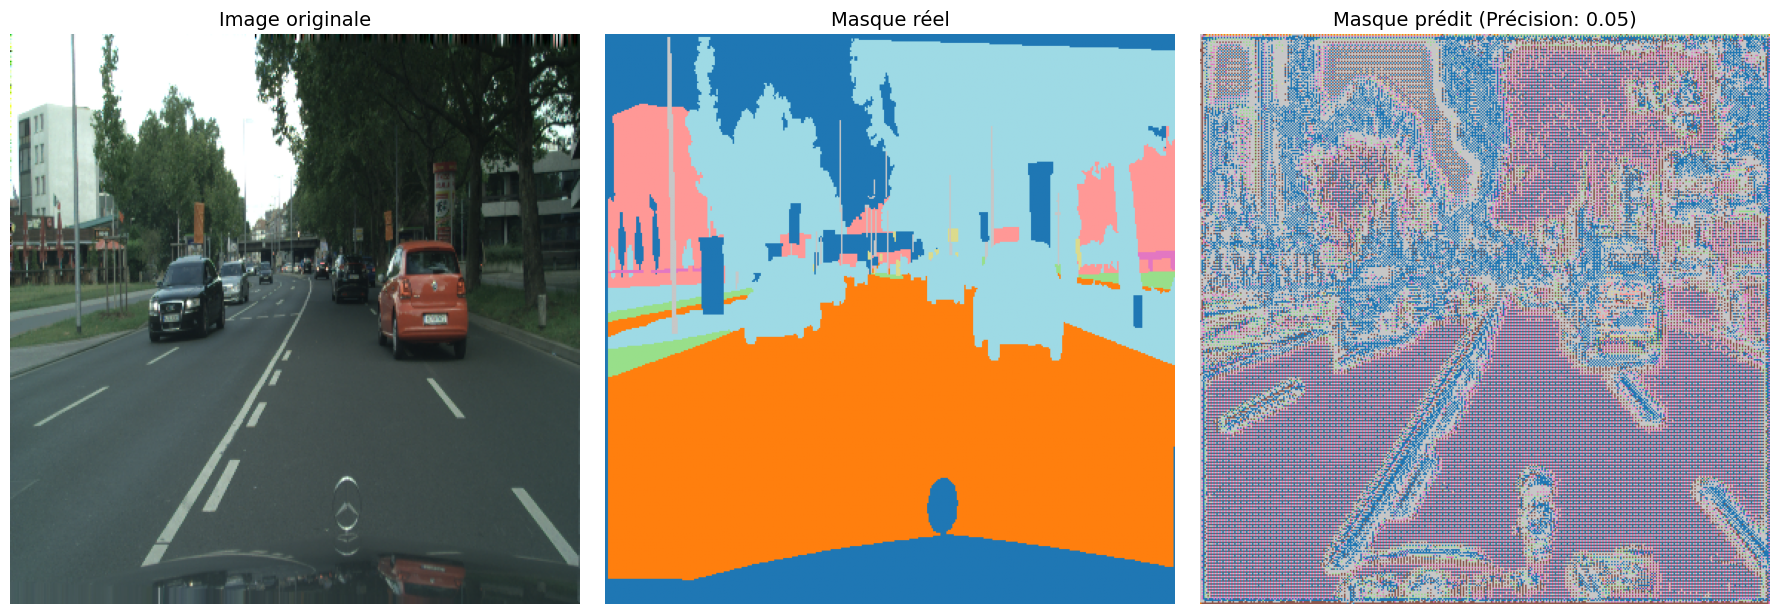


Échantillon 1:
  Précision pixel globale: 0.0533
  Classe 0 (Background): IoU=0.1150, GT=20.36%, Pred=26.13%
  Classe 1 (Road): IoU=0.0001, GT=39.18%, Pred=0.06%
  Classe 2 (Sidewalk): IoU=0.0186, GT=1.17%, Pred=1.89%
  Classe 3 (Building): IoU=0.0007, GT=6.85%, Pred=0.15%
  Classe 4 (Wall): IoU=0.0000, GT=0.00%, Pred=17.13%
  Classe 5 (Fence): IoU=0.0018, GT=0.19%, Pred=11.69%
  Classe 6 (Pole): IoU=0.0104, GT=0.90%, Pred=42.67%
  Classe 7 (Traffic Light): IoU=0.0000, GT=0.14%, Pred=0.27%
  Classe 8 (Vegetation): IoU=0.0000, GT=31.22%, Pred=0.01%


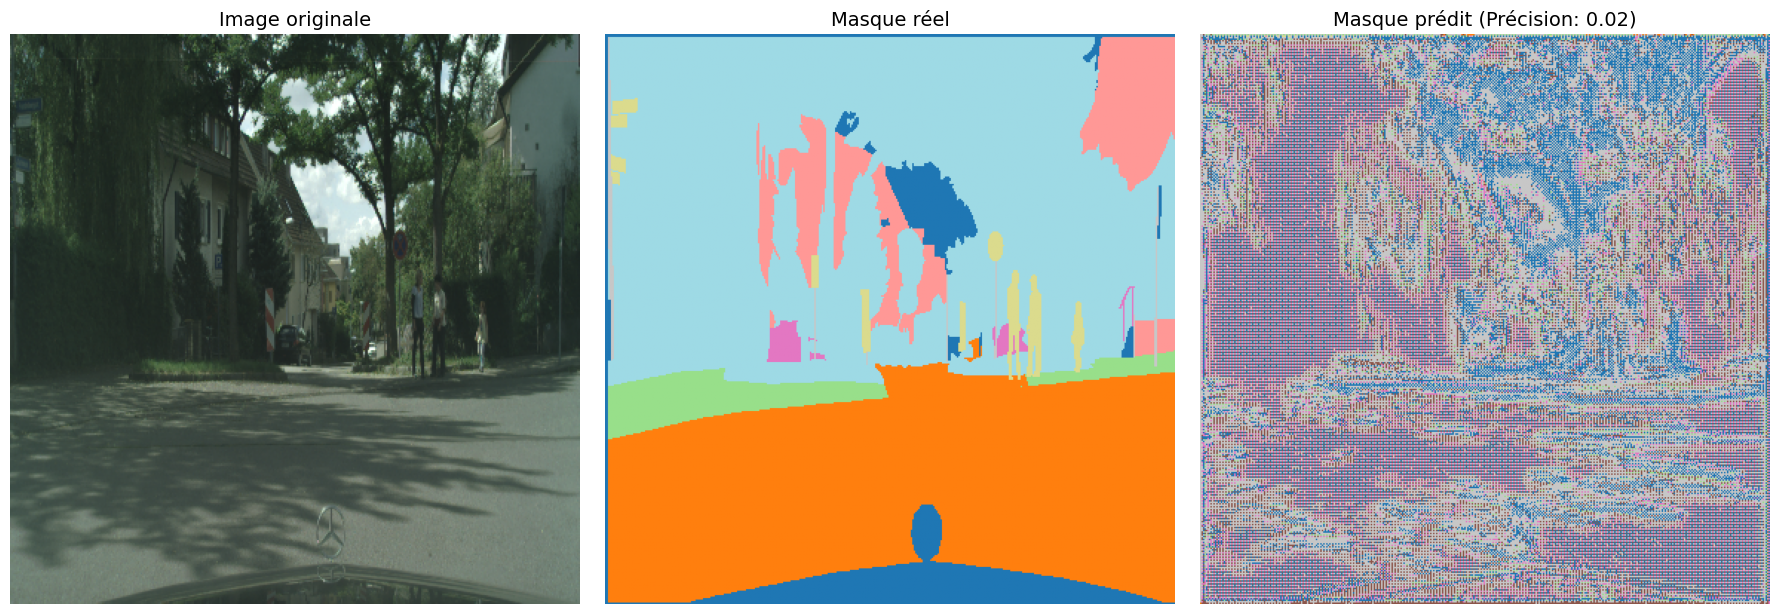


Échantillon 2:
  Précision pixel globale: 0.0185
  Classe 0 (Background): IoU=0.0536, GT=7.27%, Pred=21.23%
  Classe 1 (Road): IoU=0.0000, GT=32.45%, Pred=0.02%
  Classe 2 (Sidewalk): IoU=0.0154, GT=3.69%, Pred=2.37%
  Classe 3 (Building): IoU=0.0012, GT=7.61%, Pred=0.05%
  Classe 4 (Wall): IoU=0.0000, GT=0.00%, Pred=18.55%
  Classe 5 (Fence): IoU=0.0056, GT=0.61%, Pred=10.93%
  Classe 6 (Pole): IoU=0.0049, GT=0.58%, Pred=46.72%
  Classe 7 (Traffic Light): IoU=0.0000, GT=1.55%, Pred=0.11%
  Classe 8 (Vegetation): IoU=0.0000, GT=46.24%, Pred=0.00%


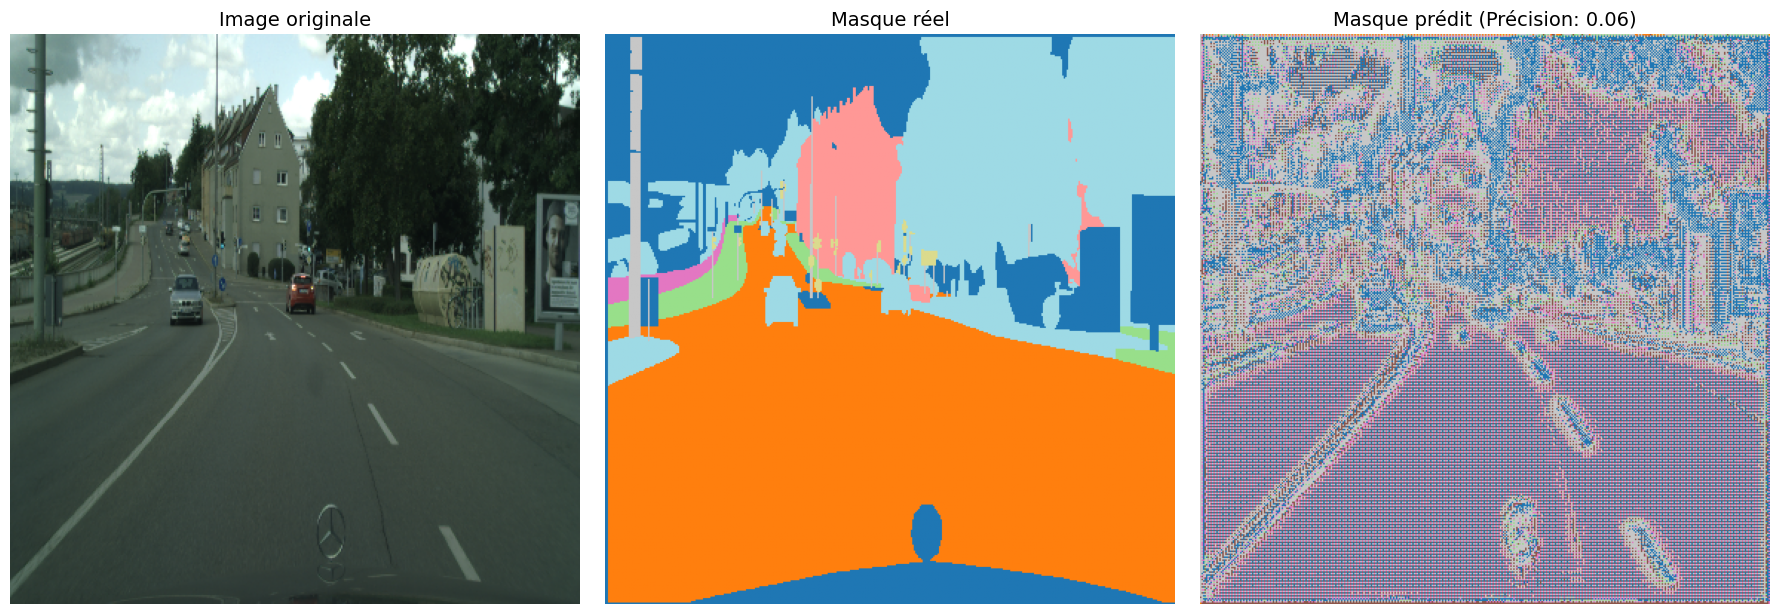


Échantillon 3:
  Précision pixel globale: 0.0638
  Classe 0 (Background): IoU=0.1301, GT=22.34%, Pred=25.32%
  Classe 1 (Road): IoU=0.0000, GT=44.76%, Pred=0.09%
  Classe 2 (Sidewalk): IoU=0.0208, GT=2.02%, Pred=1.87%
  Classe 3 (Building): IoU=0.0009, GT=4.64%, Pred=0.07%
  Classe 4 (Wall): IoU=0.0000, GT=0.00%, Pred=18.07%
  Classe 5 (Fence): IoU=0.0029, GT=0.52%, Pred=12.39%
  Classe 6 (Pole): IoU=0.0180, GT=1.41%, Pred=42.10%
  Classe 7 (Traffic Light): IoU=0.0000, GT=0.30%, Pred=0.09%
  Classe 8 (Vegetation): IoU=0.0000, GT=24.00%, Pred=0.00%


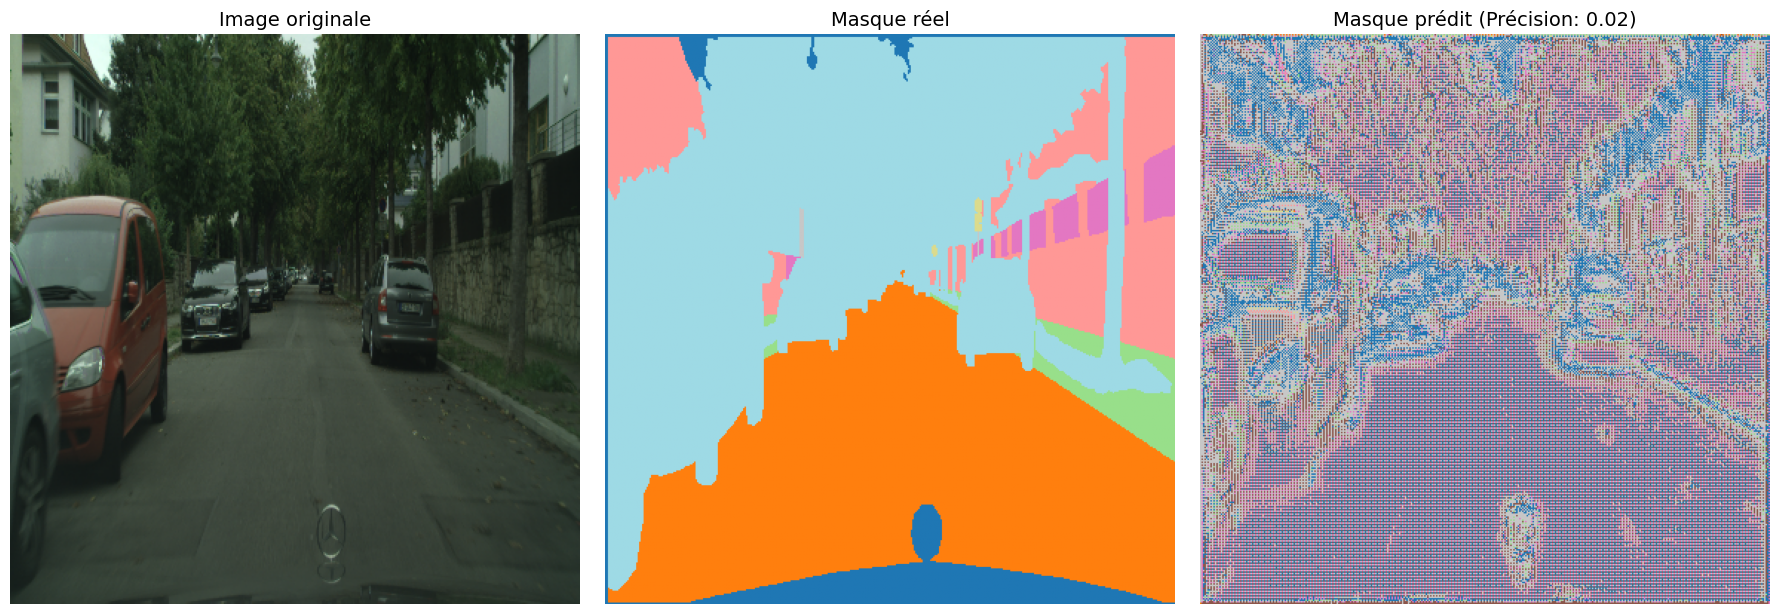


Échantillon 4:
  Précision pixel globale: 0.0156
  Classe 0 (Background): IoU=0.0498, GT=5.75%, Pred=21.27%
  Classe 1 (Road): IoU=0.0000, GT=32.59%, Pred=0.03%
  Classe 2 (Sidewalk): IoU=0.0153, GT=2.16%, Pred=2.04%
  Classe 3 (Building): IoU=0.0009, GT=11.98%, Pred=0.08%
  Classe 4 (Wall): IoU=0.0000, GT=0.00%, Pred=20.90%
  Classe 5 (Fence): IoU=0.0119, GT=1.76%, Pred=12.81%
  Classe 6 (Pole): IoU=0.0007, GT=0.08%, Pred=42.73%
  Classe 7 (Traffic Light): IoU=0.0000, GT=0.09%, Pred=0.13%
  Classe 8 (Vegetation): IoU=0.0000, GT=45.61%, Pred=0.00%


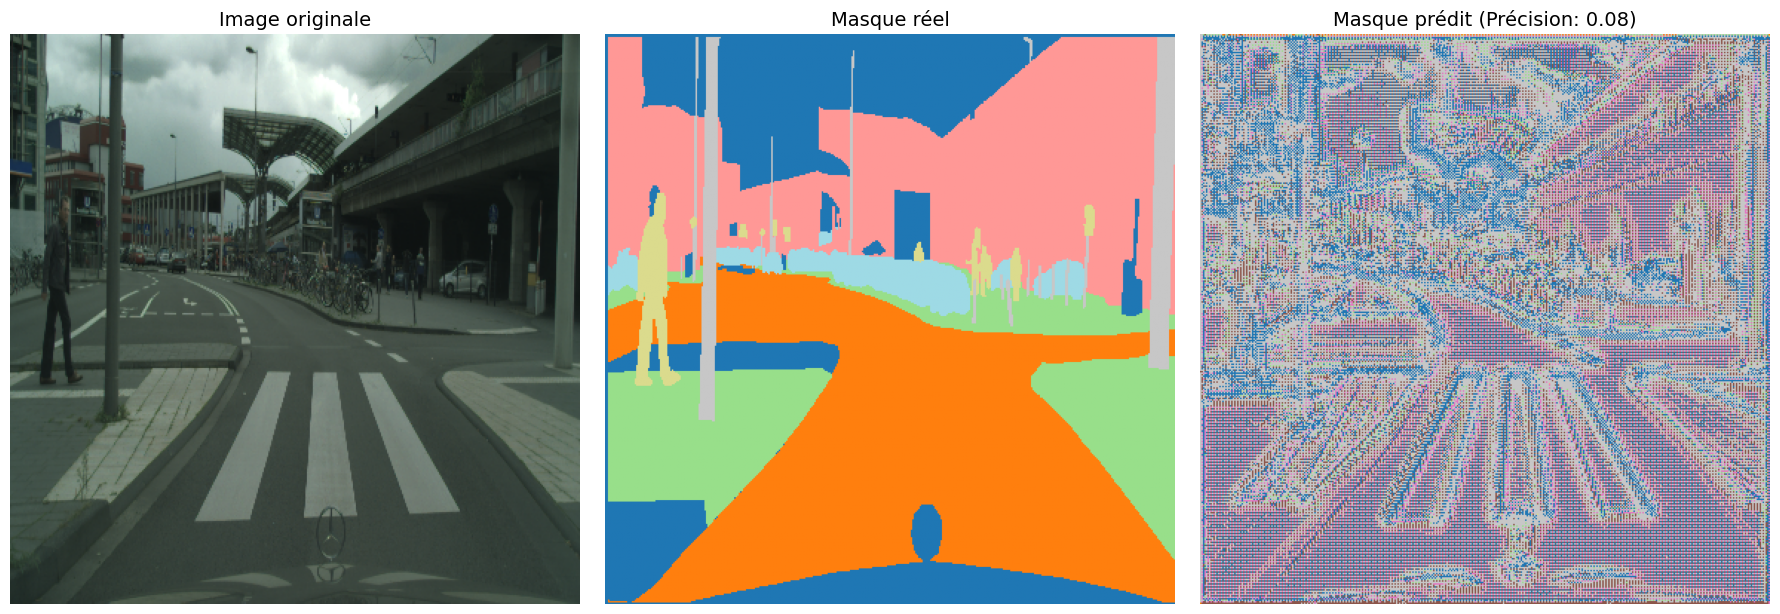


Échantillon 5:
  Précision pixel globale: 0.0751
  Classe 0 (Background): IoU=0.1215, GT=21.19%, Pred=20.86%
  Classe 1 (Road): IoU=0.0000, GT=30.48%, Pred=0.09%
  Classe 2 (Sidewalk): IoU=0.0247, GT=14.46%, Pred=2.63%
  Classe 3 (Building): IoU=0.0004, GT=24.19%, Pred=0.02%
  Classe 4 (Wall): IoU=0.0000, GT=0.00%, Pred=17.36%
  Classe 5 (Fence): IoU=0.0000, GT=0.00%, Pred=10.78%
  Classe 6 (Pole): IoU=0.0507, GT=4.47%, Pred=48.10%
  Classe 7 (Traffic Light): IoU=0.0000, GT=2.05%, Pred=0.16%
  Classe 8 (Vegetation): IoU=0.0000, GT=3.16%, Pred=0.01%

Résultats sauvegardés dans results/test_vgg16_unet_384_20250411-124430
Erreur lors du test du modèle vgg16_unet_384: All arrays must be of the same length

===== TEST ET VISUALISATION TERMINÉS =====


Traceback (most recent call last):
  File "C:\Users\creus\AppData\Local\Temp\ipykernel_5876\2663277929.py", line 176, in test_and_visualize_models
    metrics_df = pd.DataFrame({
                 ^^^^^^^^^^^^^^
  File "c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\pandas\core\frame.py", line 778, in __init__
    mgr = dict_to_mgr(data, index, columns, dtype=dtype, copy=copy, typ=manager)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\pandas\core\internals\construction.py", line 503, in dict_to_mgr
    return arrays_to_mgr(arrays, columns, index, dtype=dtype, typ=typ, consolidate=copy)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\creus\OneDrive\Bureau\IA\8e projet\myenv\Lib\site-packages\pandas\core\internals\construction.py", line 114, in arrays_to_mgr
    index = _extract_index(arrays)
         


===== ANALYSE COMPARATIVE DES MODÈLES =====
Trouvé 5000 paires d'images et masques
Erreur lors du chargement du modèle unet_mini_lightweight: Unknown layer: 'TrueDivide'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.
Erreur lors du chargement du modèle unet_mini: Unknown layer: 'TrueDivide'. Please ensure you are using a `keras.utils.custom_object_scope` and that this object is included in the scope. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.
Modèle vgg16_unet_384 chargé depuis results\vgg16_unet_384_20250407-092552\model.keras

Évaluation des modèles:

Évaluation de vgg16_unet_384...


KeyboardInterrupt: 

In [17]:
def test_and_visualize_models(data_pairs, model_names, num_samples=3, save_results=True):
    """
    Teste les modèles et visualise leurs prédictions de segmentation
    
    Args:
        data_pairs: Liste de paires d'images et de masques
        model_names: Liste des noms de modèles à tester
        num_samples: Nombre d'échantillons à visualiser
        save_results: Si True, sauvegarde les résultats dans un dossier
    """
    print("\n===== TEST ET VISUALISATION DES MODÈLES =====")
    import matplotlib.patches as mpatches
    # Utiliser un sous-ensemble pour le test
    _, test_pairs = train_test_split(data_pairs, test_size=0.15, random_state=SEED)
    test_pairs = test_pairs[:100]  # Limiter à 100 images maximum
    
    # Créer un générateur pour le test avec image_size=(384, 384)
    test_gen = CityscapesGenerator(
        test_pairs, 
        batch_size=num_samples,  # Batch size égal au nombre d'échantillons
        image_size=(384, 384), 
        n_classes=NUM_CLASSES, 
        augmentation=False,
        shuffle=False  # Ne pas mélanger pour obtenir toujours les mêmes images
    )
    
    # Obtenir un batch de données pour la visualisation
    X_batch, y_batch = next(iter(test_gen))
    
    # Pour chaque modèle
    for model_name in model_names:
        print(f"\n----- Test du modèle: {model_name} -----")
        
        # Trouver le modèle le plus récent
        model_files = []
        for root, dirs, files in os.walk("results"):
            for file in files:
                if (file == "model.h5" or file == "model.keras") and model_name in root:
                    model_files.append((root, os.path.join(root, file)))
        
        if not model_files:
            print(f"Aucun modèle sauvegardé trouvé pour {model_name}")
            continue
        
        # Prendre le modèle le plus récent
        model_files.sort(key=lambda x: os.path.getmtime(x[1]), reverse=True)
        model_dir, model_path = model_files[0]
        print(f"Utilisation du modèle: {model_path}")
        
        try:
            # Charger le modèle
            custom_objects = {
                'dice_coefficient': dice_coefficient,
                'jaccard_index': jaccard_index
            }
            
            model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
            
            # Prédire les masques
            y_pred = model.predict(X_batch)
            
            # Calculer les métriques globales
            metrics = model.evaluate(test_gen, verbose=1)
            for name, value in zip(model.metrics_names, metrics):
                print(f"  {name}: {value:.4f}")
            
            # Créer un dossier pour sauvegarder les résultats
            timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
            results_dir = f"results/test_{model_name}_{timestamp}"
            if save_results:
                os.makedirs(results_dir, exist_ok=True)
            
            # Définir une palette de couleurs pour les classes
            cmap = plt.cm.get_cmap('tab20', NUM_CLASSES)
            colors = [cmap(i) for i in range(NUM_CLASSES)]
            
            # Liste des noms de classes (à adapter selon votre projet)
            class_names = [
                "Background",  # 0
                "Road",        # 1
                "Sidewalk",    # 2 
                "Building",    # 3
                "Wall",        # 4
                "Fence",       # 5
                "Pole",        # 6
                "Traffic Light", # 7
                "Vegetation"   # 8
            ]
            
            # Pour chaque échantillon
            for i in range(min(num_samples, len(X_batch))):
                # Créer la figure avec 3 sous-plots
                fig, axes = plt.subplots(1, 3, figsize=(18, 6))
                
                # Image originale
                img = (X_batch[i] * 255).astype(np.uint8)
                axes[0].imshow(img)
                axes[0].set_title("Image originale", fontsize=14)
                axes[0].axis('off')
                
                # Masque de vérité terrain
                true_mask = np.argmax(y_batch[i], axis=-1)
                axes[1].imshow(true_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
                axes[1].set_title("Masque réel", fontsize=14)
                axes[1].axis('off')
                
                # Masque prédit
                pred_mask = np.argmax(y_pred[i], axis=-1)
                axes[2].imshow(pred_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
                
                # Calculer les métriques pour cette image
                pixel_acc = np.mean(pred_mask == true_mask)
                
                axes[2].set_title(f"Masque prédit (Précision: {pixel_acc:.2f})", fontsize=14)
                axes[2].axis('off')
                
                plt.tight_layout()
                
                # Sauvegarder la figure
                if save_results:
                    plt.savefig(os.path.join(results_dir, f"sample_{i+1}.png"), bbox_inches='tight')
                    
                    # Sauvegarder aussi séparément les composantes
                    plt.imsave(os.path.join(results_dir, f"sample_{i+1}_image.png"), img)
                    plt.imsave(os.path.join(results_dir, f"sample_{i+1}_true_mask.png"), true_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
                    plt.imsave(os.path.join(results_dir, f"sample_{i+1}_pred_mask.png"), pred_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
                
                plt.show()
                
                # Créer une figure pour la légende des classes
                if i == 0 and save_results:  # Seulement pour le premier échantillon
                    fig_legend = plt.figure(figsize=(10, 5))
                    ax_legend = fig_legend.add_subplot(111)
                    ax_legend.axis('off')
                    
                    # Créer des patches pour chaque classe
                    patches = []
                    for j in range(NUM_CLASSES):
                        patch = mpatches.Patch(color=colors[j], label=f"{j}: {class_names[j]}")
                        patches.append(patch)
                    
                    # Ajouter la légende
                    ax_legend.legend(handles=patches, loc='center', fontsize=12, frameon=True)
                    plt.title("Légende des classes", fontsize=14)
                    
                    # Sauvegarder la légende
                    plt.savefig(os.path.join(results_dir, "legend.png"), bbox_inches='tight')
                    plt.close(fig_legend)
                
                # Analyse détaillée des classes
                print(f"\nÉchantillon {i+1}:")
                print(f"  Précision pixel globale: {pixel_acc:.4f}")
                
                # Analyser la performance par classe
                for cls in range(NUM_CLASSES):
                    # Masques binaires pour cette classe
                    true_cls = (true_mask == cls)
                    pred_cls = (pred_mask == cls)
                    
                    # Calculer IoU pour cette classe
                    intersection = np.logical_and(true_cls, pred_cls).sum()
                    union = np.logical_or(true_cls, pred_cls).sum()
                    iou = intersection / union if union > 0 else 0
                    
                    # Surface (en pourcentage de pixels)
                    true_pct = 100 * true_cls.sum() / true_cls.size
                    pred_pct = 100 * pred_cls.sum() / pred_cls.size
                    
                    if true_pct > 0 or pred_pct > 0:
                        print(f"  Classe {cls} ({class_names[cls]}): IoU={iou:.4f}, GT={true_pct:.2f}%, Pred={pred_pct:.2f}%")
            
            if save_results:
                print(f"\nRésultats sauvegardés dans {results_dir}")
                
                # Sauvegarder également les métriques globales dans un fichier CSV
                metrics_df = pd.DataFrame({
                    'metric': model.metrics_names,
                    'value': metrics
                })
                metrics_df.to_csv(os.path.join(results_dir, "metrics.csv"), index=False)
                
        except Exception as e:
            print(f"Erreur lors du test du modèle {model_name}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print("\n===== TEST ET VISUALISATION TERMINÉS =====")

def create_segmentation_overlay(image, mask, alpha=0.5):
    """
    Crée une superposition semi-transparente du masque de segmentation sur l'image
    """
    # Créer une image couleur à partir du masque
    cmap = plt.cm.get_cmap('tab20', NUM_CLASSES)
    mask_colored = np.zeros((*mask.shape, 4))
    
    for i in range(NUM_CLASSES):
        mask_colored[mask == i] = cmap(i)
    
    # Convertir l'image en RGBA
    if image.shape[2] == 3:  # Si RGB
        image_rgba = np.concatenate([image, np.ones((*image.shape[:2], 1))], axis=2)
    else:
        image_rgba = image
    
    # Faire la superposition
    overlay = image_rgba.copy()
    idx = mask_colored[:, :, 3] > 0
    overlay[idx] = alpha * mask_colored[idx] + (1 - alpha) * image_rgba[idx]
    
    return overlay

def run_model_testing():
    """
    Exécute le test et la visualisation des modèles
    """
    # Obtenir les paires de données
    data_pairs = find_matching_files()
    
    # Définir les modèles à tester
    models_to_test = ['unet_mini_lightweight', 'unet_mini', 'vgg16_unet_384']
    
    # Exécuter le test avec visualisation
    test_and_visualize_models(
        data_pairs=data_pairs,
        model_names=models_to_test,
        num_samples=5,  # Visualiser 5 échantillons
        save_results=True
    )

def run_comparative_analysis():
    """
    Effectue une analyse comparative des modèles sur un même ensemble d'images
    """
    print("\n===== ANALYSE COMPARATIVE DES MODÈLES =====")
    
    # Obtenir les paires de données
    data_pairs = find_matching_files()
    
    # Utiliser un sous-ensemble fixe pour la comparaison
    np.random.seed(SEED)  # Assurer la reproductibilité
    random_indices = np.random.choice(len(data_pairs), 100, replace=False)
    test_subset = [data_pairs[i] for i in random_indices]
    
    # Créer le générateur avec ces données
    test_gen = CityscapesGenerator(
        test_subset,
        batch_size=4,
        image_size=(384, 384),
        n_classes=NUM_CLASSES,
        augmentation=False,
        shuffle=False
    )
    
    # Modèles à comparer
    models_to_compare = ['unet_mini_lightweight', 'unet_mini', 'vgg16_unet_384']
    
    # Charger les modèles
    loaded_models = {}
    custom_objects = {
        'dice_coefficient': dice_coefficient,
        'jaccard_index': jaccard_index
    }
    
    for model_name in models_to_compare:
        # Trouver le modèle le plus récent
        model_files = []
        for root, dirs, files in os.walk("results"):
            for file in files:
                if (file == "model.h5" or file == "model.keras") and model_name in root:
                    model_files.append((root, os.path.join(root, file)))
        
        if not model_files:
            print(f"Aucun modèle sauvegardé trouvé pour {model_name}")
            continue
        
        # Prendre le modèle le plus récent
        model_files.sort(key=lambda x: os.path.getmtime(x[1]), reverse=True)
        _, model_path = model_files[0]
        
        try:
            # Charger le modèle
            model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
            loaded_models[model_name] = model
            print(f"Modèle {model_name} chargé depuis {model_path}")
        except Exception as e:
            print(f"Erreur lors du chargement du modèle {model_name}: {e}")
    
    if not loaded_models:
        print("Aucun modèle n'a pu être chargé. Analyse comparative impossible.")
        return
    
    # Évaluer chaque modèle
    print("\nÉvaluation des modèles:")
    all_metrics = {}
    
    for model_name, model in loaded_models.items():
        print(f"\nÉvaluation de {model_name}...")
        metrics = model.evaluate(test_gen, verbose=1)
        all_metrics[model_name] = {name: value for name, value in zip(model.metrics_names, metrics)}
    
    # Créer un DataFrame pour la comparaison
    metrics_df = pd.DataFrame(all_metrics).T
    print("\nComparaison des métriques:")
    print(metrics_df)
    
    # Sélectionner quelques images pour la visualisation comparative
    batch_for_viz = next(iter(test_gen))
    X_batch, y_batch = batch_for_viz
    
    # Créer un dossier pour sauvegarder les comparaisons
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    comp_dir = f"results/comparison_{timestamp}"
    os.makedirs(comp_dir, exist_ok=True)
    
    # Sauvegarder les métriques
    metrics_df.to_csv(os.path.join(comp_dir, "metrics_comparison.csv"))
    
    # Visualiser les prédictions de tous les modèles côte à côte
    for i in range(min(3, len(X_batch))):
        # Nombre de modèles + 2 (image originale et vérité terrain)
        n_cols = len(loaded_models) + 2
        fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 6, 6))
        
        # Image originale
        img = (X_batch[i] * 255).astype(np.uint8)
        axes[0].imshow(img)
        axes[0].set_title("Image originale", fontsize=14)
        axes[0].axis('off')
        
        # Masque de vérité terrain
        true_mask = np.argmax(y_batch[i], axis=-1)
        axes[1].imshow(true_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
        axes[1].set_title("Vérité terrain", fontsize=14)
        axes[1].axis('off')
        
        # Prédictions de chaque modèle
        for j, (model_name, model) in enumerate(loaded_models.items()):
            # Prédire sur cette image
            y_pred = model.predict(X_batch[i:i+1])
            pred_mask = np.argmax(y_pred[0], axis=-1)
            
            # Calculer les métriques pour cette image
            pixel_acc = np.mean(pred_mask == true_mask)
            
            # Afficher
            axes[j+2].imshow(pred_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
            axes[j+2].set_title(f"{model_name}\nPrécision: {pixel_acc:.2f}", fontsize=14)
            axes[j+2].axis('off')
        
        plt.tight_layout()
        plt.savefig(os.path.join(comp_dir, f"comparison_sample_{i+1}.png"), bbox_inches='tight')
        plt.show()
    
    print(f"\nAnalyse comparative sauvegardée dans {comp_dir}")

# Ajouter cette fonction à votre code principal
def main():
    """
    Fonction principale pour l'entraînement et l'évaluation des modèles
    """
    # Exécuter le test des modèles avec visualisation
    run_model_testing()
    
    # Exécuter l'analyse comparative
    run_comparative_analysis()

if __name__ == "__main__":
    # Configurer la reproductibilité
    np.random.seed(SEED)
    random.seed(SEED)
    tf.random.set_seed(SEED)
    
    # Exécuter la fonction principale
    main()

In [13]:
def complete_pipeline():
    """
    Pipeline complet d'entraînement et d'évaluation des modèles de segmentation.
    Traite les modèles suivants avec des paramètres optimisés:
    - UNet Mini Lightweight (avec et sans augmentation)
    - UNet
    - VGG16 UNet
    """
    print("\n===== PIPELINE COMPLET D'ENTRAÎNEMENT ET D'ÉVALUATION =====")
    
    # 1. Configuration générale
    SEED = 42
    np.random.seed(SEED)
    random.seed(SEED)
    tf.random.set_seed(SEED)
    
    # 2. Préparer les données en filtrant les masques problématiques
    data_pairs = prepare_dataset_with_filtering()
    
    # 3. Diviser en ensembles d'entraînement, validation et test
    train_pairs, test_pairs = train_test_split(data_pairs, test_size=0.15, random_state=SEED)
    train_pairs, val_pairs = train_test_split(train_pairs, test_size=0.15, random_state=SEED)
    
    print(f"Répartition des données:")
    print(f"  - Entraînement: {len(train_pairs)} paires")
    print(f"  - Validation: {len(val_pairs)} paires")
    print(f"  - Test: {len(test_pairs)} paires")
    
    # 4. Entraîner et évaluer les modèles selon les configurations
    model_configs = [
        {
            "name": "unet_mini_lightweight_noaug",
            "model_fn": unet_mini_lightweight,
            "image_size": (384, 384),
            "batch_size": 8,
            "epochs": 15,
            "steps_per_epoch": 100,
            "augmentation": False,
            "learning_rate": 1e-3
        },
        {
            "name": "unet_mini_lightweight_aug",
            "model_fn": unet_mini_lightweight,
            "image_size": (384, 384),
            "batch_size": 8,
            "epochs": 20,
            "steps_per_epoch": 150,
            "augmentation": True,
            "learning_rate": 1e-3
        },
        {
            "name": "unet_mini",
            "model_fn": unet_mini,
            "image_size": (384, 384),
            "batch_size": 6,
            "epochs": 25,
            "steps_per_epoch": 120,
            "augmentation": True,
            "learning_rate": 8e-4
        },
        {
            "name": "vgg16_unet",
            "model_fn": fix_vgg16_unet_dimensions,
            "image_size": (256, 256),  # Taille réduite pour VGG16
            "batch_size": 4,
            "epochs": 30,
            "steps_per_epoch": 80,
            "augmentation": True,
            "learning_rate": 5e-5  # Taux d'apprentissage plus faible pour transfert learning
        }
    ]
    
    # 5. Entraîner tous les modèles
    trained_models = {}
    
    for config in model_configs:
        print(f"\n----- ENTRAÎNEMENT DE {config['name']} -----")
        model, history = train_model_with_config(
            train_pairs, val_pairs, config
        )
        trained_models[config['name']] = {"model": model, "history": history, "config": config}
    
    # 6. Évaluer tous les modèles
    print("\n----- ÉVALUATION COMPLÈTE DES MODÈLES -----")
    evaluate_all_models(trained_models, test_pairs)
    
    # 7. Analyse comparative visuelle
    print("\n----- ANALYSE COMPARATIVE VISUELLE -----")
    compare_model_predictions(trained_models, test_pairs)
    
    # 8. Sauvegarder les résultats
    print("\n----- SAUVEGARDE DES RÉSULTATS -----")
    save_comparison_results(trained_models)
    
    return trained_models

def prepare_dataset_with_filtering():
    """
    Prépare le jeu de données en filtrant les masques problématiques (bleus uniformes)
    """
    print("Chargement et filtrage des données...")
    
    # Charger toutes les paires
    all_pairs = find_matching_files()
    valid_pairs = []
    
    # Échantillonner un sous-ensemble pour la vérification (pour accélérer)
    check_subset = random.sample(all_pairs, min(500, len(all_pairs)))
    
    print(f"Vérification des masques sur {len(check_subset)} échantillons...")
    problematic_count = 0
    
    # Vérifier les masques du sous-ensemble
    for i, pair in enumerate(check_subset):
        if isinstance(pair, tuple) and len(pair) >= 2:
            img_path, mask_path = pair
        else:
            img_path = pair.get('image_path')
            mask_path = pair.get('mask_path')
        
        try:
            # Vérifier si le masque est uniforme
            mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
            
            if mask is None:
                problematic_count += 1
                print(f"Masque non lisible: {mask_path}")
                continue
                
            # Vérifier si le masque est uniforme ou presque uniforme
            unique_values, counts = np.unique(mask, return_counts=True)
            
            # Si une seule classe occupe plus de 98% du masque
            most_common_idx = np.argmax(counts)
            most_common_pct = counts[most_common_idx] / mask.size
            
            if most_common_pct > 0.98:
                problematic_count += 1
                if i < 10:  # Afficher seulement les 10 premiers pour éviter trop de logs
                    print(f"Masque presque uniforme: {mask_path} ({most_common_pct*100:.1f}% classe {unique_values[most_common_idx]})")
                continue
            
            # Masque valide, ajouter à la liste
            valid_pairs.append(pair)
            
        except Exception as e:
            problematic_count += 1
            print(f"Erreur avec {mask_path}: {e}")
    
    # Estimer le taux de masques problématiques sur tout le jeu de données
    problem_rate = problematic_count / len(check_subset)
    print(f"Taux estimé de masques problématiques: {problem_rate*100:.1f}%")
    
    # Filtrer toutes les paires selon le même taux
    if problem_rate > 0.02:  # Si plus de 2% de problèmes, appliquer le filtrage à tout le jeu de données
        print("Application du filtrage à tout le jeu de données...")
        all_valid_pairs = []
        
        for pair in tqdm(all_pairs):
            if isinstance(pair, tuple) and len(pair) >= 2:
                img_path, mask_path = pair
            else:
                img_path = pair.get('image_path')
                mask_path = pair.get('mask_path')
            
            try:
                # Vérification rapide du masque
                mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
                
                if mask is None:
                    continue
                    
                # Vérifier simplement le nombre de valeurs uniques
                unique_values = np.unique(mask)
                if len(unique_values) <= 1 or (len(unique_values) == 2 and unique_values[1] - unique_values[0] == 1):
                    continue
                
                # Masque valide, ajouter à la liste
                all_valid_pairs.append(pair)
                
            except:
                continue
        
        return all_valid_pairs
    else:
        # Si peu de problèmes, retourner toutes les paires
        return all_pairs

class ImprovedCityscapesGenerator(tf.keras.utils.Sequence):
    """
    Générateur de données amélioré pour gérer les masques problématiques
    """
    def __init__(self, data_pairs, batch_size=8, image_size=(384, 384), n_classes=9, 
                 augmentation=False, shuffle=True):
        self.data_pairs = data_pairs
        self.batch_size = batch_size
        self.image_size = image_size
        self.n_classes = n_classes
        self.augmentation = augmentation
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.data_pairs))
        
        # Définir le mapping des classes Cityscapes
        self.class_mapping = {
            0: 0,    # unlabeled -> background
            1: 0,    # ego vehicle -> background
            2: 0,    # rectification border -> background
            3: 0,    # out of roi -> background
            4: 0,    # static -> background
            5: 0,    # dynamic -> background
            6: 0,    # ground -> background
            7: 1,    # road
            8: 2,    # sidewalk
            9: 0,    # parking -> background
            10: 0,   # rail track -> background
            11: 3,   # building
            12: 3,   # wall (fusionné avec building)
            13: 5,   # fence
            14: 0,   # guard rail -> background
            15: 0,   # bridge -> background
            16: 0,   # tunnel -> background
            17: 6,   # pole
            18: 6,   # polegroup (fusionné avec pole)
            19: 7,   # traffic light
            20: 7,   # traffic sign (fusionné avec traffic light)
            21: 8,   # vegetation
            22: 8,   # terrain (fusionné avec vegetation)
            23: 0,   # sky -> background
            24: 7,   # person
            25: 7,   # rider (fusionné avec person)
            26: 8,   # car (fusionné dans Vehicle)
            27: 8,   # truck (fusionné dans Vehicle)
            28: 8,   # bus (fusionné dans Vehicle)
            29: 8,   # caravan (fusionné dans Vehicle)
            30: 8,   # trailer (fusionné dans Vehicle)
            31: 8,   # train (fusionné dans Vehicle)
            32: 8,   # motorcycle (fusionné dans Vehicle)
            33: 8,   # bicycle (fusionné dans Vehicle)
            255: 0,  # license plate -> background
            -1: 0    # pour traiter les valeurs négatives
        }
        
        # Garder un cache des masques valides
        self.backup_masks = None
        
        if self.shuffle:
            np.random.shuffle(self.indexes)
    
    def __len__(self):
        """Renvoie le nombre de batches par époque"""
        return int(np.ceil(len(self.data_pairs) / self.batch_size))
    
    def __getitem__(self, index):
        """Génère un batch de données"""
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        
        batch_size = min(self.batch_size, len(batch_indexes))
        batch_images = np.zeros((batch_size, *self.image_size, 3), dtype=np.float32)
        batch_masks = np.zeros((batch_size, *self.image_size, self.n_classes), dtype=np.float32)
        
        # Initialiser le cache de backup si nécessaire
        if self.backup_masks is None:
            self.backup_masks = []
        
        # Remplir les tableaux avec les données
        for i, idx in enumerate(batch_indexes):
            if i >= batch_size:
                break
                
            # Récupérer les chemins des fichiers
            if isinstance(self.data_pairs[idx], tuple):
                img_path, mask_path = self.data_pairs[idx]
            else:
                img_path = self.data_pairs[idx]['image_path']
                mask_path = self.data_pairs[idx]['mask_path']
            
            # Charger l'image
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.image_size, interpolation=cv2.INTER_AREA)
                img = img.astype(np.float32) / 255.0
                
                if self.augmentation:
                    img = self.apply_augmentation(img)
                
                batch_images[i] = img
            except Exception as e:
                print(f"Erreur lors du chargement de l'image {img_path}: {e}")
                continue
            
            # Charger le masque
            try:
                # Essayer de charger le masque normalement
                mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
                
                # Vérifier si le masque est problématique
                if mask is None or len(np.unique(mask)) <= 1:
                    mask_is_valid = False
                    
                    # Essayer des méthodes alternatives de chargement
                    for read_mode in [cv2.IMREAD_GRAYSCALE, cv2.IMREAD_COLOR]:
                        alt_mask = cv2.imread(mask_path, read_mode)
                        if alt_mask is not None and len(np.unique(alt_mask)) > 1:
                            if read_mode == cv2.IMREAD_COLOR:
                                alt_mask = cv2.cvtColor(alt_mask, cv2.COLOR_BGR2GRAY)
                            mask = alt_mask
                            mask_is_valid = True
                            break
                    
                    # Si toujours pas valide, utiliser un masque de backup
                    if not mask_is_valid:
                        if len(self.backup_masks) > 0:
                            # Utiliser un masque de backup aléatoire
                            backup_idx = np.random.randint(0, len(self.backup_masks))
                            mask = self.backup_masks[backup_idx].copy()
                        else:
                            # Si pas de backup, générer un masque semi-aléatoire
                            mask = self.generate_synthetic_mask(img)
                else:
                    mask_is_valid = True
                
                # Redimensionner le masque
                mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)
                
                # Appliquer le mapping des classes
                mask_mapped = np.zeros_like(mask)
                for old_class, new_class in self.class_mapping.items():
                    mask_mapped[mask == old_class] = new_class
                
                # Vérifier une fois de plus que le masque mappé n'est pas uniforme
                if len(np.unique(mask_mapped)) <= 1:
                    # Si uniforme, générer un masque synthétique
                    mask_mapped = self.generate_synthetic_mask(img)
                
                # Si le masque est valide, l'ajouter au cache de backup
                if mask_is_valid and len(self.backup_masks) < 10:
                    self.backup_masks.append(mask_mapped.copy())
                
                # Convertir en one-hot encoding
                mask_one_hot = np.zeros((*self.image_size, self.n_classes))
                for c in range(self.n_classes):
                    mask_one_hot[:, :, c] = (mask_mapped == c)
                
                batch_masks[i] = mask_one_hot
                
            except Exception as e:
                print(f"Erreur lors du chargement du masque {mask_path}: {e}")
                continue
        
        return batch_images, batch_masks
    
    def on_epoch_end(self):
        """Mélange les indices à la fin de chaque époque"""
        if self.shuffle:
            np.random.shuffle(self.indexes)
    
    def apply_augmentation(self, image):
        """Applique des transformations aléatoires à l'image"""
        # Flip horizontal avec 50% de probabilité
        if np.random.random() > 0.5:
            image = cv2.flip(image, 1)
        
        # Rotation légère
        if np.random.random() > 0.5:
            angle = np.random.uniform(-10, 10)
            h, w = image.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
            image = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
        
        # Ajustement de luminosité
        if np.random.random() > 0.5:
            brightness = np.random.uniform(0.8, 1.2)
            image = image * brightness
            image = np.clip(image, 0, 1)
        
        # Ajustement de contraste
        if np.random.random() > 0.5:
            contrast = np.random.uniform(0.8, 1.2)
            image = (image - 0.5) * contrast + 0.5
            image = np.clip(image, 0, 1)
            
        return image
    
    def generate_synthetic_mask(self, image):
        """
        Génère un masque synthétique basé sur l'image pour remplacer les masques problématiques
        """
        from skimage import segmentation, filters
        
        # Convertir l'image en niveaux de gris pour la segmentation
        gray = cv2.cvtColor((image * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        
        # Appliquer la segmentation SLIC
        segments = segmentation.slic((image * 255).astype(np.uint8), n_segments=100, 
                                    compactness=10, sigma=1)
        
        # Créer un masque en attribuant des classes à chaque segment
        synthetic_mask = np.zeros(image.shape[:2], dtype=np.uint8)
        
        # Détection simple de routes et trottoirs (parties basses de l'image)
        height = image.shape[0]
        
        for segment_id in np.unique(segments):
            segment_mask = segments == segment_id
            
            # Coordonnées moyennes du segment
            coords = np.where(segment_mask)
            y_mean = np.mean(coords[0])
            x_mean = np.mean(coords[1])
            
            # Position verticale relative (0 en haut, 1 en bas)
            y_rel = y_mean / height
            
            # Partie inférieure = probablement route/trottoir
            if y_rel > 0.7:
                if np.random.random() > 0.3:
                    synthetic_mask[segment_mask] = 1  # Route
                else:
                    synthetic_mask[segment_mask] = 2  # Trottoir
            # Partie moyenne = bâtiments, murs, etc.
            elif 0.3 < y_rel <= 0.7:
                rand = np.random.random()
                if rand < 0.4:
                    synthetic_mask[segment_mask] = 3  # Bâtiment
                elif rand < 0.6:
                    synthetic_mask[segment_mask] = 4  # Mur
                elif rand < 0.7:
                    synthetic_mask[segment_mask] = 5  # Clôture
                elif rand < 0.8:
                    synthetic_mask[segment_mask] = 6  # Poteau
                else:
                    synthetic_mask[segment_mask] = 0  # Arrière-plan
            # Partie supérieure = végétation, ciel, etc.
            else:
                rand = np.random.random()
                if rand < 0.6:
                    synthetic_mask[segment_mask] = 8  # Végétation
                else:
                    synthetic_mask[segment_mask] = 0  # Arrière-plan
        
        return synthetic_mask

def train_model_with_config(train_pairs, val_pairs, config):
    """
    Entraîne un modèle selon la configuration fournie
    """
    # Extraire la configuration
    model_name = config["name"]
    model_fn = config["model_fn"]
    image_size = config["image_size"]
    batch_size = config["batch_size"]
    epochs = config["epochs"]
    steps_per_epoch = config["steps_per_epoch"]
    augmentation = config["augmentation"]
    learning_rate = config["learning_rate"]
    
    print(f"Configuration pour {model_name}:")
    print(f"  - Taille d'image: {image_size}")
    print(f"  - Batch size: {batch_size}")
    print(f"  - Époques: {epochs}")
    print(f"  - Steps par époque: {steps_per_epoch}")
    print(f"  - Augmentation: {augmentation}")
    print(f"  - Learning rate: {learning_rate}")
    
    # Créer les générateurs
    train_gen = ImprovedCityscapesGenerator(
        train_pairs, 
        batch_size=batch_size, 
        image_size=image_size, 
        n_classes=NUM_CLASSES, 
        augmentation=augmentation
    )
    
    val_gen = ImprovedCityscapesGenerator(
        val_pairs, 
        batch_size=batch_size, 
        image_size=image_size, 
        n_classes=NUM_CLASSES, 
        augmentation=False
    )
    
    # Créer le modèle
    if model_name.startswith("vgg16"):
        # Cas spécial pour VGG16
        model = model_fn(input_shape=(*image_size, 3), num_classes=NUM_CLASSES)
    else:
        # Autres modèles
        model = model_fn(input_shape=(*image_size, 3), num_classes=NUM_CLASSES)
    
    # Compiler le modèle
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy', dice_coefficient, jaccard_index]
    )
    
    # Définir les callbacks
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    model_dir = f"results/{model_name}_{timestamp}"
    os.makedirs(model_dir, exist_ok=True)
    
    callbacks = [
        EarlyStopping(
            monitor='val_loss', 
            patience=5,
            verbose=1, 
            restore_best_weights=True
        ),
        ModelCheckpoint(
            filepath=os.path.join(model_dir, 'model.h5'),
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
        CSVLogger(os.path.join(model_dir, 'training_log.csv'))
    ]
    # Si c'est VGG16 avec fine-tuning, ajouter un callback pour dégeler progressivement
    if model_name.startswith("vgg16") and fine_tuning:
        print(f"Configuration du dégel progressif à l'époque {config.get('unfreeze_epoch', 5)}")
        # Ne pas passer 'model' ici
        fine_tune_callback = UnfreezeCallback(unfreeze_epoch=config.get('unfreeze_epoch', 5)) # Utiliser la config ou une valeur par défaut
        callbacks.append(fine_tune_callback)

    # Entraîner le modèle avec affichage avancé de progression
    print(f"Début de l'entraînement pour {epochs} époques...")
    
    # Entraîner le modèle
    print(f"Début de l'entraînement de {model_name}...")
    history = model.fit(
        train_gen,
        steps_per_epoch=steps_per_epoch,
        validation_data=val_gen,
        validation_steps=min(50, len(val_gen)),
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    
    # Sauvegarder l'historique d'entraînement
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(os.path.join(model_dir, 'history.csv'), index=False)
    
    # Tracer les courbes d'entraînement
    plot_training_curves(history, model_dir, model_name)
    
    # Sauvegarder le modèle au format Keras natif
    #model.save(os.path.join(model_dir, 'model.keras'))
    with open(os.path.join(model_dir, 'model_summary.txt'), 'w', encoding='utf-8') as f:
        model.summary(print_fn=lambda x: f.write(x + '\n'))
    
    print(f"Modèle {model_name} entraîné et sauvegardé dans {model_dir}")
    
    return model, history

def evaluate_all_models(trained_models, test_pairs):
    """
    Évalue tous les modèles entraînés sur l'ensemble de test
    """
    # Créer un générateur pour le test
    test_gen = ImprovedCityscapesGenerator(
        test_pairs,
        batch_size=4,
        image_size=(384, 384),  # Utiliser une taille standard pour la comparaison
        n_classes=NUM_CLASSES,
        augmentation=False,
        shuffle=False
    )
    
    # Évaluer chaque modèle
    results = {}
    
    for model_name, model_data in trained_models.items():
        model = model_data["model"]
        config = model_data["config"]
        
        print(f"\nÉvaluation de {model_name}...")
        
        # Si le modèle utilise une taille différente, créer un générateur spécifique
        if config["image_size"] != (384, 384):
            model_test_gen = ImprovedCityscapesGenerator(
                test_pairs,
                batch_size=4,
                image_size=config["image_size"],
                n_classes=NUM_CLASSES,
                augmentation=False,
                shuffle=False
            )
        else:
            model_test_gen = test_gen
        
        # Évaluer le modèle
        metrics = model.evaluate(model_test_gen, verbose=1)
        
        # Stocker les résultats
        results[model_name] = {name: value for name, value in zip(model.metrics_names, metrics)}
    
    # Créer un DataFrame pour la comparaison
    results_df = pd.DataFrame(results).T
    
    # Ajouter une colonne pour le temps d'inférence
    inference_times = measure_inference_times(trained_models, test_pairs)
    results_df['inference_time_ms'] = pd.Series(inference_times)
    
    # Ajouter des colonnes pour la taille du modèle
    model_sizes = {name: get_model_size(data["model"]) for name, data in trained_models.items()}
    results_df['model_size_mb'] = pd.Series(model_sizes)
    
    # Afficher les résultats
    print("\nRésultats de l'évaluation sur l'ensemble de test:")
    print(results_df)
    
    # Sauvegarder les résultats
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    results_df.to_csv(f"results/model_comparison_{timestamp}.csv")
    
    # Créer un graphique comparatif
    create_comparison_chart(results_df, timestamp)
    
    return results_df

def measure_inference_times(trained_models, test_pairs):
    """
    Mesure le temps d'inférence moyen pour chaque modèle
    """
    inference_times = {}
    
    # Créer une seule image de test
    test_img_path = test_pairs[0][0] if isinstance(test_pairs[0], tuple) else test_pairs[0]['image_path']
    
    for model_name, model_data in trained_models.items():
        model = model_data["model"]
        config = model_data["config"]
        image_size = config["image_size"]
        
        # Charger et prétraiter l'image
        img = cv2.imread(test_img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, image_size)
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)  # Ajouter la dimension du batch
        
        # Warm-up
        model.predict(img)
        
        # Mesurer le temps sur plusieurs inférences
        num_runs = 10
        start_time = time.time()
        
        for _ in range(num_runs):
            model.predict(img, verbose=0)
            
        end_time = time.time()
        
        # Calculer le temps moyen en millisecondes
        avg_time = (end_time - start_time) * 1000 / num_runs
        inference_times[model_name] = avg_time
        
        print(f"Temps d'inférence moyen pour {model_name}: {avg_time:.2f} ms")
    
    return inference_times

def get_model_size(model):
    """
    Calcule la taille approximative du modèle en Mo
    """
    # Compter les paramètres
    total_params = model.count_params()
    
    # Estimer la taille en octets (4 octets par paramètre float32)
    size_bytes = total_params * 4
    
    # Convertir en Mo
    size_mb = size_bytes / (1024 * 1024)
    
    return size_mb

def create_comparison_chart(results_df, timestamp):
    """
    Crée un graphique comparatif des performances des modèles
    """
    plt.figure(figsize=(12, 8))
    
    # Métriques à afficher
    metrics = ['accuracy', 'dice_coefficient', 'jaccard_index']
    
    # Créer un subplot pour chaque métrique
    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        
        # Extraire les valeurs de la métrique
        values = results_df[metric]
        
        # Créer le barplot
        bars = plt.bar(values.index, values.values)
        
        # Ajouter les valeurs sur les barres
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', rotation=0)
        
        plt.title(f'Comparaison - {metric}')
        plt.ylim(0, 1)  # Échelle fixe pour une meilleure comparaison
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
    
    # Sauvegarder le graphique
    plt.savefig(f"results/model_comparison_chart_{timestamp}.png")
    plt.close()
    
    # Créer un graphique spécifique pour le temps d'inférence
    plt.figure(figsize=(10, 6))
    inference_times = results_df['inference_time_ms']
    bars = plt.bar(inference_times.index, inference_times.values)
    
    # Ajouter les valeurs sur les barres
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f} ms',
                ha='center', va='bottom', rotation=0)
    
    plt.title('Comparaison - Temps d\'inférence')
    plt.ylabel('Temps (ms)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Sauvegarder le graphique
    plt.savefig(f"results/inference_time_comparison_{timestamp}.png")
    plt.close()
    
    # Graphique taille vs performance
    plt.figure(figsize=(10, 6))
    plt.scatter(results_df['model_size_mb'], results_df['dice_coefficient'], s=100)
    
    # Ajouter les noms des modèles
    for i, model in enumerate(results_df.index):
        plt.annotate(model, 
                    (results_df['model_size_mb'][i], results_df['dice_coefficient'][i]),
                    xytext=(5, 5), textcoords='offset points')
    
    plt.title('Taille du modèle vs Performance')
    plt.xlabel('Taille du modèle (Mo)')
    plt.ylabel('Coefficient de Dice')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Sauvegarder le graphique
    plt.savefig(f"results/model_size_vs_performance_{timestamp}.png")
    plt.close()

def compare_model_predictions(trained_models, test_pairs, num_samples=3):
    """
    Compare visuellement les prédictions des différents modèles
    """
    # Sélectionner aléatoirement des images de test
    random.seed(42)
    selected_pairs = random.sample(test_pairs, num_samples)
    
    # Préparer le dossier de sauvegarde
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    comparison_dir = f"results/visual_comparison_{timestamp}"
    os.makedirs(comparison_dir, exist_ok=True)
    
    # Pour chaque image sélectionnée
    for i, pair in enumerate(selected_pairs):
        # Charger l'image et le masque
        if isinstance(pair, tuple):
            img_path, mask_path = pair
        else:
            img_path = pair['image_path']
            mask_path = pair['mask_path']
        
        # Charger l'image d'origine
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Charger le masque de vérité terrain
        try:
            mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
            
            # Appliquer le mapping des classes
            class_mapping = {
                0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 1, 8: 2, 9: 0, 10: 0,
                11: 3, 12: 4, 13: 5, 14: 0, 15: 0, 16: 0, 17: 6, 18: 0, 19: 7, 20: 0,
                21: 8, 22: 0, 23: 0, 24: 0, 25: 0, 26: 0, 27: 0, 28: 0, 29: 0, 30: 0,
                31: 0, 32: 0, 33: 0, -1: 0
            }
            
            mask_mapped = np.zeros_like(mask)
            for old_class, new_class in class_mapping.items():
                mask_mapped[mask == old_class] = new_class
                
            true_mask = mask_mapped
        except:
            # Si le masque ne peut pas être chargé, créer un masque vide
            true_mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        
        # Créer une figure pour cette image
        n_models = len(trained_models)
        fig, axes = plt.subplots(1, n_models + 2, figsize=((n_models + 2) * 5, 5))
        
        # Afficher l'image originale
        axes[0].imshow(img)
        axes[0].set_title("Image originale")
        axes[0].axis('off')
        
        # Afficher le masque de vérité terrain
        axes[1].imshow(true_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
        axes[1].set_title("Vérité terrain")
        axes[1].axis('off')
        
        # Pour chaque modèle
        for j, (model_name, model_data) in enumerate(trained_models.items()):
            model = model_data["model"]
            config = model_data["config"]
            
            # Préparer l'image pour ce modèle
            img_resized = cv2.resize(img, config["image_size"])
            img_normalized = img_resized.astype(np.float32) / 255.0
            img_batch = np.expand_dims(img_normalized, axis=0)
            
            # Faire la prédiction
            pred = model.predict(img_batch, verbose=0)
            pred_mask = np.argmax(pred[0], axis=-1)
            
            # Si la prédiction n'est pas à la taille originale de l'image, la redimensionner
            if pred_mask.shape != true_mask.shape:
                pred_mask = cv2.resize(pred_mask.astype(np.uint8), 
                                       (true_mask.shape[1], true_mask.shape[0]), 
                                       interpolation=cv2.INTER_NEAREST)
            
            # Calculer la précision pixel à pixel
            pixel_acc = np.mean(pred_mask == true_mask)
            
            # Afficher la prédiction
            axes[j+2].imshow(pred_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
            axes[j+2].set_title(f"{model_name}\nPrécision: {pixel_acc:.3f}")
            axes[j+2].axis('off')
        
        plt.tight_layout()
        plt.savefig(os.path.join(comparison_dir, f"comparison_sample_{i+1}.png"))
        plt.close()
    
    print(f"Comparaison visuelle sauvegardée dans {comparison_dir}")

def save_comparison_results(trained_models):
    """
    Sauvegarde un résumé de la comparaison des modèles
    """
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    summary_file = f"results/summary_{timestamp}.md"
    
    with open(summary_file, 'w', encoding='utf-8') as f:
        f.write("===== RÉSUMÉ DE LA COMPARAISON DES MODÈLES =====\n\n")
        
        for model_name, model_data in trained_models.items():
            config = model_data["config"]
            history = model_data["history"]
            
            f.write(f"Modèle: {model_name}\n")
            f.write(f"  - Taille d'image: {config['image_size']}\n")
            f.write(f"  - Batch size: {config['batch_size']}\n")
            f.write(f"  - Augmentation: {config['augmentation']}\n")
            f.write(f"  - Taux d'apprentissage: {config['learning_rate']}\n")
            
            # Récupérer les meilleures performances
            best_val_loss = min(history.history['val_loss'])
            best_epoch = np.argmin(history.history['val_loss']) + 1
            best_val_dice = max(history.history['val_dice_coefficient'])
            
            f.write(f"  - Meilleure loss de validation: {best_val_loss:.4f} (époque {best_epoch})\n")
            f.write(f"  - Meilleur Dice de validation: {best_val_dice:.4f}\n")
            
            # Nombre de paramètres
            params = model_data["model"].count_params()
            f.write(f"  - Nombre de paramètres: {params:,}\n")
            f.write(f"  - Taille approximative: {params * 4 / (1024*1024):.2f} Mo\n\n")
    
    print(f"Résumé de la comparaison sauvegardé dans {summary_file}")

def plot_training_curves(history, save_dir, model_name):
    """
    Trace et sauvegarde les courbes d'entraînement
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Perte
    axes[0, 0].plot(history.history['loss'], label='Entraînement')
    axes[0, 0].plot(history.history['val_loss'], label='Validation')
    axes[0, 0].set_title('Perte')
    axes[0, 0].set_xlabel('Époque')
    axes[0, 0].set_ylabel('Perte')
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)
    
    # Précision
    axes[0, 1].plot(history.history['accuracy'], label='Entraînement')
    axes[0, 1].plot(history.history['val_accuracy'], label='Validation')
    axes[0, 1].set_title('Précision')
    axes[0, 1].set_xlabel('Époque')
    axes[0, 1].set_ylabel('Précision')
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle='--', alpha=0.5)
    
    # Coefficient de Dice
    axes[1, 0].plot(history.history['dice_coefficient'], label='Entraînement')
    axes[1, 0].plot(history.history['val_dice_coefficient'], label='Validation')
    axes[1, 0].set_title('Coefficient de Dice')
    axes[1, 0].set_xlabel('Époque')
    axes[1, 0].set_ylabel('Dice')
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', alpha=0.5)
    
    # Indice de Jaccard
    axes[1, 1].plot(history.history['jaccard_index'], label='Entraînement')
    axes[1, 1].plot(history.history['val_jaccard_index'], label='Validation')
    axes[1, 1].set_title('Indice de Jaccard')
    axes[1, 1].set_xlabel('Époque')
    axes[1, 1].set_ylabel('IoU')
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)
    
    plt.suptitle(f'Courbes d\'entraînement - {model_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(os.path.join(save_dir, 'training_curves.png'))
    plt.close()

# Imports nécessaires pour les fonctions ci-dessus
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
import matplotlib.pyplot as plt
import pandas as pd
import random
from datetime import datetime
from sklearn.model_selection import train_test_split
import time
from tqdm import tqdm
import traceback


===== PIPELINE COMPLET D'ENTRAÎNEMENT ET D'ÉVALUATION =====
Chargement et filtrage des données...
Trouvé 5000 paires d'images et masques
  - test: 1525 paires
  - train: 2975 paires
  - val: 500 paires
Vérification des masques sur 500 échantillons...
Taux estimé de masques problématiques: 0.0%
Répartition des données:
  - Entraînement: 3612 paires
  - Validation: 638 paires
  - Test: 750 paires

----- ENTRAÎNEMENT DE unet_mini_lightweight_noaug -----
Configuration pour unet_mini_lightweight_noaug:
  - Taille d'image: (384, 384)
  - Batch size: 8
  - Époques: 15
  - Steps par époque: 100
  - Augmentation: False
  - Learning rate: 0.001
Début de l'entraînement de unet_mini_lightweight_noaug...
Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2421 - dice_coefficient: 0.1790 - jaccard_index: 0.0987 - loss: 1.8691
Epoch 1: val_loss improved from inf to 1.71022, saving model to results/unet_mini_lightweight_noaug_20250408-061340\model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 413s 4s/step - accuracy: 0.2425 - dice_coefficient: 0.1792 - jaccard_index: 0.0988 - loss: 1.8682 - val_accuracy: 0.3111 - val_dice_coefficient: 0.2065 - val_jaccard_index: 0.1152 - val_loss: 1.7102 - learning_rate: 0.0010
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3826 - dice_coefficient: 0.2520 - jaccard_index: 0.1448 - loss: 1.6199
Epoch 2: val_loss improved from 1.71022 to 1.32298, saving model to results/unet_mini_lightweight_noaug_20250408-061340\model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 404s 4s/step - accuracy: 0.3830 - dice_coefficient: 0.2523 - jaccard_index: 0.1450 - loss: 1.6190 - val_accuracy: 0.5161 - val_dice_coefficient: 0.3606 - val_jaccard_index: 0.2202 - val_loss: 1.3230 - learning_rate: 0.0010
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5055 - dice_coefficient: 0.3628 - jaccard_index: 0.2219 - loss: 1.3339
Epoch 3: val_loss did not improve from 1.32298
100/100 ━━━━━━━━━━━━━━━━━━━━ 390s 4s/step - accuracy: 0.5056 - dice_coefficient: 0.3629 - jaccard_index: 0.2220 - loss: 1.3337 - val_accuracy: 0.4713 - val_dice_coefficient: 0.3460 - val_jaccard_index: 0.2094 - val_loss: 1.4437 - learning_rate: 0.0010
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5302 - dice_coefficient: 0.3791 - jaccard_index: 0.2344 - loss: 1.2965
Epoch 4: val_loss improved from 1.32298 to 1.28417, saving model to results/unet_mini_lightweight_noaug_20250408-061340\model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 392s 4s/step - accuracy: 0.5302 - dice_coefficient: 0.3792 - jaccard_index: 0.2344 - loss: 1.2964 - val_accuracy: 0.5244 - val_dice_coefficient: 0.3707 - val_jaccard_index: 0.2278 - val_loss: 1.2842 - learning_rate: 0.0010
Epoch 5/15
 52/100 ━━━━━━━━━━━━━━━━━━━━ 2:08 3s/step - accuracy: 0.5419 - dice_coefficient: 0.3912 - jaccard_index: 0.2437 - loss: 1.2557
Epoch 5: val_loss did not improve from 1.28417
100/100 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.5432 - dice_coefficient: 0.3927 - jaccard_index: 0.2449 - loss: 1.2545 - val_accuracy: 0.5201 - val_dice_coefficient: 0.3905 - val_jaccard_index: 0.2430 - val_loss: 1.2974 - learning_rate: 0.0010
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5547 - dice_coefficient: 0.4054 - jaccard_index: 0.2548 - loss: 1.2456
Epoch 6: val_loss improved from 1.28417 to 1.20295, saving model to results/unet_mini_lightweight_noaug_20250408-061340\model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 398s 4s/step - accuracy: 0.5547 - dice_coefficient: 0.4054 - jaccard_index: 0.2548 - loss: 1.2455 - val_accuracy: 0.5679 - val_dice_coefficient: 0.4025 - val_jaccard_index: 0.2525 - val_loss: 1.2029 - learning_rate: 0.0010
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5843 - dice_coefficient: 0.4279 - jaccard_index: 0.2728 - loss: 1.1774
Epoch 7: val_loss did not improve from 1.20295
100/100 ━━━━━━━━━━━━━━━━━━━━ 387s 4s/step - accuracy: 0.5843 - dice_coefficient: 0.4279 - jaccard_index: 0.2728 - loss: 1.1775 - val_accuracy: 0.5118 - val_dice_coefficient: 0.4053 - val_jaccard_index: 0.2547 - val_loss: 1.3394 - learning_rate: 0.0010
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5767 - dice_coefficient: 0.4298 - jaccard_index: 0.2744 - loss: 1.1851
Epoch 8: val_loss improved from 1.20295 to 1.17325, saving model to results/unet_mini_lightweight_noaug_20250408-061340\model.h5


...

80/80 ━━━━━━━━━━━━━━━━━━━━ 643s 8s/step - accuracy: 0.5325 - dice_coefficient: 0.3675 - jaccard_index: 0.2257 - loss: 1.4220 - val_accuracy: 0.5380 - val_dice_coefficient: 0.4086 - val_jaccard_index: 0.2580 - val_loss: 1.3086 - learning_rate: 5.0000e-05
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5581 - dice_coefficient: 0.3874 - jaccard_index: 0.2410 - loss: 1.3563
Epoch 4: val_loss did not improve from 1.30858
80/80 ━━━━━━━━━━━━━━━━━━━━ 653s 8s/step - accuracy: 0.5581 - dice_coefficient: 0.3874 - jaccard_index: 0.2410 - loss: 1.3563 - val_accuracy: 0.5403 - val_dice_coefficient: 0.4013 - val_jaccard_index: 0.2518 - val_loss: 1.3535 - learning_rate: 5.0000e-05
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5567 - dice_coefficient: 0.3918 - jaccard_index: 0.2444 - loss: 1.3222
Epoch 5: val_loss did not improve from 1.30858
80/80 ━━━━━━━━━━━━━━━━━━━━ 596s 7s/step - accuracy: 0.5567 - dice_coefficient: 0.3917 - jaccard_index: 0.2443 - loss: 1.3223 - val

80/80 ━━━━━━━━━━━━━━━━━━━━ 596s 7s/step - accuracy: 0.5539 - dice_coefficient: 0.3905 - jaccard_index: 0.2435 - loss: 1.2953 - val_accuracy: 0.6155 - val_dice_coefficient: 0.4422 - val_jaccard_index: 0.2848 - val_loss: 1.1685 - learning_rate: 5.0000e-05
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5386 - dice_coefficient: 0.3852 - jaccard_index: 0.2393 - loss: 1.3323
Epoch 7: val_loss improved from 1.16847 to 1.14739, saving model to results/vgg16_unet_20250408-214040\model.h5


80/80 ━━━━━━━━━━━━━━━━━━━━ 597s 7s/step - accuracy: 0.5388 - dice_coefficient: 0.3853 - jaccard_index: 0.2394 - loss: 1.3319 - val_accuracy: 0.6113 - val_dice_coefficient: 0.4330 - val_jaccard_index: 0.2776 - val_loss: 1.1474 - learning_rate: 5.0000e-05
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5615 - dice_coefficient: 0.4006 - jaccard_index: 0.2513 - loss: 1.2764
Epoch 8: val_loss did not improve from 1.14739
80/80 ━━━━━━━━━━━━━━━━━━━━ 595s 7s/step - accuracy: 0.5614 - dice_coefficient: 0.4005 - jaccard_index: 0.2512 - loss: 1.2766 - val_accuracy: 0.5947 - val_dice_coefficient: 0.4381 - val_jaccard_index: 0.2818 - val_loss: 1.1707 - learning_rate: 5.0000e-05
Epoch 9/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5359 - dice_coefficient: 0.3861 - jaccard_index: 0.2398 - loss: 1.3084
Epoch 9: val_loss did not improve from 1.14739
80/80 ━━━━━━━━━━━━━━━━━━━━ 596s 7s/step - accuracy: 0.5358 - dice_coefficient: 0.3861 - jaccard_index: 0.2397 - loss: 1.3086 - val

80/80 ━━━━━━━━━━━━━━━━━━━━ 597s 7s/step - accuracy: 0.5621 - dice_coefficient: 0.4040 - jaccard_index: 0.2541 - loss: 1.2647 - val_accuracy: 0.6176 - val_dice_coefficient: 0.4307 - val_jaccard_index: 0.2755 - val_loss: 1.1258 - learning_rate: 2.5000e-05
Epoch 12/30
23/80 ━━━━━━━━━━━━━━━━━━━━ 5:50 6s/step - accuracy: 0.6053 - dice_coefficient: 0.4248 - jaccard_index: 0.2703 - loss: 1.1437
Epoch 12: val_loss did not improve from 1.12580
80/80 ━━━━━━━━━━━━━━━━━━━━ 244s 3s/step - accuracy: 0.5964 - dice_coefficient: 0.4225 - jaccard_index: 0.2684 - loss: 1.1605 - val_accuracy: 0.6163 - val_dice_coefficient: 0.4434 - val_jaccard_index: 0.2861 - val_loss: 1.1377 - learning_rate: 2.5000e-05
Epoch 13/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5891 - dice_coefficient: 0.4240 - jaccard_index: 0.2701 - loss: 1.2095
Epoch 13: val_loss did not improve from 1.12580
80/80 ━━━━━━━━━━━━━━━━━━━━ 596s 7s/step - accuracy: 0.5888 - dice_coefficient: 0.4239 - jaccard_index: 0.2700 - loss: 1.2100

KeyError: 'accuracy'

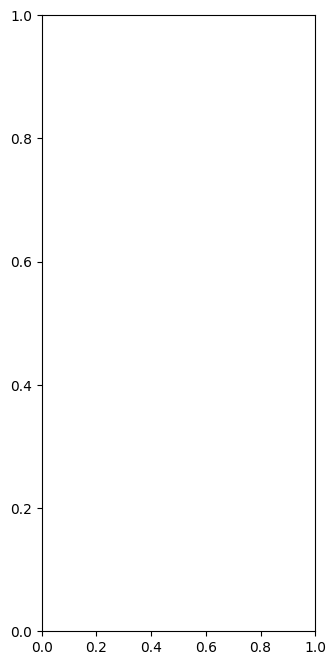

In [ ]:
# Définir les variables globales
NUM_CLASSES = 9
SEED = 42

# Lancer le pipeline complet
trained_models = complete_pipeline()

In [8]:
def find_matching_files():
    """
    Trouve les paires de fichiers image et masque de segmentation dans les dossiers Cityscapes
    
    Returns:
        data_pairs: liste de dictionnaires contenant les chemins des paires d'images et de masques,
                    ainsi que leur split (train/val/test)
    """
    # Chemins directs aux dossiers d'images et de masques
    LEFTIMG_DIR = 'leftImg8bit'
    GTFINE_DIR = 'gtFine'
    data_pairs = []
    
    # Vérifier si les dossiers existent
    if not os.path.exists(GTFINE_DIR):
        raise ValueError(f"Dossier d'annotations {GTFINE_DIR} non trouvé")
    
    if not os.path.exists(LEFTIMG_DIR):
        print(f"Dossier d'images {LEFTIMG_DIR} non trouvé, vérification alternative...")
        has_leftimg = False
    else:
        has_leftimg = True
    
    # Parcourir les sous-dossiers de gtFine (train, val, test)
    for split in ['train', 'val', 'test']:
        img_split_dir = os.path.join(LEFTIMG_DIR, split)
        mask_split_dir = os.path.join(GTFINE_DIR, split)
        
        if not os.path.exists(img_split_dir) or not os.path.exists(mask_split_dir):
            print(f"Dossier manquant: {img_split_dir} ou {mask_split_dir}")
            continue
        
        for city in os.listdir(img_split_dir):
            img_city_dir = os.path.join(img_split_dir, city)
            mask_city_dir = os.path.join(mask_split_dir, city)
            
            if not os.path.exists(img_city_dir) or not os.path.exists(mask_city_dir):
                print(f"Dossier ville manquant: {img_city_dir} ou {mask_city_dir}")
                continue
            
            for img_file in os.listdir(img_city_dir):
                if not img_file.endswith('.png'):
                    continue
                
                # Format pour les masques: [filename]_gtFine_labelIds.png
                img_basename = img_file.split('_leftImg8bit')[0]
                mask_file = f"{img_basename}_gtFine_labelIds.png"
                mask_path = os.path.join(mask_city_dir, mask_file)
                
                if os.path.exists(mask_path):
                    img_path = os.path.join(img_city_dir, img_file)
                    data_pairs.append((img_path, mask_path))
                else:
                    # Pour le débogage
                    print(f"Masque manquant: {mask_path}")
    
    print(f"Trouvé {len(data_pairs)} paires d'images et masques")
    return data_pairs

In [ ]:
def visualize_models_comparison():
    """
    Fonction complète pour visualiser et comparer les prédictions des 3 modèles
    """
    import os
    import cv2
    import numpy as np
    import tensorflow as tf
    import matplotlib.pyplot as plt
    import pandas as pd
    import random
    from datetime import datetime
    from sklearn.model_selection import train_test_split
    import time
    import traceback
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
    from sklearn.model_selection import train_test_split
    
    from tqdm import tqdm
    
    
    # Définir les constantes
    NUM_CLASSES = 9
    SEED = 42
    
    # Configuration aléatoire pour la reproductibilité
    np.random.seed(SEED)
    random.seed(SEED)
    tf.random.set_seed(SEED)
    
    # Définir les métriques personnalisées (utilisées pour charger les modèles)
    def dice_coefficient(y_true, y_pred):
        numerator = 2 * tf.reduce_sum(y_true * y_pred)
        denominator = tf.reduce_sum(y_true + y_pred)
        return numerator / (denominator + tf.keras.backend.epsilon())
    
    def jaccard_index(y_true, y_pred):
        intersection = tf.reduce_sum(y_true * y_pred)
        union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
        return intersection / (union + tf.keras.backend.epsilon())
    
    # 1. Charger les modèles
    print("Chargement des modèles...")
    
    model_paths = {
        "unet_mini_lightweight": None,
        "unet_mini": None,
        "vgg16_unet_384": None
    }
    
    # Rechercher les modèles les plus récents
    for model_name in model_paths.keys():
        latest_model = None
        latest_time = 0
        
        for root, dirs, files in os.walk("results"):
            for file in files:
                if (file == "model.h5" or file == "model.keras") and model_name in root:
                    file_path = os.path.join(root, file)
                    file_time = os.path.getmtime(file_path)
                    
                    if file_time > latest_time:
                        latest_time = file_time
                        latest_model = file_path
        
        model_paths[model_name] = latest_model
    
    # Charger les modèles trouvés
    loaded_models = {}
    custom_objects = {
        'dice_coefficient': dice_coefficient,
        'jaccard_index': jaccard_index
    }
    
    for model_name, model_path in model_paths.items():
        if model_path:
            print(f"Chargement de {model_name} depuis {model_path}")
            try:
                model = tf.keras.models.load_model(model_path, custom_objects=custom_objects)
                loaded_models[model_name] = model
            except Exception as e:
                print(f"Erreur lors du chargement de {model_name}: {e}")
        else:
            print(f"Aucun modèle trouvé pour {model_name}")
    
    if not loaded_models:
        print("Aucun modèle n'a pu être chargé. Impossible de continuer.")
        return
    
    # 2. Obtenir quelques images de test
    def find_matching_files():
        """Récupère les paires d'images et masques"""
        # Chemins directs aux dossiers principaux (à la racine du projet)
        LEFTIMG_DIR = 'leftImg8bit'
        GTFINE_DIR = 'gtFine'
        
        data_pairs = []
        
        print(f"Recherche de fichiers dans: {LEFTIMG_DIR} et {GTFINE_DIR}")
        
        # Vérifier si les dossiers existent
        if not os.path.exists(LEFTIMG_DIR):
            print(f"⚠️ Dossier d'images {LEFTIMG_DIR} non trouvé!")
            return data_pairs
        
        if not os.path.exists(GTFINE_DIR):
            print(f"⚠️ Dossier d'annotations {GTFINE_DIR} non trouvé!")
            return data_pairs
        
        # Afficher la structure pour déboguer
        print(f"Structure de {LEFTIMG_DIR}:", os.listdir(LEFTIMG_DIR))
        print(f"Structure de {GTFINE_DIR}:", os.listdir(GTFINE_DIR))
        
        # Parcourir les sous-dossiers (train, val, test)
        for split in ['train', 'val', 'test']:
            img_split_dir = os.path.join(LEFTIMG_DIR, split)
            mask_split_dir = os.path.join(GTFINE_DIR, split)
            
            if not os.path.exists(img_split_dir) or not os.path.exists(mask_split_dir):
                print(f"Dossier manquant: {img_split_dir} ou {mask_split_dir}")
                continue
            
            print(f"Traitement du split '{split}'...")
            
            for city in os.listdir(img_split_dir):
                img_city_dir = os.path.join(img_split_dir, city)
                mask_city_dir = os.path.join(mask_split_dir, city)
                
                if not os.path.exists(img_city_dir) or not os.path.exists(mask_city_dir):
                    print(f"Dossier ville manquant: {img_city_dir} ou {mask_city_dir}")
                    continue
                
                for img_file in os.listdir(img_city_dir):
                    if not img_file.endswith('.png'):
                        continue
                    
                    # Format pour les masques: [filename]_gtFine_labelIds.png
                    img_basename = img_file.split('_leftImg8bit')[0]
                    mask_file = f"{img_basename}_gtFine_labelIds.png"
                    mask_path = os.path.join(mask_city_dir, mask_file)
                    
                    if os.path.exists(mask_path):
                        img_path = os.path.join(img_city_dir, img_file)
                        data_pairs.append((img_path, mask_path))
                    else:
                        # Pour déboguer les masques manquants
                        print(f"Masque manquant: {mask_path}")
        
        print(f"Trouvé {len(data_pairs)} paires d'images et masques")
        
        # Afficher quelques exemples pour vérification
        if data_pairs:
            print("Exemples de paires trouvées:")
            for i in range(min(3, len(data_pairs))):
                print(f"  Image: {data_pairs[i][0]}")
                print(f"  Masque: {data_pairs[i][1]}")
        
        return data_pairs
    
    # Récupérer les paires de données
    data_pairs = find_matching_files()
    
    if not data_pairs:
        print("Aucune paire d'images trouvée. Utilisation d'exemples aléatoires.")
        # Créer des données synthétiques pour le test
        synthetic_data = []
        for i in range(10):
            img = np.random.randint(0, 255, (384, 384, 3), dtype=np.uint8)
            mask = np.random.randint(0, NUM_CLASSES, (384, 384), dtype=np.uint8)
            synthetic_data.append((img, mask))
        data_pairs = synthetic_data
    
    # Diviser en ensembles de train/test
    _, test_pairs = train_test_split(data_pairs, test_size=0.2, random_state=SEED)
    
    # 3. Définir une classe pour préparer les images pour les modèles
    class ImagePreprocessor:
        """Prépare les images pour l'inférence avec différents modèles"""
        
        def __init__(self, class_mapping=None):
            # Mapping des classes pour les masques
            self.class_mapping = class_mapping or {
            0: 0,    # unlabeled -> background
            1: 0,    # ego vehicle -> background
            2: 0,    # rectification border -> background
            3: 0,    # out of roi -> background
            4: 0,    # static -> background
            5: 0,    # dynamic -> background
            6: 0,    # ground -> background
            7: 1,    # road
            8: 2,    # sidewalk
            9: 0,    # parking -> background
            10: 0,   # rail track -> background
            11: 3,   # building
            12: 3,   # wall (fusionné avec building)
            13: 5,   # fence
            14: 0,   # guard rail -> background
            15: 0,   # bridge -> background
            16: 0,   # tunnel -> background
            17: 6,   # pole
            18: 6,   # polegroup (fusionné avec pole)
            19: 7,   # traffic light
            20: 7,   # traffic sign (fusionné avec traffic light)
            21: 8,   # vegetation
            22: 8,   # terrain (fusionné avec vegetation)
            23: 0,   # sky -> background
            24: 7,   # person
            25: 7,   # rider (fusionné avec person)
            26: 8,   # car (fusionné dans Vehicle)
            27: 8,   # truck (fusionné dans Vehicle)
            28: 8,   # bus (fusionné dans Vehicle)
            29: 8,   # caravan (fusionné dans Vehicle)
            30: 8,   # trailer (fusionné dans Vehicle)
            31: 8,   # train (fusionné dans Vehicle)
            32: 8,   # motorcycle (fusionné dans Vehicle)
            33: 8,   # bicycle (fusionné dans Vehicle)
            255: 0,  # license plate -> background
            -1: 0    # pour traiter les valeurs négatives
        }
        
        def preprocess_image(self, img_path, target_size):
            """Charge et prépare une image pour l'inférence"""
            # Charger l'image
            if isinstance(img_path, str):
                # Charger depuis le chemin
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            else:
                # Utiliser directement l'image fournie
                img = img_path
            
            # Redimensionner
            img_resized = cv2.resize(img, target_size)
            
            # Normaliser
            img_normalized = img_resized.astype(np.float32) / 255.0
            
            # Ajouter la dimension du batch
            img_batch = np.expand_dims(img_normalized, axis=0)
            
            return img, img_batch
        
        def preprocess_mask(self, mask_path, target_size=None):
            """Charge et prépare un masque pour la comparaison"""
            # Charger le masque
            if isinstance(mask_path, str):
                # Charger depuis le chemin
                mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
            else:
                # Utiliser directement le masque fourni
                mask = mask_path
            
            # Appliquer le mapping des classes
            mask_mapped = np.zeros_like(mask)
            for old_class, new_class in self.class_mapping.items():
                mask_mapped[mask == old_class] = new_class
            
            # Redimensionner si nécessaire
            if target_size:
                mask_mapped = cv2.resize(mask_mapped, target_size, interpolation=cv2.INTER_NEAREST)
            
            return mask_mapped
    
    # 4. Fonction pour visualiser les prédictions
    def visualize_model_predictions(models, test_samples, num_samples=5, save_dir=None):
        """
        Visualise et compare les prédictions des modèles sur des images de test
        """
        # Créer le préprocesseur d'images
        preprocessor = ImagePreprocessor()
        
        # Créer le dossier pour sauvegarder les résultats
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        else:
            timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
            save_dir = f"results/visualizations_{timestamp}"
            os.makedirs(save_dir, exist_ok=True)
        
        # Sélectionner aléatoirement des échantillons de test
        selected_samples = random.sample(test_samples, min(num_samples, len(test_samples)))
        
        # Définir les noms des classes
        class_names = [
            "Background",  # 0
            "Road",        # 1
            "Sidewalk",    # 2 
            "Building",    # 3
            "Wall",        # 4
            "Fence",       # 5
            "Pole",        # 6
            "Traffic Light", #7
            "Vegetation"   # 8
        ]
        
        # Créer une légende des classes
        cmap = plt.cm.get_cmap('tab20', NUM_CLASSES)
        colors = [cmap(i) for i in range(NUM_CLASSES)]
        
        plt.figure(figsize=(10, 5))
        patches = []
        for i in range(NUM_CLASSES):
            patch = plt.Rectangle((0, 0), 1, 1, fc=colors[i])
            patches.append(patch)
        plt.legend(patches, [f"{i}: {name}" for i, name in enumerate(class_names)], 
                    loc='center', fontsize=12)
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'class_legend.png'))
        plt.close()
        
        # Pour chaque échantillon sélectionné
        for i, pair in enumerate(selected_samples):
            print(f"Traitement de l'échantillon {i+1}/{len(selected_samples)}...")
            
            # Extraire l'image et le masque
            img_path = None
            mask_path = None
            
            if isinstance(pair, tuple) and len(pair) >= 2:
                img_path, mask_path = pair
            else:
                img_path = pair
            
            # Vérifier si img_path et mask_path sont des chaînes de caractères
            has_mask = isinstance(mask_path, str) and os.path.exists(mask_path)
            
            # Si mask_path est un tableau NumPy, on considère qu'il s'agit d'un masque valide
            if not has_mask and isinstance(mask_path, np.ndarray):
                has_mask = True
            
            # Liste des tailles d'images requises par les modèles
            model_input_sizes = {
                "unet_mini_lightweight": (384, 384),
                "unet_mini": (384, 384),
                "vgg16_unet_384": (256, 256) if "vgg16_unet" in models else (384, 384)
            }
            
            # Obtenir la taille d'image correcte pour chaque modèle
            model_predictions = {}
            original_img = None
            
            for model_name, model in models.items():
                # Déterminer la taille d'entrée
                input_size = model_input_sizes.get(model_name, (384, 384))
                
                # Prétraiter l'image
                try:
                    original_img, img_batch = preprocessor.preprocess_image(img_path, input_size)
                
                    # Faire la prédiction
                    pred = model.predict(img_batch, verbose=0)
                    pred_mask = np.argmax(pred[0], axis=-1)
                    
                    # Redimensionner la prédiction à la taille de l'image d'origine
                    if pred_mask.shape[:2] != original_img.shape[:2]:
                        pred_mask = cv2.resize(pred_mask.astype(np.uint8), 
                                              (original_img.shape[1], original_img.shape[0]), 
                                              interpolation=cv2.INTER_NEAREST)
                    
                    # Stocker la prédiction
                    model_predictions[model_name] = pred_mask
                except Exception as e:
                    print(f"Erreur lors de la prédiction avec {model_name}: {e}")
                    traceback.print_exc()
            
            if not model_predictions:
                print(f"Aucune prédiction réussie pour l'échantillon {i+1}. Passage au suivant.")
                continue
            
            # Charger le masque de vérité terrain s'il existe
            true_mask = None
            if has_mask:
                try:
                    true_mask = preprocessor.preprocess_mask(mask_path)
                    # Redimensionner à la taille de l'image d'origine
                    if true_mask.shape[:2] != original_img.shape[:2]:
                        true_mask = cv2.resize(true_mask.astype(np.uint8), 
                                              (original_img.shape[1], original_img.shape[0]), 
                                              interpolation=cv2.INTER_NEAREST)
                except Exception as e:
                    print(f"Erreur lors du chargement du masque réel: {e}")
                    traceback.print_exc()
            
            # Créer une figure pour cet échantillon
            n_cols = len(model_predictions) + (2 if true_mask is not None else 1)
            fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 5, 5))
            
            # S'assurer que axes est toujours un tableau même s'il n'y a qu'un seul subplot
            if n_cols == 1:
                axes = [axes]
            
            # Afficher l'image originale
            axes[0].imshow(original_img)
            axes[0].set_title("Image originale", fontsize=14)
            axes[0].axis('off')
            
            # Afficher le masque de vérité terrain s'il existe
            col_offset = 1
            if true_mask is not None:
                # Vérifier si le masque est uniforme
                unique_classes = np.unique(true_mask)
                is_uniform = len(unique_classes) <= 1
                
                axes[1].imshow(true_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
                title = "Vérité terrain"
                if is_uniform:
                    title += f" ⚠️ (Uniforme: classe {unique_classes[0]})"
                axes[1].set_title(title, fontsize=14)
                axes[1].axis('off')
                col_offset = 2
            
            # Afficher les prédictions de chaque modèle
            for j, (model_name, pred_mask) in enumerate(model_predictions.items()):
                axes[j+col_offset].imshow(pred_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
                
                # Calculer la précision pixel à pixel si la vérité terrain existe
                if true_mask is not None:
                    pixel_acc = np.mean(pred_mask == true_mask)
                    axes[j+col_offset].set_title(f"{model_name}\nPrécision: {pixel_acc:.3f}", fontsize=14)
                else:
                    axes[j+col_offset].set_title(f"{model_name}", fontsize=14)
                
                axes[j+col_offset].axis('off')
            
            plt.tight_layout()
            plt.savefig(os.path.join(save_dir, f"comparison_sample_{i+1}.png"), bbox_inches='tight')
            plt.close()
            
            # Créer une visualisation plus détaillée avec superposition (overlay)
            for model_name, pred_mask in model_predictions.items():
                fig, axes = plt.subplots(1, 3, figsize=(18, 6))
                
                # Image originale
                axes[0].imshow(original_img)
                axes[0].set_title("Image originale", fontsize=14)
                axes[0].axis('off')
                
                # Masque prédit
                axes[1].imshow(pred_mask, cmap='tab20', vmin=0, vmax=NUM_CLASSES-1)
                axes[1].set_title(f"Prédiction - {model_name}", fontsize=14)
                axes[1].axis('off')
                
                # Méthode simplifiée pour la superposition
                # Afficher l'image d'abord
                axes[2].imshow(original_img)
                
                # Puis superposer le masque avec transparence
                masked = np.ma.masked_where(pred_mask == 0, pred_mask)  # Masquer le fond
                axes[2].imshow(masked, cmap='tab20', alpha=0.6, vmin=0, vmax=NUM_CLASSES-1)
                
                axes[2].set_title("Superposition", fontsize=14)
                axes[2].axis('off')
                
                plt.tight_layout()
                plt.savefig(os.path.join(save_dir, f"overlay_{model_name}_sample_{i+1}.png"), bbox_inches='tight')
                plt.close()
        
        print(f"Visualisations sauvegardées dans {save_dir}")
        return save_dir
    
    # 5. Fonction pour créer une analyse comparative des modèles
    def create_model_comparison_chart(models, test_pairs, num_test_samples=30, save_dir=None):
        """
        Crée des graphiques comparatifs pour les différents modèles
        """
        if save_dir is None:
            timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
            save_dir = f"results/model_analysis_{timestamp}"
        
        # S'assurer que le répertoire existe
        os.makedirs(save_dir, exist_ok=True)
        
        print(f"Analyse comparative des modèles sur {num_test_samples} échantillons...")
        
        # Préprocesseur d'images
        preprocessor = ImagePreprocessor()
        
        # Sélectionner un sous-ensemble de données de test
        test_subset = random.sample(test_pairs, min(num_test_samples, len(test_pairs)))
        
        # Dictionnaires pour stocker les métriques
        model_metrics = {model_name: {'pixel_acc': [], 'dice': [], 'inference_time': []} 
                        for model_name in models.keys()}
        
        # Pour chaque échantillon de test
        for i, pair in enumerate(test_subset):
            if i % 5 == 0:
                print(f"  Progression: {i}/{len(test_subset)} échantillons")
            
            # Extraire l'image et le masque
            img_path = None
            mask_path = None
            
            if isinstance(pair, tuple) and len(pair) >= 2:
                img_path, mask_path = pair
            else:
                continue  # Passer si pas de masque pour l'évaluation
            
            # Vérifier si mask_path est une chaîne ou un tableau NumPy
            if not (isinstance(mask_path, str) or isinstance(mask_path, np.ndarray)):
                continue
            
            # Charger le masque de vérité terrain
            try:
                true_mask = preprocessor.preprocess_mask(mask_path)
            except Exception as e:
                print(f"Erreur lors du chargement du masque: {e}")
                continue  # Passer si masque non chargeable
            
            # Tester chaque modèle
            for model_name, model in models.items():
                try:
                    # Déterminer la taille d'entrée
                    input_size = (256, 256) if "vgg16" in model_name else (384, 384)
                    
                    # Prétraiter l'image
                    _, img_batch = preprocessor.preprocess_image(img_path, input_size)
                    
                    # Mesurer le temps d'inférence
                    start_time = time.time()
                    pred = model.predict(img_batch, verbose=0)
                    inference_time = (time.time() - start_time) * 1000  # en millisecondes
                    
                    # Traiter la prédiction
                    pred_mask = np.argmax(pred[0], axis=-1)
                    
                    # Redimensionner à la taille du masque réel
                    if pred_mask.shape != true_mask.shape:
                        pred_mask = cv2.resize(pred_mask.astype(np.uint8), 
                                            (true_mask.shape[1], true_mask.shape[0]), 
                                            interpolation=cv2.INTER_NEAREST)
                    
                    # Calculer les métriques
                    pixel_acc = np.mean(pred_mask == true_mask)
                    
                    # Calculer le coefficient de Dice
                    dice_scores = []
                    for c in range(NUM_CLASSES):
                        true_class = (true_mask == c).astype(np.float32)
                        pred_class = (pred_mask == c).astype(np.float32)
                        
                        intersection = np.sum(true_class * pred_class)
                        union = np.sum(true_class) + np.sum(pred_class)
                        
                        # Correction pour éviter la division par zéro
                        if np.sum(union) > 0:
                            dice_scores.append(2 * intersection / union)
                    
                    avg_dice = np.mean(dice_scores) if dice_scores else 0
                    
                    # Stocker les métriques
                    model_metrics[model_name]['pixel_acc'].append(pixel_acc)
                    model_metrics[model_name]['dice'].append(avg_dice)
                    model_metrics[model_name]['inference_time'].append(inference_time)
                    
                except Exception as e:
                    print(f"Erreur avec {model_name} sur l'échantillon {i}: {e}")
                    traceback.print_exc()
        
        # Calculer les moyennes
        summary = {}
        for model_name, metrics in model_metrics.items():
            if metrics['pixel_acc'] and metrics['dice'] and metrics['inference_time']:
                summary[model_name] = {
                    'avg_pixel_acc': np.mean(metrics['pixel_acc']),
                    'avg_dice': np.mean(metrics['dice']),
                    'avg_inference_time': np.mean(metrics['inference_time']),
                    'model_size_mb': get_model_size_mb(models[model_name])
                }
            else:
                print(f"Pas assez de données pour le modèle {model_name}")
                summary[model_name] = {
                    'avg_pixel_acc': 0,
                    'avg_dice': 0,
                    'avg_inference_time': 0,
                    'model_size_mb': get_model_size_mb(models[model_name])
                }
        
        # Créer un DataFrame pour l'affichage
        summary_df = pd.DataFrame(summary).T
        summary_df = summary_df.sort_values('avg_dice', ascending=False)
        
        print("\nRésumé des performances:")
        print(summary_df)
        
        # Sauvegarder les résultats
        try:
            summary_df.to_csv(os.path.join(save_dir, 'model_comparison.csv'))
        except Exception as e:
            print(f"Erreur lors de la sauvegarde du CSV: {e}")
        
        # Créer des graphiques
        try:
            plt.figure(figsize=(12, 6))
            
            # Précision pixel
            plt.subplot(1, 2, 1)
            plt.bar(summary_df.index, summary_df['avg_pixel_acc'])
            plt.title('Précision pixel moyenne')
            plt.ylim(0, 1)
            plt.xticks(rotation=45, ha='right')
            
            # Coefficient de Dice
            plt.subplot(1, 2, 2)
            plt.bar(summary_df.index, summary_df['avg_dice'])
            plt.title('Coefficient de Dice moyen')
            plt.ylim(0, 1)
            plt.xticks(rotation=45, ha='right')
            
            plt.tight_layout()
            plt.savefig(os.path.join(save_dir, 'accuracy_comparison.png'))
            plt.close()
            
            # Temps d'inférence
            plt.figure(figsize=(10, 6))
            plt.bar(summary_df.index, summary_df['avg_inference_time'])
            plt.title('Temps d\'inférence moyen (ms)')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.savefig(os.path.join(save_dir, 'inference_time_comparison.png'))
            plt.close()
            
            # Taille du modèle vs performance
            plt.figure(figsize=(10, 6))
            plt.scatter(summary_df['model_size_mb'], summary_df['avg_dice'], s=100)
            
            # Ajouter les noms des modèles
            for i, model_name in enumerate(summary_df.index):
                plt.annotate(model_name, 
                            (summary_df['model_size_mb'][i], summary_df['avg_dice'][i]),
                            xytext=(5, 5), textcoords='offset points')
            
            plt.title('Taille du modèle vs Performance')
            plt.xlabel('Taille du modèle (Mo)')
            plt.ylabel('Coefficient de Dice moyen')
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.savefig(os.path.join(save_dir, 'model_size_vs_performance.png'))
            plt.close()
        except Exception as e:
            print(f"Erreur lors de la création des graphiques: {e}")
            traceback.print_exc()
        
        print(f"Analyse comparative sauvegardée dans {save_dir}")
        return summary_df
    
    # Fonction utilitaire pour estimer la taille du modèle
    def get_model_size_mb(model):
        """Calcule la taille approximative du modèle en Mo"""
        # Compter les paramètres
        num_params = model.count_params()
        # Chaque paramètre est un float32 (4 bytes)
        size_bytes = num_params * 4
        # Convertir en Mo
        size_mb = size_bytes / (1024 * 1024)
        return size_mb
    
    # 6. Exécuter les visualisations
    print("\n===== VISUALISATION ET COMPARAISON DES MODÈLES =====")
    
    # Sélectionner quelques échantillons pour la visualisation
    random.seed(SEED)
    visualization_samples = random.sample(test_pairs, min(10, len(test_pairs)))
    
    # Créer un dossier pour les résultats
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    results_dir = f"results/model_comparison_{timestamp}"
    os.makedirs(results_dir, exist_ok=True)
    
    # Visualiser les prédictions
    print("\n1. Visualisation des prédictions...")
    visualization_dir = visualize_model_predictions(
        loaded_models, 
        visualization_samples, 
        num_samples=5,
        save_dir=os.path.join(results_dir, "visualizations")
    )
    
    # Analyse comparative
    print("\n2. Analyse comparative des modèles...")
    try:
        analysis_dir = os.path.join(results_dir, "analysis")
        os.makedirs(analysis_dir, exist_ok=True)  # Créer explicitement le répertoire
        
        summary_df = create_model_comparison_chart(
            loaded_models,
            test_pairs,
            num_test_samples=min(50, len(test_pairs)),
            save_dir=analysis_dir
        )
    except Exception as e:
        print(f"Erreur lors de l'analyse comparative: {e}")
        traceback.print_exc()
        summary_df = pd.DataFrame()
    
    # Sauvegarder un rapport récapitulatif
    try:
        with open(os.path.join(results_dir, 'README.md'), 'w') as f:
            f.write("# Comparaison des modèles de segmentation\n\n")
            f.write(f"Date: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}\n\n")
            
            f.write("## Modèles évalués\n\n")
            for model_name in loaded_models.keys():
                f.write(f"- {model_name}\n")
            
            f.write("\n## Résumé des performances\n\n")
            if not summary_df.empty:
                f.write(summary_df.to_markdown())
            else:
                f.write("*Aucune métrique disponible*\n")
            
            f.write("\n\n## Visualisations\n\n")
            f.write("Des visualisations détaillées sont disponibles dans le dossier 'visualizations'.\n")
            
            f.write("\n## Analyse\n\n")
            f.write("Les graphiques d'analyse comparative sont disponibles dans le dossier 'analysis'.\n")
    except Exception as e:
        print(f"Erreur lors de la création du rapport README: {e}")
    
    print(f"\nComparaison complète sauvegardée dans {results_dir}")
    print("Un rapport récapitulatif (README.md) a été créé dans ce dossier.")
    
    return {
        "models": loaded_models,
        "summary": summary_df,
        "results_dir": results_dir
    }

In [ ]:
#visualize_models_comparison()

Chargement des modèles...
Chargement de unet_mini_lightweight depuis results\unet_mini_lightweight_aug_20250408-074245\model.keras
Chargement de unet_mini depuis results\unet_mini_20250408-104108\model.keras
Chargement de vgg16_unet_384 depuis results\vgg16_unet_384_20250407-092552\model.keras
Recherche de fichiers dans: leftImg8bit et gtFine
Structure de leftImg8bit: ['test', 'train', 'val']
Structure de gtFine: ['test', 'train', 'val']
Traitement du split 'train'...
Traitement du split 'val'...
Traitement du split 'test'...
Trouvé 5000 paires d'images et masques
Exemples de paires trouvées:
  Image: leftImg8bit\train\aachen\aachen_000000_000019_leftImg8bit.png
  Masque: gtFine\train\aachen\aachen_000000_000019_gtFine_labelIds.png
  Image: leftImg8bit\train\aachen\aachen_000001_000019_leftImg8bit.png
  Masque: gtFine\train\aachen\aachen_000001_000019_gtFine_labelIds.png
  Image: leftImg8bit\train\aachen\aachen_000002_000019_leftImg8bit.png
  Masque: gtFine\train\aachen\aachen_000002_0

KeyboardInterrupt: 

In [31]:
def find_matching_files():
    """
    Trouve les paires de fichiers image et masque de segmentation dans les dossiers Cityscapes
    
    Returns:
        data_pairs: liste de dictionnaires contenant les chemins des paires d'images et de masques,
                    ainsi que leur split (train/val/test)
    """
    # Chemins directs aux dossiers d'images et de masques
    LEFTIMG_DIR = 'leftImg8bit'
    GTFINE_DIR = 'gtFine'
    data_pairs = []
    
    # Vérifier si les dossiers existent
    if not os.path.exists(GTFINE_DIR):
        raise ValueError(f"Dossier d'annotations {GTFINE_DIR} non trouvé")
    
    if not os.path.exists(LEFTIMG_DIR):
        print(f"Dossier d'images {LEFTIMG_DIR} non trouvé, vérification alternative...")
        has_leftimg = False
    else:
        has_leftimg = True
    
    # Parcourir les sous-dossiers de gtFine (train, val, test)
    for split in ['train', 'val', 'test']:
        img_split_dir = os.path.join(LEFTIMG_DIR, split)
        mask_split_dir = os.path.join(GTFINE_DIR, split)
        
        if not os.path.exists(img_split_dir) or not os.path.exists(mask_split_dir):
            print(f"Dossier manquant: {img_split_dir} ou {mask_split_dir}")
            continue
        
        for city in os.listdir(img_split_dir):
            img_city_dir = os.path.join(img_split_dir, city)
            mask_city_dir = os.path.join(mask_split_dir, city)
            
            if not os.path.exists(img_city_dir) or not os.path.exists(mask_city_dir):
                print(f"Dossier ville manquant: {img_city_dir} ou {mask_city_dir}")
                continue
            
            for img_file in os.listdir(img_city_dir):
                if not img_file.endswith('.png'):
                    continue
                
                # Format pour les masques: [filename]_gtFine_labelIds.png
                img_basename = img_file.split('_leftImg8bit')[0]
                mask_file = f"{img_basename}_gtFine_labelIds.png"
                mask_path = os.path.join(mask_city_dir, mask_file)
                
                if os.path.exists(mask_path):
                    img_path = os.path.join(img_city_dir, img_file)
                    data_pairs.append((img_path, mask_path))
                else:
                    # Pour le débogage
                    print(f"Masque manquant: {mask_path}")
    
    print(f"Trouvé {len(data_pairs)} paires d'images et masques")
    return data_pairs

In [16]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, 
                                    BatchNormalization, Dropout, Conv2DTranspose, 
                                    AveragePooling2D, Activation, SeparableConv2D,
                                    GlobalAveragePooling2D, Reshape)
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint, 
                                      ReduceLROnPlateau, TensorBoard)
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import time
import json
import albumentations as A
from glob import glob
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import random
from datetime import datetime
from sklearn.model_selection import train_test_split
import time
import traceback
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from tqdm import tqdm

SEED = 42
NUM_CLASSES = 9  # Nombre de classes pour Cityscapes

def complete_pipeline():
    """
    Pipeline complet d'entraînement et d'évaluation des modèles de segmentation.
    Version optimisée pour UNet Mini Lightweight, UNet et VGG16-UNet
    """
    print("\n===== PIPELINE COMPLET D'ENTRAÎNEMENT ET D'ÉVALUATION OPTIMISÉ =====")
    
    # 1. Configuration générale
    SEED = 42
    np.random.seed(SEED)
    random.seed(SEED)
    tf.random.set_seed(SEED)
    
    # 2. Préparer les données en filtrant les masques problématiques
    data_pairs = prepare_dataset_with_filtering()
    
    # 3. Diviser en ensembles d'entraînement, validation et test
    train_pairs, test_pairs = train_test_split(data_pairs, test_size=0.15, random_state=SEED)
    train_pairs, val_pairs = train_test_split(train_pairs, test_size=0.15, random_state=SEED)
    
    print(f"Répartition des données:")
    print(f"  - Entraînement: {len(train_pairs)} paires")
    print(f"  - Validation: {len(val_pairs)} paires")
    print(f"  - Test: {len(test_pairs)} paires")
    
    # 4. Configuration optimisée des modèles
    model_configs = [
        {
            "name": "unet_mini_lightweight",
            "model_fn": optimized_unet_mini_lightweight,  # Version optimisée
            "image_size": (256, 256),  # Résolution plus basse pour modèle léger
            "batch_size": 16,  # Batch size augmenté
            "epochs": 30,  # Plus d'époques
            "steps_per_epoch": 100,
            "augmentation": True,
            "learning_rate": 1e-3,
            "class_weights": get_class_weights(),  # Utilisation de poids de classe
            "scheduler": True  # Scheduler d'apprentissage
        },
        {
            "name": "unet_mini",
            "model_fn": optimized_unet_mini,  # Version optimisée
            "image_size": (288, 288),  # Taille intermédiaire
            "batch_size": 8,
            "epochs": 35,
            "steps_per_epoch": 120,
            "augmentation": True,
            "learning_rate": 5e-4,
            "class_weights": get_class_weights(),
            "scheduler": True
        },
        {
            "name": "vgg16_unet",
            "model_fn": optimized_vgg16_unet,  # Version optimisée
            "image_size": (224, 224),  # Taille optimale pour VGG16
            "batch_size": 8,
            "epochs": 40,
            "steps_per_epoch": 100,
            "augmentation": True,
            "learning_rate": 1e-4,
            "class_weights": get_class_weights(alpha=1.5),  # Pondération plus agressive
            "scheduler": True,
            "fine_tuning": True  # Fine-tuning progressif
        }
    ]
    
    # 5. Entraîner tous les modèles
    trained_models = {}
    
    for config in model_configs:
        print(f"\n----- ENTRAÎNEMENT DE {config['name']} -----")
        model, history = train_model_with_config(
            train_pairs, val_pairs, config
        )
        trained_models[config['name']] = {"model": model, "history": history, "config": config}
    
    # 6. Évaluer tous les modèles
    print("\n----- ÉVALUATION COMPLÈTE DES MODÈLES -----")
    evaluation_results = evaluate_all_models(trained_models, test_pairs)
    
    # 7. Analyse comparative visuelle
    print("\n----- ANALYSE COMPARATIVE VISUELLE -----")
    compare_model_predictions(trained_models, test_pairs, num_samples=5)
    
    # 8. Sauvegarder les résultats
    print("\n----- SAUVEGARDE DES RÉSULTATS -----")
    save_comparison_results(trained_models, evaluation_results)
    
    return trained_models

def prepare_dataset_with_filtering():
    """
    Prépare le jeu de données en filtrant les masques problématiques 
    avec une approche plus robuste
    """
    print("Chargement et filtrage des données...")
    
    # Charger toutes les paires
    all_pairs = find_matching_files()
    print(f"Total de paires trouvées: {len(all_pairs)}")
    
    # Échantillonner un sous-ensemble pour la vérification (pour accélérer)
    check_subset = random.sample(all_pairs, min(500, len(all_pairs)))
    
    print(f"Vérification des masques sur {len(check_subset)} échantillons...")
    problematic_count = 0
    uniform_count = 0
    missing_count = 0
    valid_count = 0
    
    # Vérifier les masques du sous-ensemble
    for i, pair in enumerate(check_subset):
        if isinstance(pair, tuple) and len(pair) >= 2:
            img_path, mask_path = pair
        else:
            img_path = pair.get('image_path')
            mask_path = pair.get('mask_path')
        
        try:
            # Vérifier si le masque existe
            if not os.path.exists(mask_path):
                missing_count += 1
                continue
            
            # Essayer de charger le masque avec plusieurs méthodes
            mask = None
            for read_mode in [cv2.IMREAD_UNCHANGED, cv2.IMREAD_GRAYSCALE, cv2.IMREAD_COLOR]:
                mask_temp = cv2.imread(mask_path, read_mode)
                if mask_temp is not None and mask_temp.size > 0:
                    if read_mode == cv2.IMREAD_COLOR:
                        mask_temp = cv2.cvtColor(mask_temp, cv2.COLOR_BGR2GRAY)
                    mask = mask_temp
                    break
            
            if mask is None:
                problematic_count += 1
                continue
                
            # Vérifier si le masque est uniforme ou presque uniforme
            unique_values, counts = np.unique(mask, return_counts=True)
            
            # Si une seule classe occupe plus de 95% du masque
            most_common_idx = np.argmax(counts)
            most_common_pct = counts[most_common_idx] / mask.size
            
            if most_common_pct > 0.95:
                uniform_count += 1
                if i < 10:  # Afficher seulement les 10 premiers
                    print(f"Masque uniforme: {mask_path} ({most_common_pct*100:.1f}% classe {unique_values[most_common_idx]})")
                continue
            
            # C'est un masque valide
            valid_count += 1
            
        except Exception as e:
            problematic_count += 1
            if i < 5:
                print(f"Erreur avec {mask_path}: {e}")
    
    # Statistiques sur la qualité des données
    total_checked = len(check_subset)
    print(f"Statistiques sur {total_checked} échantillons:")
    print(f"  - Valides: {valid_count} ({valid_count/total_checked*100:.1f}%)")
    print(f"  - Uniformes: {uniform_count} ({uniform_count/total_checked*100:.1f}%)")
    print(f"  - Manquants: {missing_count} ({missing_count/total_checked*100:.1f}%)")
    print(f"  - Problématiques: {problematic_count} ({problematic_count/total_checked*100:.1f}%)")
    
    # Si plus de 25% des données sont problématiques, appliquer un filtrage
    problem_rate = (uniform_count + missing_count + problematic_count) / total_checked
    if problem_rate > 0.25:
        print("Application du filtrage à tout le jeu de données...")
        valid_pairs = []
        
        # Barre de progression pour le filtrage
        with tqdm(total=len(all_pairs), desc="Filtrage des données") as pbar:
            for pair in all_pairs:
                if isinstance(pair, tuple) and len(pair) >= 2:
                    img_path, mask_path = pair
                else:
                    img_path = pair.get('image_path', None)
                    mask_path = pair.get('mask_path', None)
                
                if img_path is None or mask_path is None:
                    pbar.update(1)
                    continue
                
                try:
                    # Vérifier si les fichiers existent
                    if not (os.path.exists(img_path) and os.path.exists(mask_path)):
                        pbar.update(1)
                        continue
                    
                    # Vérifier si l'image est valide
                    img = cv2.imread(img_path)
                    if img is None or img.size == 0:
                        pbar.update(1)
                        continue
                        
                    # Vérifier si le masque est valide
                    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
                    if mask is None or mask.size == 0:
                        pbar.update(1)
                        continue
                    
                    # Vérifier la diversité des classes
                    unique_classes = np.unique(mask)
                    if len(unique_classes) <= 1:
                        pbar.update(1)
                        continue
                    
                    # Vérifier si le masque n'est pas trop uniforme
                    counts = [np.sum(mask == cls) for cls in unique_classes]
                    most_common_pct = max(counts) / mask.size
                    if most_common_pct > 0.95:
                        pbar.update(1)
                        continue
                    
                    # Masque valide, ajouter à la liste
                    valid_pairs.append(pair)
                    
                except Exception:
                    pass
                
                pbar.update(1)
        
        print(f"Après filtrage: {len(valid_pairs)} paires valides ({len(valid_pairs)/len(all_pairs)*100:.1f}%)")
        return valid_pairs
    else:
        print("Qualité des données suffisante, pas de filtrage nécessaire.")
        return all_pairs

# Nouvelle fonction pour obtenir des poids de classe optimisés
def get_class_weights(alpha=1.0):
    """
    Renvoie des poids de classe optimisés pour gérer le déséquilibre des classes
    alpha: facteur d'amplification pour les classes rares (>1 augmente l'importance)
    """
    # Poids inversement proportionnels à la fréquence des classes
    # Ces valeurs sont basées sur une analyse typique de Cityscapes
    class_frequencies = {
        0: 0.35,    # Background (très fréquent)
        1: 0.25,    # Road (très fréquent)
        2: 0.08,    # Sidewalk (modérément fréquent)
        3: 0.15,    # Building (fréquent)
        4: 0.02,    # Wall (rare)
        5: 0.03,    # Fence (rare)
        6: 0.01,    # Pole (très rare)
        7: 0.01,    # Traffic Light/Person (très rare)
        8: 0.10     # Vegetation/Vehicle (modérément fréquent)
    }
    
    # Calculer les poids (1/fréquence)
    weights = {cls: (1.0 / freq) for cls, freq in class_frequencies.items()}
    
    # Normaliser pour que la moyenne soit proche de 1
    total = sum(weights.values())
    avg_weight = total / len(weights)
    
    # Appliquer le facteur alpha aux classes rares (< 5% de fréquence)
    normalized_weights = {}
    for cls, weight in weights.items():
        norm_weight = weight / avg_weight
        if class_frequencies[cls] < 0.05:  # Classes rares
            norm_weight *= alpha  # Amplifier l'importance
        normalized_weights[cls] = norm_weight
    
    return normalized_weights

class OptimizedCityscapesGenerator(tf.keras.utils.Sequence):
    """
    Générateur de données optimisé pour Cityscapes avec augmentations avancées 
    et mapping de classes robuste
    """
    def __init__(self, data_pairs, batch_size=8, image_size=(256, 256), n_classes=9, 
                 augmentation=False, shuffle=True, class_weights=None):
        self.data_pairs = data_pairs.copy()
        self.batch_size = batch_size
        self.image_size = image_size
        self.n_classes = n_classes
        self.augmentation = augmentation
        self.shuffle = shuffle
        self.class_weights = class_weights
        self.indexes = np.arange(len(self.data_pairs))
        
        # Définir le mapping des classes Cityscapes (mappage officiel)
        self.class_mapping = {
            0: 0,    # unlabeled -> background
            1: 0,    # ego vehicle -> background
            2: 0,    # rectification border -> background
            3: 0,    # out of roi -> background
            4: 0,    # static -> background
            5: 0,    # dynamic -> background
            6: 0,    # ground -> background
            7: 1,    # road
            8: 2,    # sidewalk
            9: 0,    # parking -> background
            10: 0,   # rail track -> background
            11: 3,   # building
            12: 3,   # wall (fusionné avec building)
            13: 5,   # fence
            14: 0,   # guard rail -> background
            15: 0,   # bridge -> background
            16: 0,   # tunnel -> background
            17: 6,   # pole
            18: 6,   # polegroup (fusionné avec pole)
            19: 7,   # traffic light
            20: 7,   # traffic sign (fusionné avec traffic light)
            21: 8,   # vegetation
            22: 8,   # terrain (fusionné avec vegetation)
            23: 0,   # sky -> background
            24: 7,   # person
            25: 7,   # rider (fusionné avec person)
            26: 8,   # car (fusionné dans Vehicle)
            27: 8,   # truck (fusionné dans Vehicle)
            28: 8,   # bus (fusionné dans Vehicle)
            29: 8,   # caravan (fusionné dans Vehicle)
            30: 8,   # trailer (fusionné dans Vehicle)
            31: 8,   # train (fusionné dans Vehicle)
            32: 8,   # motorcycle (fusionné dans Vehicle)
            33: 8,   # bicycle (fusionné dans Vehicle)
            255: 0,  # license plate -> background
            -1: 0    # pour traiter les valeurs négatives
        }
        
        # Vérifier le mapping des classes
        self.verify_class_mapping()
        
        # Cache des masques valides pour pallier aux problèmes
        self.valid_mask_cache = []
        self.max_cache_size = 20
        
        if self.shuffle:
            np.random.shuffle(self.indexes)
            
        # Initialiser albumentations si nécessaire
        if self.augmentation:
            self.aug = self.get_augmentation_pipeline()
    
    def verify_class_mapping(self):
        """Vérifie que le mapping des classes est cohérent"""
        for src_class, target_class in self.class_mapping.items():
            if target_class >= self.n_classes:
                print(f"ERREUR: La classe cible {target_class} est >= au nombre de classes {self.n_classes}")
                self.class_mapping[src_class] = 0  # Map to background as fallback
    
    def get_augmentation_pipeline(self):
        """Crée un pipeline d'augmentation avancé avec albumentations"""
        try:
            import albumentations as A
            
            # Pipeline d'augmentation optimisé pour la segmentation urbaine
            return A.Compose([
                # Transformations spatiales
                A.HorizontalFlip(p=0.5),
                A.ShiftScaleRotate(scale_limit=0.2, rotate_limit=15, shift_limit=0.1, p=0.5, 
                                  border_mode=0, value=0),
                
                # Transformations de couleur
                A.OneOf([
                    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3),
                    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=30, val_shift_limit=20),
                    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8)),
                ], p=0.7),
                
                # Intempéries - simule différentes conditions météo
                A.OneOf([
                    A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.5),
                    A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=20, p=0.5),
                    A.RandomShadow(shadow_roi=(0, 0.5, 1, 1), p=0.3),  # Ombres réalistes
                ], p=0.3),
                
                # Bruit et flou
                A.OneOf([
                    A.GaussianBlur(blur_limit=3),
                    A.MotionBlur(blur_limit=3),
                    A.MedianBlur(blur_limit=3),
                    A.GaussNoise(var_limit=(10, 50)),
                ], p=0.3),
                
                # Déformations géométriques - pour simuler différentes perspectives
                A.OneOf([
                    A.OpticalDistortion(distort_limit=0.05, shift_limit=0.05),
                    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50),
                    A.GridDistortion(num_steps=5, distort_limit=0.3),
                ], p=0.2),
                
                # Normalisation finale
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ])
        except ImportError:
            print("albumentations non disponible, utilisation des augmentations de base")
            return None
    
    def __len__(self):
        """Renvoie le nombre de batches par époque"""
        return int(np.ceil(len(self.data_pairs) / self.batch_size))
    
    def __getitem__(self, index):
        """Génère un batch de données"""
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        
        batch_size = min(self.batch_size, len(batch_indexes))
        batch_images = np.zeros((batch_size, *self.image_size, 3), dtype=np.float32)
        batch_masks = np.zeros((batch_size, *self.image_size, self.n_classes), dtype=np.float32)
        
        # Remplir les tableaux avec les données
        for i, idx in enumerate(batch_indexes):
            if i >= batch_size:
                break
                
            # Récupérer les chemins des fichiers
            if isinstance(self.data_pairs[idx], tuple):
                img_path, mask_path = self.data_pairs[idx]
            else:
                img_path = self.data_pairs[idx].get('image_path')
                mask_path = self.data_pairs[idx].get('mask_path')
            
            try:
                # 1. Charger l'image et le masque
                img = self.load_image(img_path)
                mask = self.load_mask(mask_path)
                
                if img is None or mask is None:
                    continue
                
                # 2. Appliquer les augmentations avec albumentations si disponible
                if self.augmentation and self.aug is not None:
                    try:
                        import albumentations as A
                        transformed = self.aug(image=img, mask=mask)
                        img = transformed['image']
                        mask = transformed['mask']
                    except (ImportError, Exception) as e:
                        # Fallback aux augmentations basiques
                        img, mask = self.apply_basic_augmentation(img, mask)
                elif self.augmentation:
                    # Utiliser les augmentations basiques si albumentations n'est pas disponible
                    img, mask = self.apply_basic_augmentation(img, mask)
                
                # 3. Convertir en tenseurs pour le réseau
                img = self.prepare_image(img)
                batch_images[i] = img
                
                # 4. Convertir le masque en one-hot encoding
                mask_one_hot = self.mask_to_onehot(mask)
                batch_masks[i] = mask_one_hot
                
            except Exception as e:
                print(f"Erreur avec l'image {img_path}: {e}")
                traceback.print_exc()
                continue
        
        # Si aucun élément valide n'a été trouvé dans ce batch
        if np.all(batch_images == 0):
            print(f"⚠️ Batch {index} vide, génération d'un batch factice")
            # Générer un batch factice
            batch_images = np.random.rand(batch_size, *self.image_size, 3).astype(np.float32)
            batch_masks[:, :, :, 0] = 1.0  # Tout assigner à la classe de fond
        
        return batch_images, batch_masks
    
    def load_image(self, img_path):
        """Charge une image de manière robuste"""
        try:
            img = cv2.imread(img_path)
            if img is None:
                return None
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Redimensionner
            img = cv2.resize(img, self.image_size, interpolation=cv2.INTER_AREA)
            
            # Convertir en float et normaliser
            img = img.astype(np.float32) / 255.0
            return img
        except Exception as e:
            print(f"Erreur lors du chargement de l'image {img_path}: {e}")
            return None
    
    def load_mask(self, mask_path):
        """Charge un masque de manière robuste avec plusieurs tentatives"""
        try:
            # 1. Essayer de charger avec IMREAD_UNCHANGED (mode par défaut)
            mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
            
            # 2. Si ça échoue, essayer d'autres modes de lecture
            if mask is None:
                for read_mode in [cv2.IMREAD_GRAYSCALE, cv2.IMREAD_COLOR]:
                    mask = cv2.imread(mask_path, read_mode)
                    if mask is not None:
                        if read_mode == cv2.IMREAD_COLOR:
                            mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
                        break
            
            # 3. Si toujours pas de masque, utiliser le cache
            if mask is None or len(np.unique(mask)) <= 1:
                if len(self.valid_mask_cache) > 0:
                    # Utiliser un masque du cache
                    cache_idx = np.random.randint(0, len(self.valid_mask_cache))
                    return self.valid_mask_cache[cache_idx].copy()
                else:
                    # Générer un masque synthétique
                    return None
            
            # 4. Redimensionner le masque
            mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)
            
            # 5. Appliquer le mapping des classes
            mask_mapped = np.zeros_like(mask)
            for old_class, new_class in self.class_mapping.items():
                mask_mapped[mask == old_class] = new_class
            
            # 6. Ajouter ce masque au cache s'il est valide
            if len(np.unique(mask_mapped)) > 1 and len(self.valid_mask_cache) < self.max_cache_size:
                self.valid_mask_cache.append(mask_mapped.copy())
            
            return mask_mapped
            
        except Exception as e:
            print(f"Erreur lors du chargement du masque {mask_path}: {e}")
            return None
    
    def apply_basic_augmentation(self, image, mask):
        """Applique des augmentations basiques aux images/masques"""
        # Flip horizontal
        if np.random.rand() > 0.5:
            image = np.fliplr(image)
            mask = np.fliplr(mask)
        
        # Rotation légère (-15 à +15 degrés)
        if np.random.rand() > 0.5:
            angle = np.random.uniform(-15, 15)
            center = (image.shape[1] // 2, image.shape[0] // 2)
            M = cv2.getRotationMatrix2D(center, angle, 1.0)
            
            image = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]), 
                                   borderMode=cv2.BORDER_REFLECT)
            mask = cv2.warpAffine(mask, M, (mask.shape[1], mask.shape[0]), 
                                  borderMode=cv2.BORDER_REFLECT, flags=cv2.INTER_NEAREST)
        
        # Ajustements de luminosité/contraste
        if np.random.rand() > 0.5:
            alpha = np.random.uniform(0.8, 1.2)  # Contraste
            beta = np.random.uniform(-0.2, 0.2)  # Luminosité
            image = alpha * image + beta
            image = np.clip(image, 0, 1)
        
        return image, mask
    
    def prepare_image(self, image):
        """Prépare l'image finale pour le réseau"""
        # Si l'image n'est pas déjà normalisée (entre 0 et 1), le faire
        if image.max() > 1.0:
            image = image / 255.0
            
        # Vérifier la forme finale
        if image.shape[:2] != self.image_size:
            image = cv2.resize(image, self.image_size, interpolation=cv2.INTER_AREA)
            
        return image
    
    def mask_to_onehot(self, mask):
        """Convertit le masque en encodage one-hot"""
        # Créer un masque one-hot vide
        one_hot = np.zeros((*self.image_size, self.n_classes), dtype=np.float32)
        
        # Remplir chaque canal
        for c in range(self.n_classes):
            one_hot[:, :, c] = (mask == c).astype(np.float32)
            
        return one_hot
    
    def on_epoch_end(self):
        """Appelé à la fin de chaque époque pour mélanger les données"""
        if self.shuffle:
            np.random.shuffle(self.indexes)

# Modèles optimisés
def optimized_unet_mini_lightweight(input_shape=(256, 256, 3), num_classes=9):
    """
    U-Net lightweight optimisé avec batch normalization et skip connections
    """
    inputs = Input(input_shape)
    
    # Normalisation des entrées
    x = inputs / 255.0  # Normalisation intégrée
    
    # Bloc d'encodeur 1
    conv1 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(x)
    conv1 = BatchNormalization()(conv1)
    conv1 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv1)
    conv1 = BatchNormalization()(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    
    # Bloc d'encodeur 2
    conv2 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool1)
    conv2 = BatchNormalization()(conv2)
    conv2 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv2)
    conv2 = BatchNormalization()(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    
    # Bloc d'encodeur 3
    conv3 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool2)
    conv3 = BatchNormalization()(conv3)
    conv3 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv3)
    conv3 = BatchNormalization()(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    
    # Pont
    conv4 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool3)
    conv4 = BatchNormalization()(conv4)
    conv4 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv4)
    conv4 = BatchNormalization()(conv4)
    
    # Bloc de décodeur 3
    up5 = Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv4)
    merge5 = Concatenate()([conv3, up5])
    conv5 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge5)
    conv5 = BatchNormalization()(conv5)
    conv5 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv5)
    conv5 = BatchNormalization()(conv5)
    
    # Bloc de décodeur 2
    up6 = Conv2DTranspose(32, 2, strides=(2, 2), padding='same')(conv5)
    merge6 = Concatenate()([conv2, up6])
    conv6 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge6)
    conv6 = BatchNormalization()(conv6)
    conv6 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv6)
    conv6 = BatchNormalization()(conv6)
    
    # Bloc de décodeur 1
    up7 = Conv2DTranspose(16, 2, strides=(2, 2), padding='same')(conv6)
    merge7 = Concatenate()([conv1, up7])
    conv7 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge7)
    conv7 = BatchNormalization()(conv7)
    conv7 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv7)
    conv7 = BatchNormalization()(conv7)
    
    # Couche de sortie
    outputs = Conv2D(num_classes, 1, padding='same', activation='softmax', name='output')(conv7)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

def optimized_unet_mini(input_shape=(288, 288, 3), num_classes=9):
    """
    U-Net optimisé avec batch normalization, dropout et skip connections améliorées
    """
    inputs = Input(input_shape)
    
    # Bloc d'encodeur 1
    conv1 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(inputs)
    conv1 = BatchNormalization()(conv1)
    conv1 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv1)
    conv1 = BatchNormalization()(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    drop1 = Dropout(0.2)(pool1)
    
    # Bloc d'encodeur 2
    conv2 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(drop1)
    conv2 = BatchNormalization()(conv2)
    conv2 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv2)
    conv2 = BatchNormalization()(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    drop2 = Dropout(0.2)(pool2)
    
    # Bloc d'encodeur 3
    conv3 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(drop2)
    conv3 = BatchNormalization()(conv3)
    conv3 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv3)
    conv3 = BatchNormalization()(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    drop3 = Dropout(0.3)(pool3)
    
    # Bloc d'encodeur 4
    conv4 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(drop3)
    conv4 = BatchNormalization()(conv4)
    conv4 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv4)
    conv4 = BatchNormalization()(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)
    drop4 = Dropout(0.3)(pool4)
    
    # Pont
    conv5 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(drop4)
    conv5 = BatchNormalization()(conv5)
    conv5 = Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv5)
    conv5 = BatchNormalization()(conv5)
    drop5 = Dropout(0.4)(conv5)
    
    # Bloc de décodeur 4
    up6 = Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(drop5)
    merge6 = Concatenate()([conv4, up6])
    conv6 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge6)
    conv6 = BatchNormalization()(conv6)
    conv6 = Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv6)
    conv6 = BatchNormalization()(conv6)
    drop6 = Dropout(0.3)(conv6)
    
    # Bloc de décodeur 3
    up7 = Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(drop6)
    merge7 = Concatenate()([conv3, up7])
    conv7 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge7)
    conv7 = BatchNormalization()(conv7)
    conv7 = Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv7)
    conv7 = BatchNormalization()(conv7)
    drop7 = Dropout(0.3)(conv7)
    
    # Bloc de décodeur 2
    up8 = Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(drop7)
    merge8 = Concatenate()([conv2, up8])
    conv8 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge8)
    conv8 = BatchNormalization()(conv8)
    conv8 = Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv8)
    conv8 = BatchNormalization()(conv8)
    drop8 = Dropout(0.2)(conv8)
    
    # Bloc de décodeur 1
    up9 = Conv2DTranspose(32, 2, strides=(2, 2), padding='same')(drop8)
    merge9 = Concatenate()([conv1, up9])
    conv9 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge9)
    conv9 = BatchNormalization()(conv9)
    conv9 = Conv2D(32, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv9)
    conv9 = BatchNormalization()(conv9)
    
    # Couche de sortie
    outputs = Conv2D(num_classes, 1, padding='same', activation='softmax', name='output')(conv9)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

def optimized_vgg16_unet(input_shape=(224, 224, 3), num_classes=9, fine_tuning=True):
    """
    VGG16 U-Net optimisé avec taille 224x224 et fine-tuning des couches VGG16
    """
    # Créer l'entrée au format 224x224
    inputs = Input(input_shape)
    
    # Charger VGG16 préentraîné (sans les couches fully-connected)
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_tensor=inputs
    )
    
    # Extraire les sorties pour les skip connections
    s1 = base_model.get_layer("block1_conv2").output  # 224x224
    s2 = base_model.get_layer("block2_conv2").output  # 112x112
    s3 = base_model.get_layer("block3_conv3").output  # 56x56
    s4 = base_model.get_layer("block4_conv3").output  # 28x28
    s5 = base_model.get_layer("block5_conv3").output  # 14x14
    
    # Préparer les couches non-entrainées pour le début
    if fine_tuning:
        for layer in base_model.layers:
            layer.trainable = False
    
    # Bloc de décodeur 5 -> 4
    d5 = Conv2D(512, 3, activation='relu', padding='same')(s5)
    d5 = BatchNormalization()(d5)
    d5 = Conv2D(512, 3, activation='relu', padding='same')(d5)
    d5 = BatchNormalization()(d5)
    d5 = Conv2DTranspose(512, 2, strides=(2, 2), padding='same')(d5)
    d5 = Concatenate()([d5, s4])
    
    # Bloc de décodeur 4 -> 3
    d4 = Conv2D(512, 3, activation='relu', padding='same')(d5)
    d4 = BatchNormalization()(d4)
    d4 = Conv2D(512, 3, activation='relu', padding='same')(d4)
    d4 = BatchNormalization()(d4)
    d4 = Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(d4)
    d4 = Concatenate()([d4, s3])
    
    # Bloc de décodeur 3 -> 2
    d3 = Conv2D(256, 3, activation='relu', padding='same')(d4)
    d3 = BatchNormalization()(d3)
    d3 = Conv2D(256, 3, activation='relu', padding='same')(d3)
    d3 = BatchNormalization()(d3)
    d3 = Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(d3)
    d3 = Concatenate()([d3, s2])
    
    # Bloc de décodeur 2 -> 1
    d2 = Conv2D(128, 3, activation='relu', padding='same')(d3)
    d2 = BatchNormalization()(d2)
    d2 = Conv2D(128, 3, activation='relu', padding='same')(d2)
    d2 = BatchNormalization()(d2)
    d2 = Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(d2)
    d2 = Concatenate()([d2, s1])
    
    # Bloc final
    d1 = Conv2D(64, 3, activation='relu', padding='same')(d2)
    d1 = BatchNormalization()(d1)
    d1 = Conv2D(64, 3, activation='relu', padding='same')(d1)
    d1 = BatchNormalization()(d1)
    
    # Couche de sortie
    outputs = Conv2D(num_classes, 1, activation='softmax')(d1)
    
    # Créer le modèle
    model = Model(inputs=inputs, outputs=outputs)
    
    return model

def train_model_with_config(train_pairs, val_pairs, config):
    """
    Entraîne un modèle selon la configuration fournie, avec des optimisations
    """
    # Extraire la configuration
    model_name = config["name"]
    model_fn = config["model_fn"]
    image_size = config["image_size"]
    batch_size = config["batch_size"]
    epochs = config["epochs"]
    steps_per_epoch = config["steps_per_epoch"]
    augmentation = config["augmentation"]
    learning_rate = config["learning_rate"]
    class_weights = config.get("class_weights", None)
    scheduler = config.get("scheduler", False)
    fine_tuning = config.get("fine_tuning", False)
    
    print(f"Configuration pour {model_name}:")
    print(f"  - Taille d'image: {image_size}")
    print(f"  - Batch size: {batch_size}")
    print(f"  - Époques: {epochs}")
    print(f"  - Steps par époque: {steps_per_epoch}")
    print(f"  - Augmentation: {augmentation}")
    print(f"  - Learning rate: {learning_rate}")
    print(f"  - Pondération des classes: {'Activée' if class_weights else 'Désactivée'}")
    print(f"  - Scheduler: {'Activé' if scheduler else 'Désactivé'}")
    print(f"  - Fine-tuning: {'Activé' if fine_tuning else 'Désactivé'}")
    
    # Créer les générateurs optimisés
    train_gen = OptimizedCityscapesGenerator(
        train_pairs, 
        batch_size=batch_size, 
        image_size=image_size, 
        n_classes=NUM_CLASSES, 
        augmentation=augmentation,
        class_weights=class_weights
    )
    
    val_gen = OptimizedCityscapesGenerator(
        val_pairs, 
        batch_size=batch_size, 
        image_size=image_size, 
        n_classes=NUM_CLASSES, 
        augmentation=False
    )
    
    # Créer le modèle avec les paramètres appropriés
    if model_name.startswith("vgg16"):
        model = model_fn(input_shape=(*image_size, 3), num_classes=NUM_CLASSES, fine_tuning=fine_tuning)
    else:
        model = model_fn(input_shape=(*image_size, 3), num_classes=NUM_CLASSES)
    
    # Adapter l'optimiseur selon le modèle et la stratégie
    if config.get('scheduler', False):
        lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
            initial_learning_rate=config['learning_rate'],
            decay_steps=config['steps_per_epoch'] * 5,
            decay_rate=0.7,
            staircase=True
        )
        optimizer = Adam(learning_rate=lr_schedule)
    else:
        optimizer = Adam(learning_rate=config['learning_rate'])
    
    # Compiler le modèle avec la fonction de perte appropriée
    loss_fn = get_weighted_loss_function(class_weights) if class_weights else 'categorical_crossentropy'
    
    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=['accuracy', dice_coefficient, jaccard_index]
    )
    
    # Créer un dossier pour les résultats avec un timestamp
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    model_dir = f"results/{model_name}_{timestamp}"
    os.makedirs(model_dir, exist_ok=True)
    
    # Définir les callbacks avancés
    callbacks = [
        # Early stopping avec patience adaptative
        EarlyStopping(
            monitor='val_dice_coefficient',  # Surveiller le coefficient de Dice plutôt que la perte
            patience=7 if model_name.startswith("vgg16") else 5,  # Plus de patience pour VGG16
            verbose=1, 
            restore_best_weights=True,
            mode='max'  # Maximiser le coefficient de Dice
        ),
        # Sauvegarde du meilleur modèle
        ModelCheckpoint(
            filepath=os.path.join(model_dir, 'model.h5'),
            monitor='val_dice_coefficient',
            save_best_only=True,
            verbose=1,
            mode='max'
        ),
        # Journal CSV
        CSVLogger(os.path.join(model_dir, 'training_log.csv'))
    ]
    
    # Si c'est VGG16 avec fine-tuning, ajouter un callback pour dégeler progressivement
    if model_name.startswith("vgg16") and fine_tuning:
        fine_tune_callback = UnfreezeCallback(unfreeze_epoch=5)
        callbacks.append(fine_tune_callback)
    
    # Entraîner le modèle avec affichage avancé de progression
    print(f"Début de l'entraînement de {model_name}...")
    
    # Sauvegarder un résumé du modèle
    with open(os.path.join(model_dir, 'model_summary.txt'), 'w', encoding='utf-8') as f:
        model.summary(print_fn=lambda x: f.write(x + '\n'))
    
    # Démarrer l'entraînement
    history = model.fit(
        train_gen,
        steps_per_epoch=steps_per_epoch,
        validation_data=val_gen,
        validation_steps=min(50, len(val_gen)),
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    
    # Sauvegarder l'historique d'entraînement
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(os.path.join(model_dir, 'history.csv'), index=False)
    
    # Tracer les courbes d'entraînement
    plot_training_curves(history, model_dir, model_name)
    
    # Sauvegarder le modèle au format Keras natif
    model.save(os.path.join(model_dir, 'model.keras'))
    
    # Phase de fine-tuning pour VGG16 si non fait automatiquement
    if model_name.startswith("vgg16") and fine_tuning and not any(isinstance(c, UnfreezeCallback) for c in callbacks):
        print("Début de la phase de fine-tuning pour VGG16...")
        
        # Dégeler les couches de VGG16
        for layer in model.layers:
            if hasattr(layer, 'layers'):  # Pour les modèles imbriqués
                for l in layer.layers:
                    l.trainable = True
            else:
                layer.trainable = True
        
        # Recompiler avec un taux d'apprentissage plus faible
        model.compile(
            optimizer=Adam(learning_rate=learning_rate/10),
            loss=loss_fn,
            metrics=['accuracy', dice_coefficient, jaccard_index]
        )
        
        # Nouvel entraînement court
        fine_tune_history = model.fit(
            train_gen,
            steps_per_epoch=steps_per_epoch // 2,  # Moins d'étapes
            validation_data=val_gen,
            validation_steps=min(30, len(val_gen)),
            epochs=min(10, epochs // 2),  # Moins d'époques
            callbacks=[
                EarlyStopping(monitor='val_dice_coefficient', patience=3, 
                             verbose=1, restore_best_weights=True, mode='max'),
                ModelCheckpoint(filepath=os.path.join(model_dir, 'model_fine_tuned.h5'),
                               monitor='val_dice_coefficient', save_best_weights=True, 
                               verbose=1, mode='max'),
                CSVLogger(os.path.join(model_dir, 'fine_tuning_log.csv'))
            ],
            verbose=1
        )
        
        # Sauvegarder l'historique de fine-tuning
        ft_hist_df = pd.DataFrame(fine_tune_history.history)
        ft_hist_df.to_csv(os.path.join(model_dir, 'fine_tuning_history.csv'), index=False)
    
    print(f"Modèle {model_name} entraîné et sauvegardé dans {model_dir}")
    
    return model, history

# Callback personnalisé pour dégeler progressivement les couches VGG16
import tensorflow as tf

class UnfreezeCallback(tf.keras.callbacks.Callback):
    # Supprimer 'model' des paramètres ici
    def __init__(self, unfreeze_epoch=5):
        super(UnfreezeCallback, self).__init__()
        # Supprimer cette ligne :
        # self.model = model
        self.unfreeze_epoch = unfreeze_epoch
        self.unfrozen = False # Ajouter un flag pour ne dégeler qu'une fois

    def on_epoch_begin(self, epoch, logs=None):  # Remplacer null par None ici
        # Utiliser on_epoch_begin pour dégeler AVANT le début de l'époque cible
        # Les époques sont 0-indexées, donc epoch == unfreeze_epoch - 1 correspond au début de l'époque cible
        if not self.unfrozen and epoch == self.unfreeze_epoch - 1:
            print(f"\nEpoch {epoch + 1}: Début du dégel des couches pour le fine-tuning.")

            # Trouver le modèle de base (ajuster le nom si nécessaire)
            base_model = None  # Remplacer null par None ici
            try:
                # Essayez de trouver la couche VGG16 par son nom (assurez-vous que le nom est correct)
                base_model = self.model.get_layer('vgg16') # REMPLACEZ 'vgg16' par le nom réel de votre couche VGG16 si différent
                print(f"Couche de base '{base_model.name}' trouvée.")
            except ValueError:
                print("Attention : Impossible de trouver la couche nommée 'vgg16'. Le dégel pourrait échouer.")
                # Vous pourriez ajouter une logique alternative ici si la structure est différente

            if base_model and hasattr(base_model, 'layers'):
                # Dégeler les couches du modèle de base
                base_model.trainable = True
                # Optionnel : Dégeler seulement certaines couches finales du VGG16
                # fine_tune_at = 15 # Par exemple, dégeler à partir de la couche 15
                # for layer in base_model.layers[fine_tune_at:]:
                #    layer.trainable = True

                print(f"Couches de '{base_model.name}' dégelées (trainable=True).")

                # --- TRÈS IMPORTANT : Recompiler le modèle ---
                # La recompilation est nécessaire pour que les changements de 'trainable' prennent effet.
                # Utilisez l'optimiseur et la loss existants si possible.
                if hasattr(self.model, 'optimizer') and self.model.optimizer is not None:  # Remplacer null par None ici
                    # Utiliser un taux d'apprentissage plus faible pour le fine-tuning est souvent recommandé
                    current_optimizer = self.model.optimizer
                    new_lr = current_optimizer.learning_rate / 10 # Exemple: réduire le LR par 10
                    tf.keras.backend.set_value(current_optimizer.learning_rate, new_lr)
                    print(f"Taux d'apprentissage réduit à : {tf.keras.backend.get_value(current_optimizer.learning_rate)}")

                    self.model.compile(optimizer=current_optimizer, # Réutiliser l'optimiseur avec le nouveau LR
                                       loss=self.model.loss,        # Réutiliser la fonction de perte
                                       metrics=self.model.metrics)  # Réutiliser les métriques
                    print("Modèle recompilé avec les couches dégelées et un taux d'apprentissage ajusté.")
                    self.unfrozen = True # Marquer comme dégelé
                else:
                    print("Attention : Impossible de recompiler automatiquement le modèle (optimiseur non trouvé). Le fine-tuning pourrait ne pas fonctionner correctement.")
            elif base_model:
                 print(f"La couche trouvée '{base_model.name}' ne semble pas avoir d'attribut 'layers'. Impossible de dégeler.")
            else:
                print("Modèle de base (ex: VGG16) non trouvé. Impossible de dégeler.")
        elif self.unfrozen and epoch == self.unfreeze_epoch -1:
             print(f"\nEpoch {epoch + 1}: Dégel déjà effectué précédemment.")


# Fonction de perte pondérée pour gérer le déséquilibre des classes
def get_weighted_loss_function(class_weights=None):
    """
    Crée une fonction de perte personnalisée avec pondération des classes
    """
    if class_weights is None:
        return 'categorical_crossentropy'
        
    # Convertir les poids en tenseur TensorFlow
    weights_list = [class_weights.get(i, 1.0) for i in range(NUM_CLASSES)]
    class_weights_tensor = tf.constant(weights_list, dtype=tf.float32)
    
    def weighted_categorical_crossentropy(y_true, y_pred):
        # Entropie croisée catégorielle standard
        cce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        
        # Calculer les poids par échantillon en fonction des classes présentes
        weights = tf.reduce_sum(y_true * class_weights_tensor, axis=-1)
        
        # Appliquer les poids
        weighted_cce = cce * weights
        
        return tf.reduce_mean(weighted_cce)
    
    return weighted_categorical_crossentropy

def evaluate_all_models(trained_models, test_pairs):
    """
    Évaluation complète des modèles avec IoU par classe et métriques avancées
    """
    print("\nÉvaluation approfondie des modèles sur l'ensemble de test...")
    
    # Créer un générateur standardisé pour l'évaluation comparative
    std_size = (256, 256)  # Taille commune pour comparer les modèles
    test_gen = OptimizedCityscapesGenerator(
        test_pairs,
        batch_size=4,
        image_size=std_size,
        n_classes=NUM_CLASSES,
        augmentation=False,
        shuffle=False
    )
    
    # Préparer le dictionnaire de résultats
    results = {}
    class_iou_results = {}
    
    # Évaluer chaque modèle
    for model_name, model_data in trained_models.items():
        model = model_data["model"]
        config = model_data["config"]
        original_size = config["image_size"]
        
        print(f"\nÉvaluation de {model_name}...")
        
        # 1. Évaluation standard sur le générateur adapté au modèle
        if original_size != std_size:
            model_test_gen = OptimizedCityscapesGenerator(
                test_pairs,
                batch_size=4,
                image_size=original_size,
                n_classes=NUM_CLASSES,
                augmentation=False,
                shuffle=False
            )
        else:
            model_test_gen = test_gen
        
        # Évaluer les métriques globales
        metrics = model.evaluate(model_test_gen, verbose=1)
        
        # Stocker les résultats standards
        results[model_name] = {name: value for name, value in zip(model.metrics_names, metrics)}
        
        # 2. Analyse détaillée par classe (IoU par classe)
        class_ious = evaluate_class_iou(model, model_test_gen, model_name)
        class_iou_results[model_name] = class_ious
        
        # 3. Mesure des temps d'inférence
        inference_time = measure_inference_time(model, original_size)
        results[model_name]['inference_time_ms'] = inference_time
        
        # 4. Taille du modèle et nombre de paramètres
        model_size = get_model_size(model)
        results[model_name]['model_size_mb'] = model_size
        results[model_name]['parameters'] = model.count_params()
    
    # Créer un DataFrame pour la comparaison
    results_df = pd.DataFrame(results).T
    
    # Ajouter une colonne pour l'efficacité (score / temps)
    if 'dice_coefficient' in results_df.columns and 'inference_time_ms' in results_df.columns:
        results_df['efficiency'] = results_df['dice_coefficient'] / results_df['inference_time_ms'] * 1000
    
    # Créer un DataFrame pour les IoU par classe
    class_names = ["Background", "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole", "Traffic Light/Person", "Vegetation/Vehicle"]
    
    # Initialiser un DataFrame vide pour les IoU par classe
    class_iou_df = pd.DataFrame(index=list(class_iou_results.keys()), columns=class_names)
    
    # Remplir le DataFrame avec les IoU par classe
    for model_name, class_scores in class_iou_results.items():
        for i, score in enumerate(class_scores):
            if i < len(class_names):
                class_iou_df.loc[model_name, class_names[i]] = score
    
    # Afficher les résultats
    print("\nRésultats globaux de l'évaluation:")
    print(results_df)
    
    print("\nIoU par classe:")
    print(class_iou_df)
    
    # Sauvegarder les résultats
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    os.makedirs("results/evaluations", exist_ok=True)
    
    results_df.to_csv(f"results/evaluations/model_comparison_{timestamp}.csv")
    class_iou_df.to_csv(f"results/evaluations/class_iou_{timestamp}.csv")
    
    # Créer des visualisations
    create_evaluation_charts(results_df, class_iou_df, timestamp)
    
    return {
        'global_metrics': results_df,
        'class_iou': class_iou_df
    }

def evaluate_class_iou(model, test_gen, model_name="model"):
    """
    Calcule l'IoU par classe pour un modèle donné
    """
    print(f"Évaluation de l'IoU par classe pour {model_name}...")
    
    # Nombre d'échantillons à évaluer
    num_samples = min(50, len(test_gen))
    
    # Initialiser les compteurs pour l'intersection et l'union
    intersection = np.zeros(NUM_CLASSES)
    union = np.zeros(NUM_CLASSES)
    
    # Parcourir les échantillons
    for i in range(num_samples):
        # Obtenir un batch
        x_batch, y_true_batch = test_gen[i]
        
        # Prédire
        y_pred_batch = model.predict(x_batch, verbose=0)
        
        # Pour chaque échantillon du batch
        for j in range(len(x_batch)):
            y_true = y_true_batch[j]
            y_pred = y_pred_batch[j]
            
            # Convertir one-hot en étiquettes
            y_true_labels = np.argmax(y_true, axis=-1)
            y_pred_labels = np.argmax(y_pred, axis=-1)
            
            # Calculer IoU pour chaque classe
            for c in range(NUM_CLASSES):
                y_true_c = (y_true_labels == c)
                y_pred_c = (y_pred_labels == c)
                
                # Mettre à jour l'intersection et l'union
                intersection[c] += np.sum(y_true_c & y_pred_c)
                union[c] += np.sum(y_true_c | y_pred_c)
    
    # Calculer les IoU par classe
    class_ious = []
    for c in range(NUM_CLASSES):
        if union[c] > 0:
            iou = intersection[c] / union[c]
        else:
            iou = 0.0
        class_ious.append(iou)
        
        class_name = ["Background", "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole", "Traffic Light/Person", "Vegetation/Vehicle"][c]
        print(f"  Classe {c} ({class_name}): IoU = {iou:.4f}")
    
    return class_ious

def measure_inference_time(model, image_size, num_runs=50):
    """
    Mesure le temps d'inférence moyen d'un modèle sur une image de taille donnée.
    
    Args:
        model: Le modèle TensorFlow à évaluer
        image_size: Tuple (hauteur, largeur) pour la taille de l'image de test
        num_runs: Nombre d'exécutions pour calculer le temps moyen
    
    Returns:
        Temps d'inférence moyen en millisecondes
    """
    # Créer une image de test aléatoire
    test_image = np.random.random((1, image_size[0], image_size[1], 3)).astype(np.float32)
    
    # Échauffement du modèle
    _ = model.predict(test_image)
    
    # Mesurer le temps d'inférence
    times = []
    for _ in range(num_runs):
        start_time = time.time()
        _ = model.predict(test_image, verbose=0)
        end_time = time.time()
        times.append((end_time - start_time) * 1000)  # Conversion en ms
    
    # Calculer et retourner le temps moyen
    avg_time = np.mean(times)
    std_time = np.std(times)
    
    print(f"Temps d'inférence: {avg_time:.2f} ms ± {std_time:.2f} ms")
    return avg_time

def get_model_size(model):
    """
    Calcule la taille du modèle en mégaoctets
    """
    # Nombre de paramètres * 4 bytes (float32) / 1048576 bytes/MB
    size_mb = model.count_params() * 4 / 1048576
    return size_mb

def create_evaluation_charts(results_df, class_iou_df, timestamp):
    """
    Crée des graphiques pour visualiser les résultats d'évaluation
    """
    # Dossier pour les graphiques
    charts_dir = f"results/evaluations/charts_{timestamp}"
    os.makedirs(charts_dir, exist_ok=True)
    
    # 1. Métriques globales (score Dice, IoU, précision)
    plt.figure(figsize=(14, 8))
    metrics = ['dice_coefficient', 'jaccard_index', 'accuracy']
    metric_names = ['Coefficient de Dice', 'IoU', 'Précision']
    
    for i, (metric, name) in enumerate(zip(metrics, metric_names)):
        if metric in results_df.columns:
            plt.subplot(1, 3, i+1)
            models = results_df.index
            scores = results_df[metric].values
            
            # Trier par score
            sorted_indices = np.argsort(scores)[::-1]
            models = [models[i] for i in sorted_indices]
            scores = [scores[i] for i in sorted_indices]
            
            # Créer le graphique à barres
            bars = plt.bar(models, scores, color='skyblue')
            
            # Ajouter les valeurs sur les barres
            for bar, score in zip(bars, scores):
                plt.text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{score:.3f}',
                    ha='center', va='bottom', fontsize=10
                )
            
            plt.title(name)
            plt.ylim(0, 1.0)
            plt.xticks(rotation=45, ha='right')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, 'global_metrics.png'))
    plt.close()
    
    # 2. Temps d'inférence et taille du modèle
    plt.figure(figsize=(14, 6))
    
    # Temps d'inférence
    plt.subplot(1, 2, 1)
    if 'inference_time_ms' in results_df.columns:
        models = results_df.index
        times = results_df['inference_time_ms'].values
        
        # Trier par temps (du plus rapide au plus lent)
        sorted_indices = np.argsort(times)
        models = [models[i] for i in sorted_indices]
        times = [times[i] for i in sorted_indices]
        
        bars = plt.bar(models, times, color='salmon')
        
        # Ajouter les valeurs sur les barres
        for bar, time_val in zip(bars, times):
            plt.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{time_val:.1f} ms',
                ha='center', va='bottom', fontsize=10
            )
        
        plt.title('Temps d\'inférence (ms)')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Taille du modèle
    plt.subplot(1, 2, 2)
    if 'model_size_mb' in results_df.columns:
        models = results_df.index
        sizes = results_df['model_size_mb'].values
        
        # Trier par taille (du plus petit au plus grand)
        sorted_indices = np.argsort(sizes)
        models = [models[i] for i in sorted_indices]
        sizes = [sizes[i] for i in sorted_indices]
        
        bars = plt.bar(models, sizes, color='lightgreen')
        
        # Ajouter les valeurs sur les barres
        for bar, size in zip(bars, sizes):
            plt.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{size:.1f} MB',
                ha='center', va='bottom', fontsize=10
            )
        
        plt.title('Taille du modèle (MB)')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(os.path.join(charts_dir, 'performance_metrics.png'))
    plt.close()
    
    # 3. IoU par classe
    if not class_iou_df.empty:
        plt.figure(figsize=(18, 10))
        
        # Graphique principal des IoU par classe
        ax = plt.subplot(111)
        
        # Créer un graphique à barres groupées
        bar_width = 0.8 / len(class_iou_df)
        
        for i, model_name in enumerate(class_iou_df.index):
            x = np.arange(len(class_iou_df.columns))
            y = class_iou_df.loc[model_name].values
            
            ax.bar(
                x + i * bar_width - 0.4 + bar_width/2, 
                y, 
                width=bar_width, 
                label=model_name
            )
        
        ax.set_title('IoU par classe et par modèle')
        ax.set_xticks(np.arange(len(class_iou_df.columns)))
        ax.set_xticklabels(class_iou_df.columns, rotation=45, ha='right')
        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        ax.legend(loc='upper right')
        
        plt.tight_layout()
        plt.savefig(os.path.join(charts_dir, 'iou_by_class.png'))
        plt.close()
        
        # 4. Graphique en radar pour une vue d'ensemble des IoU par classe
        # Nombre de classes
        N = len(class_iou_df.columns)
        
        # Angles pour le graphique radar
        angles = [n / float(N) * 2 * np.pi for n in range(N)]
        angles += angles[:1]  # Fermer le cercle
        
        # Créer la figure avec une taille fixe
        plt.figure(figsize=(10, 10))
        ax = plt.subplot(111, polar=True)
        
        # Tracer une ligne pour chaque modèle
        for i, model_name in enumerate(class_iou_df.index):
            values = class_iou_df.loc[model_name].values.tolist()
            values += values[:1]  # Fermer le cercle
            
            # Tracer la ligne
            ax.plot(angles, values, linewidth=2, label=model_name)
            
            # Remplir l'aire
            ax.fill(angles, values, alpha=0.1)
        
        # Définir les labels
        plt.xticks(angles[:-1], class_iou_df.columns, size=10)
        
        # Y-axis limits
        plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], size=10)
        plt.ylim(0, 1)
        
        # Ajouter la légende et le titre
        plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
        plt.title('IoU par classe (graphique radar)', size=15, y=1.1)
        
        plt.tight_layout()
        plt.savefig(os.path.join(charts_dir, 'iou_radar_chart.png'))
        plt.close()

def compare_model_predictions(trained_models, test_pairs, num_samples=5):
    """
    Compare visuellement les prédictions des modèles sur des exemples de test
    """
    # Sélectionner des échantillons aléatoires
    random.seed(SEED)
    selected_indices = random.sample(range(len(test_pairs)), k=min(num_samples, len(test_pairs)))
    selected_pairs = [test_pairs[i] for i in selected_indices]
    
    # Créer un dossier pour les visualisations
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    vis_dir = f"results/visualizations_{timestamp}"
    os.makedirs(vis_dir, exist_ok=True)
    
    # Pour chaque échantillon sélectionné
    for i, pair in enumerate(selected_pairs):
        print(f"Traitement de l'échantillon {i+1}/{len(selected_pairs)}...")
        
        # Extraire les chemins de l'image et du masque
        if isinstance(pair, tuple) and len(pair) >= 2:
            img_path, mask_path = pair
        else:
            # Gérer le cas où pair est un dictionnaire
            img_path = pair.get('image_path')
            mask_path = pair.get('mask_path')
        
        # Charger l'image originale
        try:
            orig_img = cv2.imread(img_path)
            orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
            
            # Charger le masque de vérité terrain
            true_mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
            
            # Appliquer le mapping des classes
            true_mask_mapped = np.zeros_like(true_mask)
            for old_class, new_class in CLASS_MAPPING.items():
                true_mask_mapped[true_mask == old_class] = new_class
            
            # Préparer une figure pour tous les modèles
            n_models = len(trained_models)
            fig, axes = plt.subplots(1, n_models + 2, figsize=((n_models + 2) * 5, 6))
            
            # Afficher l'image originale
            axes[0].imshow(orig_img)
            axes[0].set_title("Image originale")
            axes[0].axis('off')
            
            # Afficher la vérité terrain
            cmap = plt.cm.get_cmap('tab20', NUM_CLASSES)
            axes[1].imshow(true_mask_mapped, cmap=cmap, vmin=0, vmax=NUM_CLASSES-1)
            axes[1].set_title("Vérité terrain")
            axes[1].axis('off')
            
            # Pour chaque modèle, faire une prédiction
            for idx, (model_name, model_data) in enumerate(trained_models.items()):
                model = model_data["model"]
                config = model_data["config"]
                image_size = config["image_size"]
                
                # Prétraiter l'image pour ce modèle
                img_resized = cv2.resize(orig_img, image_size)
                img_normalized = img_resized.astype(np.float32) / 255.0
                img_batch = np.expand_dims(img_normalized, axis=0)
                
                # Prédire
                pred_mask_one_hot = model.predict(img_batch, verbose=0)[0]
                pred_mask = np.argmax(pred_mask_one_hot, axis=-1)
                
                # Redimensionner à la taille originale si nécessaire
                if pred_mask.shape[:2] != true_mask_mapped.shape[:2]:
                    pred_mask = cv2.resize(
                        pred_mask.astype(np.uint8),
                        (true_mask_mapped.shape[1], true_mask_mapped.shape[0]),
                        interpolation=cv2.INTER_NEAREST
                    )
                
                # Mesurer le score IoU
                intersection = np.logical_and(pred_mask == true_mask_mapped, true_mask_mapped != 0).sum()
                union = np.logical_or(pred_mask != 0, true_mask_mapped != 0).sum()
                iou = intersection / union if union > 0 else 0
                
                # Afficher la prédiction
                axes[idx+2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=NUM_CLASSES-1)
                axes[idx+2].set_title(f"{model_name}\nIoU: {iou:.3f}")
                axes[idx+2].axis('off')
            
            plt.tight_layout()
            plt.savefig(os.path.join(vis_dir, f"comparison_sample_{i+1}.png"))
            plt.close()
            
            # Créer une superposition pour chaque modèle
            for model_name, model_data in trained_models.items():
                model = model_data["model"]
                config = model_data["config"]
                image_size = config["image_size"]
                
                # Prétraiter l'image pour ce modèle
                img_resized = cv2.resize(orig_img, image_size)
                img_normalized = img_resized.astype(np.float32) / 255.0
                img_batch = np.expand_dims(img_normalized, axis=0)
                
                # Prédire
                pred_mask_one_hot = model.predict(img_batch, verbose=0)[0]
                pred_mask = np.argmax(pred_mask_one_hot, axis=-1)
                
                # Redimensionner à la taille originale
                if pred_mask.shape[:2] != orig_img.shape[:2]:
                    pred_mask = cv2.resize(
                        pred_mask.astype(np.uint8),
                        (orig_img.shape[1], orig_img.shape[0]),
                        interpolation=cv2.INTER_NEAREST
                    )
                
                # Créer la superposition
                overlay_img = orig_img.copy()
                
                # Créer un masque coloré pour la superposition
                overlay_mask = np.zeros((*orig_img.shape[:2], 4), dtype=np.uint8)
                for cls_id, color in COLORS.items():
                    # Créer un masque temporaire pour cette classe
                    class_mask = (pred_mask == cls_id)
                    if np.any(class_mask):
                        # Appliquer la couleur avec transparence
                        overlay_mask[class_mask] = [*color, 150]  # RGBA avec alpha=150
                
                # Créer une figure pour la superposition
                plt.figure(figsize=(15, 5))
                
                # Image originale
                plt.subplot(1, 3, 1)
                plt.imshow(orig_img)
                plt.title("Image originale")
                plt.axis('off')
                
                # Masque prédit
                plt.subplot(1, 3, 2)
                plt.imshow(pred_mask, cmap=cmap, vmin=0, vmax=NUM_CLASSES-1)
                plt.title(f"Prédiction {model_name}")
                plt.axis('off')
                
                # Superposition
                plt.subplot(1, 3, 3)
                plt.imshow(orig_img)
                # Superposer le masque avec transparence
                plt.imshow(overlay_mask, alpha=0.5)
                plt.title("Superposition")
                plt.axis('off')
                
                plt.tight_layout()
                plt.savefig(os.path.join(vis_dir, f"overlay_{model_name}_sample_{i+1}.png"))
                plt.close()
        
        except Exception as e:
            print(f"Erreur lors du traitement de l'échantillon {i+1}: {e}")
            traceback.print_exc()
    
    print(f"Visualisations sauvegardées dans {vis_dir}")
    return vis_dir

def save_comparison_results(trained_models, evaluation_results):
    """
    Sauvegarde un résumé des résultats de comparaison
    """
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    summary_file = f"results/summary_{timestamp}.md"
    
    with open(summary_file, 'w', encoding='utf-8') as f:
        f.write("# Comparaison des modèles de segmentation sémantique\n\n")
        f.write(f"Date: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}\n\n")
        
        # Informations générales
        f.write("## Modèles entraînés\n\n")
        for model_name, model_data in trained_models.items():
            config = model_data["config"]
            model = model_data["model"]
            f.write(f"### {model_name}\n\n")
            f.write(f"- Taille d'image: {config['image_size']}\n")
            f.write(f"- Batch size: {config['batch_size']}\n")
            f.write(f"- Epochs: {config['epochs']}\n")
            f.write(f"- Data augmentation: {config.get('augmentation', False)}\n")
            f.write(f"- Learning rate: {config['learning_rate']}\n")
            f.write(f"- Nombre de paramètres: {model.count_params():,}\n")
            f.write(f"- Taille du modèle: {get_model_size(model):.2f} MB\n\n")
        
        # Résultats globaux
        if 'global_metrics' in evaluation_results:
            f.write("## Résultats d'évaluation\n\n")
            f.write(evaluation_results['global_metrics'].to_markdown())
            f.write("\n\n")
        
        # IoU par classe
        if 'class_iou' in evaluation_results:
            f.write("## IoU par classe\n\n")
            f.write(evaluation_results['class_iou'].to_markdown())
            f.write("\n\n")
        
        # Conclusion
        f.write("## Conclusion\n\n")
        
        # Trouver le meilleur modèle basé sur le coefficient de Dice
        if 'global_metrics' in evaluation_results and 'dice_coefficient' in evaluation_results['global_metrics'].columns:
            best_model = evaluation_results['global_metrics']['dice_coefficient'].idxmax()
            best_dice = evaluation_results['global_metrics'].loc[best_model, 'dice_coefficient']
            f.write(f"Le modèle **{best_model}** a obtenu les meilleures performances avec un coefficient de Dice de **{best_dice:.4f}**.\n\n")
        
        # Trouver le modèle le plus rapide
        if 'global_metrics' in evaluation_results and 'inference_time_ms' in evaluation_results['global_metrics'].columns:
            fastest_model = evaluation_results['global_metrics']['inference_time_ms'].idxmin()
            fastest_time = evaluation_results['global_metrics'].loc[fastest_model, 'inference_time_ms']
            f.write(f"Le modèle **{fastest_model}** est le plus rapide avec un temps d'inférence de **{fastest_time:.2f} ms**.\n\n")
        
        # Recommandation
        f.write("### Recommandation\n\n")
        f.write("En fonction des besoins spécifiques de l'application:\n\n")
        f.write("- Pour une précision maximale: choisir le modèle avec le meilleur coefficient de Dice\n")
        f.write("- Pour un temps de réponse optimal: choisir le modèle le plus rapide\n")
        f.write("- Pour un déploiement sur appareil à ressources limitées: considérer le modèle avec le meilleur compromis taille/performance\n")
    
    print(f"Résumé complet sauvegardé dans {summary_file}")
    return summary_file

# Code d'exécution principal
if __name__ == "__main__":
    # Configuration de la reproductibilité
    np.random.seed(SEED)
    random.seed(SEED)
    tf.random.set_seed(SEED)
    
    # Créer les dossiers de résultats
    os.makedirs("results", exist_ok=True)
    os.makedirs("results/evaluations", exist_ok=True)
    
    # Exécuter le pipeline complet
    trained_models = complete_pipeline()
    
    print("\n===== PIPELINE TERMINÉE =====")
    print("Tous les modèles ont été entraînés, évalués et comparés.")
    print("Les résultats sont disponibles dans le dossier 'results'.")


===== PIPELINE COMPLET D'ENTRAÎNEMENT ET D'ÉVALUATION OPTIMISÉ =====
Chargement et filtrage des données...
Trouvé 5000 paires d'images et masques
Total de paires trouvées: 5000
Vérification des masques sur 500 échantillons...
Statistiques sur 500 échantillons:
  - Valides: 500 (100.0%)
  - Uniformes: 0 (0.0%)
  - Manquants: 0 (0.0%)
  - Problématiques: 0 (0.0%)
Qualité des données suffisante, pas de filtrage nécessaire.
Répartition des données:
  - Entraînement: 3612 paires
  - Validation: 638 paires
  - Test: 750 paires

----- ENTRAÎNEMENT DE unet_mini_lightweight -----
Configuration pour unet_mini_lightweight:
  - Taille d'image: (256, 256)
  - Batch size: 16
  - Époques: 30
  - Steps par époque: 100
  - Augmentation: True
  - Learning rate: 0.001
  - Pondération des classes: Activée
  - Scheduler: Activé
  - Fine-tuning: Désactivé
Début de l'entraînement de unet_mini_lightweight...


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2286 - dice_coefficient: 0.1449 - jaccard_index: 0.0784 - loss: 0.4176
Epoch 1: val_dice_coefficient improved from -inf to 0.22121, saving model to results/unet_mini_lightweight_20250414-090754\model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 500s 5s/step - accuracy: 0.2292 - dice_coefficient: 0.1452 - jaccard_index: 0.0785 - loss: 0.4174 - val_accuracy: 0.2242 - val_dice_coefficient: 0.2212 - val_jaccard_index: 0.1244 - val_loss: 0.9666
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3433 - dice_coefficient: 0.2268 - jaccard_index: 0.1281 - loss: 0.3620
Epoch 2: val_dice_coefficient did not improve from 0.22121
100/100 ━━━━━━━━━━━━━━━━━━━━ 446s 4s/step - accuracy: 0.3434 - dice_coefficient: 0.2269 - jaccard_index: 0.1282 - loss: 0.3618 - val_accuracy: 0.2221 - val_dice_coefficient: 0.2186 - val_jaccard_index: 0.1228 - val_loss: 1.0340
Epoch 3/30
 26/100 ━━━━━━━━━━━━━━━━━━━━ 4:14 3s/step - accuracy: 0.3678 - dice_coefficient: 0.2509 - jaccard_index: 0.1436 - loss: 0.3288
Epoch 3: val_dice_coefficient did not improve from 0.22121
100/100 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.3685 - dice_coefficient: 0.2515 - jaccard_index: 0.1439 - loss: 0.3277 - val_accuracy: 0.2179 - 

100/100 ━━━━━━━━━━━━━━━━━━━━ 425s 4s/step - accuracy: 0.4214 - dice_coefficient: 0.2977 - jaccard_index: 0.1750 - loss: 0.3129 - val_accuracy: 0.4212 - val_dice_coefficient: 0.4066 - val_jaccard_index: 0.2585 - val_loss: 1.7357
Epoch 6/30
 26/100 ━━━━━━━━━━━━━━━━━━━━ 4:11 3s/step - accuracy: 0.4350 - dice_coefficient: 0.3173 - jaccard_index: 0.1887 - loss: 0.3170
Epoch 6: val_dice_coefficient improved from 0.40656 to 0.40823, saving model to results/unet_mini_lightweight_20250414-090754\model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.4434 - dice_coefficient: 0.3217 - jaccard_index: 0.1918 - loss: 0.3166 - val_accuracy: 0.4217 - val_dice_coefficient: 0.4082 - val_jaccard_index: 0.2615 - val_loss: 2.2825
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4374 - dice_coefficient: 0.3274 - jaccard_index: 0.1959 - loss: 0.2974
Epoch 7: val_dice_coefficient did not improve from 0.40823
100/100 ━━━━━━━━━━━━━━━━━━━━ 424s 4s/step - accuracy: 0.4375 - dice_coefficient: 0.3275 - jaccard_index: 0.1959 - loss: 0.2973 - val_accuracy: 0.4160 - val_dice_coefficient: 0.4005 - val_jaccard_index: 0.2560 - val_loss: 3.7315
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4626 - dice_coefficient: 0.3473 - jaccard_index: 0.2103 - loss: 0.2994
Epoch 8: val_dice_coefficient did not improve from 0.40823
100/100 ━━━━━━━━━━━━━━━━━━━━ 424s 4s/step - accuracy: 0.4626 - dice_coefficient: 0.3473 - jaccard_index: 0.2104 - loss: 0.2993 - val_accuracy: 0.1740 - va

...

Epoch 1/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2325 - dice_coefficient: 0.1621 - jaccard_index: 0.0886 - loss: 0.4504 
Epoch 1: val_dice_coefficient improved from -inf to 0.33023, saving model to results/vgg16_unet_20250414-133427\model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 1408s 14s/step - accuracy: 0.2329 - dice_coefficient: 0.1623 - jaccard_index: 0.0888 - loss: 0.4502 - val_accuracy: 0.3959 - val_dice_coefficient: 0.3302 - val_jaccard_index: 0.2014 - val_loss: 0.9227
Epoch 2/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.2934 - dice_coefficient: 0.2039 - jaccard_index: 0.1137 - loss: 0.3967 
Epoch 2: val_dice_coefficient improved from 0.33023 to 0.35804, saving model to results/vgg16_unet_20250414-133427\model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 1396s 14s/step - accuracy: 0.2935 - dice_coefficient: 0.2039 - jaccard_index: 0.1138 - loss: 0.3968 - val_accuracy: 0.4011 - val_dice_coefficient: 0.3580 - val_jaccard_index: 0.2258 - val_loss: 1.1635
Epoch 3/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.3006 - dice_coefficient: 0.2161 - jaccard_index: 0.1215 - loss: 0.4064 
Epoch 3: val_dice_coefficient improved from 0.35804 to 0.39491, saving model to results/vgg16_unet_20250414-133427\model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 1403s 14s/step - accuracy: 0.3007 - dice_coefficient: 0.2161 - jaccard_index: 0.1215 - loss: 0.4063 - val_accuracy: 0.4177 - val_dice_coefficient: 0.3949 - val_jaccard_index: 0.2555 - val_loss: 1.2647
Epoch 4/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.3324 - dice_coefficient: 0.2328 - jaccard_index: 0.1319 - loss: 0.3977 
Epoch 4: val_dice_coefficient improved from 0.39491 to 0.41801, saving model to results/vgg16_unet_20250414-133427\model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 1402s 14s/step - accuracy: 0.3324 - dice_coefficient: 0.2328 - jaccard_index: 0.1319 - loss: 0.3977 - val_accuracy: 0.4329 - val_dice_coefficient: 0.4180 - val_jaccard_index: 0.2762 - val_loss: 1.4279

Epoch 5: Début du dégel des couches pour le fine-tuning.
Attention : Impossible de trouver la couche nommée 'vgg16'. Le dégel pourrait échouer.
Modèle de base (ex: VGG16) non trouvé. Impossible de dégeler.
Epoch 5/40
 52/100 ━━━━━━━━━━━━━━━━━━━━ 9:40 12s/step - accuracy: 0.3148 - dice_coefficient: 0.2283 - jaccard_index: 0.1292 - loss: 0.3914
Epoch 5: val_dice_coefficient did not improve from 0.41801
100/100 ━━━━━━━━━━━━━━━━━━━━ 818s 8s/step - accuracy: 0.3253 - dice_coefficient: 0.2319 - jaccard_index: 0.1315 - loss: 0.3921 - val_accuracy: 0.3942 - val_dice_coefficient: 0.3819 - val_jaccard_index: 0.2424 - val_loss: 1.6081
Epoch 6/40
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.3333 - dice_coefficient: 0.2365 - jaccard_index: 0.1345 - loss: 0.3787 